# Dynamic Estimation of Prior Uncertainty in the Black–Litterman Model
### A Deep-Learning Approach — replication notebook

Reis, Serra & Gama. Companion code for the manuscript. This notebook reproduces every table and figure in the paper, in paper-section order.

**Pipeline**
1. Setup, imports and data
2. Prior-covariance benchmarks (Classical, Sample-based, Fuhrer–Hock, Allaj)
3. The Attention model
4. QLIKE evaluation
5. Interpretability — attention weights 
6. Interpretability — SHAP / WindowSHAP 
7. Variance-forecaster benchmarks 
8. Robustness — Fama–French factor augmentation 
9. Robustness — test-period boundary sweep 
10. Portfolio analysis under simulated views 

Run the cells top to bottom. Cell outputs are kept so results are viewable without re-execution.


## 1. Setup, imports and data

Loads the monthly MSCI Europe panel (excess and raw returns, market-cap weights) and imports all dependencies.

In [1]:
# Imports (consolidated)
import pandas as pd
import os
import numpy as np
import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from autorank import autorank, plot_stats, create_report
from IPython.display import display as ipy_display
from scipy.optimize import minimize
import warnings
from matplotlib.gridspec import GridSpec
from scipy.optimize import minimize as _opt_min
from IPython.display import display
from dateutil.relativedelta import relativedelta
import time
from sklearn.covariance import LedoitWolf
from arch.bootstrap import MCS, StationaryBootstrap
from scipy import stats as sp_stats

# Globals / data setup
warnings.filterwarnings('ignore')

data = pd.read_excel('Data/Monthly Data - Excess Returns.xlsx', sheet_name='Market_monthly_excess').set_index('Date').dropna()
market = data["MSCI EUROPE"]
assets = data.drop(columns=["MSCI EUROPE"])

data = pd.read_excel('Data/Monthly Data - Excess Returns.xlsx', sheet_name='Market_monthly_returns').set_index('Date').dropna()
raw_market = data["MSCI EUROPE"]
raw_assets = data.drop(columns=["MSCI EUROPE"])

market_weights = pd.read_excel('Data/Monthly Data - Excess Returns.xlsx', sheet_name='Market Weights').set_index('Date').dropna()

rf_data = pd.read_excel('Data/Monthly Data - Excess Returns.xlsx', sheet_name='RF_monthly_used').set_index('Date').dropna()
rf = rf_data['RF_monthly']


## 2. Prior-covariance benchmarks

The four Black–Litterman prior-covariance specifications used as benchmarks: Classical ($\tau\Sigma$), Sample-based, Fuhrer–Hock (2023), and Allaj (2013), evaluated on a rolling 120-month window.

In [2]:
def Fuhrer_and_Hock(market, portfolio,market_weights):
    # -------------------------
    # Stage 1: get S_hat
    # -------------------------
    idx = portfolio.index.intersection(market.index)
    portfolio = portfolio.loc[idx]
    market = market.loc[idx]

    T = portfolio.shape[0]
    N = portfolio.shape[1]

    r_dot_m = market - market.mean()

    residuals_list = pd.DataFrame(index=portfolio.index, columns=portfolio.columns, dtype=float)
    for col in portfolio.columns:
        r_dot_it = portfolio[col] - portfolio[col].mean()
        model = sm.OLS(r_dot_it.values, r_dot_m.values).fit()
        residuals_list[col] = model.resid

    E = residuals_list.to_numpy(dtype=float)
    S_hat = (E.T @ E) / (T - 2)

    # -------------------------
    # Stage 2: get A_hat (diagonal only)
    # -------------------------
    A_hat = np.zeros((N, N), dtype=float)

    for i, index in enumerate(portfolio.columns):
        securities = (
            pd.read_excel("Data/Monthly Data - Excess Returns.xlsx",
                          sheet_name=index[5:] + "_monthly_excess")
              .set_index("Date")
              .dropna(axis=1, thresh=100)
        )
        securities = securities.loc[portfolio.index.intersection(securities.index)]
        rm_sec = market.loc[securities.index.intersection(market.index)]

        diffs = []
        for sec in securities.columns:
            y = securities[sec].dropna()
            if y.shape[0] < 100:
                continue

            x = rm_sec.loc[y.index]
            xd = x - x.mean()

            # pooled model: r_st = beta_s rm_t + nu_st
            m1 = sm.OLS(y.values, x.values).fit()
            nu = m1.resid

            # demeaned model: r_dot_st = beta_s r_dot_m_t + eps_dot_st
            yd = y - y.mean()
            m2 = sm.OLS(yd.values, xd.values).fit()
            epsdot = m2.resid

            diffs.append((np.sum(nu**2) / (T - 2)) - (np.sum(epsdot**2) / (T - 2)))

        A_hat[i, i] = float(np.mean(diffs)) if len(diffs) else np.nan

    # -------------------------
    # Stage 3: get betas_hat, sigma_m2_hat, Sigma_hat (Eq. 53, 40, 41)
    # -------------------------
    R = portfolio.astype(float)
    rm = market.astype(float)

    T = R.shape[0]
    rbar_m = float(rm.mean())
    rbar_i = R.mean(axis=0)

    sigma2_eps = np.clip(np.diag(S_hat).astype(float), 0.0, np.inf)
    sigma2_alpha = np.clip(np.diag(A_hat).astype(float), 0.0, np.inf)

    denom = np.sqrt(sigma2_eps + T * sigma2_alpha)
    theta = np.where(denom > 0, 1.0 - (np.sqrt(sigma2_eps) / denom), 0.0)

    betas_hat = np.empty(N, dtype=float)
    x = rm.to_numpy()
    for k, col in enumerate(R.columns):
        th = float(theta[k])
        y = R[col].to_numpy()

        y_star = y - th * float(rbar_i[col])
        x_star = x - th * rbar_m

        xx = float(np.dot(x_star, x_star))
        betas_hat[k] = np.nan if xx <= 0 else float(np.dot(x_star, y_star) / xx)

    sigma_m2_hat = float(((rm - rbar_m) ** 2).sum() / (T - 1))
    Sigma_hat = np.outer(betas_hat, betas_hat) * sigma_m2_hat + S_hat

    # -------------------------
    # Stage 4: get mu_m_hat, pi_hat, and prior covariance Theta_hat (Eq. 18-19, 21)
    # -------------------------
    r_bar = R.mean(axis=0).to_numpy(dtype=float)
    b = betas_hat.reshape(-1)

    den = float(b @ b)
    if den <= 0:
        raise ValueError("Stage 4 failed: betas_hat has zero norm (cannot estimate mu_m).")
    mu_m_hat = float((b @ r_bar) / den)

    pi_hat = pd.Series(mu_m_hat * b, index=R.columns, name="pi_hat")

    sigma = np.sqrt(np.clip(np.diag(Sigma_hat), 0.0, np.inf))
    inv_sigma = np.where(sigma > 0, 1.0 / sigma, 0.0)
    Phi_hat = (inv_sigma[:, None] * Sigma_hat) * inv_sigma[None, :]
    np.fill_diagonal(Phi_hat, 1.0)

    sigma_pi2_hat = np.diag(A_hat) + (1.0 / T) * np.diag(Sigma_hat)
    sigma_pi_hat = np.sqrt(np.clip(sigma_pi2_hat, 0.0, np.inf))

    Theta_hat = np.diag(sigma_pi_hat) @ Phi_hat @ np.diag(sigma_pi_hat)

    return pi_hat, Theta_hat, Sigma_hat


def Allaj(market, portfolio,market_weights):
    idx = portfolio.index.intersection(market.index)
    R = portfolio.loc[idx].to_numpy(dtype=float)
    rm = market.loc[idx].to_numpy(dtype=float).reshape(-1)
    T, n = R.shape
    if T < 4:
        raise ValueError("Need at least 4 aligned observations.")

    r_bar = R.mean(axis=0)
    rm_bar = float(rm.mean())

    # Step 1: Estimate beta_C and S_hat (demeaned market model)
    rdotm = rm - rm_bar
    rdotR = R - r_bar[None, :]

    xx = float(rdotm @ rdotm)
    if xx <= 0:
        raise ValueError("Zero variation in demeaned market returns.")

    beta_C = (rdotm @ rdotR) / xx

    E = rdotR - rdotm[:, None] * beta_C[None, :]
    if T - 2 <= 0:
        raise ValueError("T must be >= 3 for S_hat denominator (T-2).")
    S_hat = (E.T @ E) / (T - 2)

    # Step 2: Estimate delta_m via GLS cross-section
    try:
        Sinv_beta = np.linalg.solve(S_hat, beta_C)
        Sinv_rbar = np.linalg.solve(S_hat, r_bar)
    except np.linalg.LinAlgError:
        S_pinv = np.linalg.pinv(S_hat)
        Sinv_beta = S_pinv @ beta_C
        Sinv_rbar = S_pinv @ r_bar

    denom = float(beta_C @ Sinv_beta)
    if denom <= 0:
        raise ValueError("Invalid GLS denominator: beta' S^{-1} beta <= 0.")

    delta_m_hat = float((beta_C @ Sinv_rbar) / denom)

    # Step 3: Estimate tau_hat and psi_hat
    u = r_bar - beta_C * delta_m_hat
    try:
        Sinv_u = np.linalg.solve(S_hat, u)
    except np.linalg.LinAlgError:
        Sinv_u = np.linalg.pinv(S_hat) @ u

    tau_hat = float((T / n) * (u @ Sinv_u))

    denom_psi = 1.0 + tau_hat * T
    if denom_psi <= 0:
        raise ValueError(f"Invalid psi denominator: 1 + tau_hat*T = {denom_psi:.4f} <= 0.")
    psi_hat = 1.0 - np.sqrt(1.0 / denom_psi)

    # Step 4: Estimate beta_BL (partially demeaned) and prior mean pi_hat
    x_star = rm - psi_hat * rm_bar
    x_denom = float(x_star @ x_star)
    if x_denom <= 0:
        raise ValueError("Invalid beta_BL denominator: x_star'x_star <= 0.")

    y_star = R - psi_hat * r_bar[None, :]
    beta_BL = (x_star @ y_star) / x_denom

    pi_hat = pd.Series(beta_BL * delta_m_hat, index=portfolio.columns, name="pi_hat")

    # Step 5: Prior covariance Psi = tau_hat * S_hat
    Psi = tau_hat * S_hat

    sigma2_m = float(np.var(rm, ddof=1))
    Sigma_hat = np.outer(beta_BL, beta_BL) * sigma2_m + (1 + tau_hat) * S_hat

    return pi_hat, Psi, Sigma_hat


def Classical(market, portfolio, market_weights, tau=0.05):
    idx = (portfolio.index
                    .intersection(market.index)
                    .intersection(market_weights.index))
    R  = portfolio.loc[idx].astype(float)
    rm = market.loc[idx].astype(float)
    W  = market_weights.loc[idx, R.columns].astype(float)

    T, N = R.shape
    if T < 3:
        raise ValueError("Need at least 3 aligned observations.")

    w_m = W.mean(axis=0).to_numpy(dtype=float)
    w_s = float(w_m.sum())
    if w_s > 0:
        w_m = w_m / w_s

    rdotR     = (R - R.mean(axis=0)).to_numpy(dtype=float)   # (T, N)
    Sigma_hat = rdotR.T @ rdotR / (T - 1)                    # (N, N)

    # Risk aversion  δ = r̄_m / σ²_m  (Grinold & Kahn 1999)
    rm_bar   = float(rm.mean())
    sigma2_m = float(((rm - rm_bar) ** 2).sum() / (T - 1))
    if sigma2_m <= 0:
        raise ValueError("Zero variance in market returns.")
    delta = rm_bar / sigma2_m

    # Equilibrium returns: reverse optimisation  π = δ · Σ · w_m
    pi_hat = pd.Series(delta * Sigma_hat @ w_m,
                       index=R.columns, name="pi_hat")
    Psi = tau * Sigma_hat

    return pi_hat, Psi, Sigma_hat


def Classical_1_T(market, portfolio,market_weights):
    idx = (portfolio.index
                    .intersection(market.index)
                    .intersection(market_weights.index))
    R  = portfolio.loc[idx].astype(float)
    rm = market.loc[idx].astype(float)
    W  = market_weights.loc[idx, R.columns].astype(float)

    T, N = R.shape
    if T < 3:
        raise ValueError("Need at least 3 aligned observations.")

    tau = 1.0 / T

    w_m = W.mean(axis=0).to_numpy(dtype=float)
    w_s = float(w_m.sum())
    if w_s > 0:
        w_m = w_m / w_s

    rdotR     = (R - R.mean(axis=0)).to_numpy(dtype=float)
    Sigma_hat = rdotR.T @ rdotR / (T - 1)

    # Risk aversion  δ = r̄_m / σ²_m  (Grinold & Kahn 1999)
    rm_bar   = float(rm.mean())
    sigma2_m = float(((rm - rm_bar) ** 2).sum() / (T - 1))
    if sigma2_m <= 0:
        raise ValueError("Zero variance in market returns.")
    delta = rm_bar / sigma2_m

    # Equilibrium returns: reverse optimisation  π = δ · Σ · w_m
    pi_hat = pd.Series(delta * Sigma_hat @ w_m,
                       index=R.columns, name="pi_hat")

    # Prior covariance: Ψ = (1/T) · Σ
    Psi = tau * Sigma_hat

    return pi_hat, Psi, Sigma_hat


In [3]:
WINDOW = 120

BENCH_FUNCS = {
    "Classical":    lambda m, a, w: Classical(m, a, w, tau=0.05),
    "Sample_based": Classical_1_T,
    "FH":           Fuhrer_and_Hock,
    "Allaj":        Allaj,
}


# ── Index alignment ──────────────────────────────────────────────────────────
idx = (assets.index
             .intersection(market.index)
             .intersection(market_weights.index))
assets_al = assets.loc[idx]
market_al = market.loc[idx]
dates     = idx.to_numpy()
n         = len(dates)
N         = assets_al.shape[1]
cols      = assets_al.columns

# ── Pre-allocate the three output arrays ─────────────────────────────────────
implied_returns   = {name: pd.DataFrame(np.nan, index=idx, columns=cols)
                     for name in BENCH_FUNCS}
implied_covmatrix = {name: np.full((n, N, N), np.nan) for name in BENCH_FUNCS}
shocks            = {name: np.full((n, N),    np.nan) for name in BENCH_FUNCS}

out_dir = "Data"

In [4]:
# ── Main loop ─────────────────────────────────────────────────────────────────
print("Running sliding window (120m) for benchmarks ...")
for end in range(WINDOW - 1, n):
    win_dates = dates[end - WINDOW + 1 : end + 1]
    m_win = market_al.loc[win_dates]
    a_win = assets_al.loc[win_dates]
    w_win = market_weights.loc[win_dates]

    for name, fn in BENCH_FUNCS.items():
        try:
            pi_hat, Psi, _ = fn(m_win, a_win, w_win)
            pi_vec = pi_hat.reindex(cols).to_numpy(float)

            implied_returns[name].iloc[end] = pi_vec
            implied_covmatrix[name][end]    = np.asarray(Psi, float)

            # shock_t = r_{t+1} - pi_hat_t  (last row has no next period)
            if end + 1 < n:
                r_next = assets_al.iloc[end + 1].to_numpy(float)
                shocks[name][end] = r_next - pi_vec

        except Exception:
            pass

    if end % 20 == 0:
        print(f"  {pd.Timestamp(dates[end]).strftime('%Y-%m')} ...", end='\r', flush=True)


for name in BENCH_FUNCS:
    safe = name.replace(" ", "_")

    # (1) implied returns  — DataFrame, shape (n, N)
    implied_returns[name].to_csv(
        os.path.join(out_dir, f"implied_returns_{safe}.csv"))

    # (2) implied covariance matrix  — ndarray, shape (n, N, N)
    np.save(
        os.path.join(out_dir, f"implied_covmatrix_{safe}.npy"),
        implied_covmatrix[name])

    # (3) shocks  — ndarray, shape (n, N)
    pd.DataFrame(shocks[name], index=idx, columns=cols).to_csv(
        os.path.join(out_dir, f"shocks_{safe}.csv"))

print(f"Saved to '{out_dir}/':")
for name in BENCH_FUNCS:
    safe = name.replace(" ", "_")
    print(f"  implied_returns_{safe}.csv  |  implied_covmatrix_{safe}.npy  |  shocks_{safe}.csv")

Running sliding window (120m) for benchmarks ...
Saved to 'Data/':
  implied_returns_Classical.csv  |  implied_covmatrix_Classical.npy  |  shocks_Classical.csv
  implied_returns_Sample_based.csv  |  implied_covmatrix_Sample_based.npy  |  shocks_Sample_based.csv
  implied_returns_FH.csv  |  implied_covmatrix_FH.npy  |  shocks_FH.csv
  implied_returns_Allaj.csv  |  implied_covmatrix_Allaj.npy  |  shocks_Allaj.csv


In [5]:
implied_returns   = {}
implied_covmatrix = {}
shocks            = {}

for name in BENCH_FUNCS:
    safe = name.replace(" ", "_")

    implied_returns[name] = pd.read_csv(
        os.path.join(out_dir, f"implied_returns_{safe}.csv"),
        index_col=0, parse_dates=True)

    implied_covmatrix[name] = np.load(
        os.path.join(out_dir, f"implied_covmatrix_{safe}.npy"))

    shocks[name] = pd.read_csv(
        os.path.join(out_dir, f"shocks_{safe}.csv"),
        index_col=0, parse_dates=True).to_numpy()

## 3. The Attention model

The single-projection temporal-attention estimator of the prior variance (9 parameters per asset), its training pipeline, and loading of the saved per-asset results.

In [6]:
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DL_SEED    = 404
TEST_START = pd.Timestamp("2020-01-01")
print(DEVICE)

class Attention(nn.Module):
    """
    Attention model — scoring-vector temporal attention with a linear
    output head. Matches the architecture presented at INESCTEC
    (Apr 2026, slide 11) with the feature-attention block removed.

    Architecture:
      1. Within-window z-score standardisation of the 4 input features.
      2. Temporal attention via a single learned scoring vector v:
            e_t     = v^T x_tilde_t
            alpha_t = softmax(e_t over t = 1..T)
            z       = sum_t alpha_t * x_tilde_t   in R^F
      3. Linear output head: log sigma^2_{pi,i,t} = w^T z + b.

    Parameter count (F = 4):
      v        : 4
      w, b     : 4 + 1   = 5
      Total    :           9

    Input  X      : (batch, T, F)   T=120, F=4
                                    features = [r_m, r_a, eta^2, eps^2]
    Output log_s2 : (batch,)
           alpha_t: (batch, T)      temporal attention over months
    """

    def __init__(self, n_features: int = 4):
        super().__init__()
        # Learned scoring vector for temporal attention
        self.v = nn.Parameter(torch.zeros(n_features))
        nn.init.normal_(self.v, std=0.1)

        # Linear output head
        self.out_layer = nn.Linear(n_features, 1, bias=True)
        with torch.no_grad():
            self.out_layer.bias[0] = -7.0       # sigma^2 ~ exp(-7) ~ 0.001 at init

    def forward(self, X):
        # X: (batch, T, F)  features = [r_m, r_a, eta^2, eps^2]

        # Within-window standardisation
        mu    = X.mean(dim=1, keepdim=True)
        sigma = X.std(dim=1, keepdim=True).clamp(min=1e-6)
        X_n   = (X - mu) / sigma                          # (batch, T, F)

        # Temporal attention via scoring vector v
        e       = X_n @ self.v                            # (batch, T)
        alpha_t = F.softmax(e, dim=-1)                    # (batch, T)

        # Context vector: weighted sum of standardised inputs across time
        z = (alpha_t.unsqueeze(-1) * X_n).sum(dim=1)      # (batch, F)

        # Linear output head
        log_sigma2 = self.out_layer(z).squeeze(-1)        # (batch,)
        return log_sigma2, alpha_t



# -- Loss: QLIKE (Patton, 2011) ------------------------------------------
def qlike_loss(log_sigma2, eta2):
    log_sigma2 = torch.clamp(log_sigma2, min=-10.0, max=10.0)
    sigma2     = torch.exp(log_sigma2)
    return (log_sigma2 + eta2 / sigma2).mean()


cuda


In [7]:
# -- Helper: reverse optimisation  pi_hat = delta * Sigma * w_m ----------
def reverse_optimisation(r_a, r_m, w):
    """
    pi_hat = delta * Sigma * w_m   (Grinold & Kahn 1999 risk aversion).
    r_a : (T, N)  asset excess returns in window
    r_m : (T,)    market excess returns in window
    w   : (T, N) or (N,)  market-cap weights
    Returns: pi_hat (N,)
    """
    w_m = np.nanmean(w, axis=0) if w.ndim == 2 else w.copy()
    w_s = w_m.sum()
    if w_s > 0:
        w_m = w_m / w_s
    R_dm     = r_a - r_a.mean(axis=0)
    Sigma    = R_dm.T @ R_dm / (r_a.shape[0] - 1)
    rm_bar   = float(r_m.mean())
    sigma2_m = float(((r_m - rm_bar) ** 2).sum() / (r_m.shape[0] - 1))
    delta    = rm_bar / sigma2_m if sigma2_m > 0 else 0.0
    return delta * Sigma @ w_m


# -- Helper: demeaned CAPM residuals squared (FH2023 convention) ----------
def capm_residuals_squared(r_a, r_m):
    """
    eps2_i = (r_dot_i - beta_hat_i * r_dot_m)^2  via demeaned OLS (no intercept).
    r_a : (T, N)
    r_m : (T,)
    Returns: eps2 (T, N)
    """
    rdotm = r_m - r_m.mean()
    rdotR = r_a - r_a.mean(axis=0)
    denom = float(rdotm @ rdotm)
    beta  = rdotm @ rdotR / denom if denom > 0 else np.zeros(r_a.shape[1])
    return (rdotR - rdotm[:, None] * beta[None, :]) ** 2


def sample_correlation(r_a):
    R_dm  = r_a - r_a.mean(axis=0)
    Sigma = R_dm.T @ R_dm / (r_a.shape[0] - 1)
    sigma = np.sqrt(np.clip(np.diag(Sigma), 0.0, np.inf))
    inv_s = np.where(sigma > 1e-12, 1.0 / sigma, 0.0)
    Phi   = (inv_s[:, None] * Sigma) * inv_s[None, :]
    np.fill_diagonal(Phi, 1.0)
    return Phi


# -- Batch training -------------------------------------------------------
def train_asset_model(model, X, eta2, epochs=300, lr=1e-3, batch_size=32):
    model.train()
    opt       = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    loader    = DataLoader(TensorDataset(X.to(DEVICE), eta2.to(DEVICE)),
                           batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        for X_b, eta2_b in loader:
            log_s2, _ = model(X_b)
            loss = qlike_loss(log_s2, eta2_b)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        scheduler.step()
    model.eval()
    return model


# -- Single online update on one new observation --------------------------
def online_update(model, X_seq, eta2_val, steps=5, lr=1e-4):
    """Fine-tune on one (window, eta2) pair — called at each test date."""
    model.train()
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    X_t    = torch.tensor(X_seq[None], dtype=torch.float32).to(DEVICE)
    eta2_t = torch.tensor([eta2_val],  dtype=torch.float32).to(DEVICE)
    for _ in range(steps):
        log_s2, _ = model(X_t)
        loss = qlike_loss(log_s2, eta2_t)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    model.eval()


# -- Main prediction function ---------------------------------------------
def build_online_tahn_predictions(assets_df, market_s, market_weights_df,
                                   implied_returns, implied_covmatrix, shocks,
                                   model_cls=Attention,
                                   WINDOW=120, epochs=300, lr=1e-3,
                                   batch_size=32, seed=42,
                                   online_steps=5, online_lr=1e-4):
    """
    One dedicated model per asset.

    Stage 1 - For each asset i, collect ALL pre-TEST_START (window, eta2) pairs
               and batch-train one dedicated model on them.
    Stage 2 - Apply trained weights to all training dates (in-sample predictions).
    Stage 3 - At each test date: predict with the current model, then online
               fine-tune on the newly observed realisation.

    Prior covariance assembly:
        sigma_pi_t  = [sigma_hat_{pi,1,t}, ..., sigma_hat_{pi,N,t}]
        Phi_t       = sample correlation matrix of r_a in the 120-month window
        Psi_t       = diag(sigma_pi_t) @ Phi_t @ diag(sigma_pi_t)

    Attention weights (interpretability):
        attn_t_arr : (n, N, WINDOW)   time weights alpha_t
    """
    idx   = assets_df.index
    dates = idx.to_numpy()
    n     = len(dates)
    N     = assets_df.shape[1]
    cols  = assets_df.columns

    implied_returns["Attention"]   = pd.DataFrame(np.nan, index=idx, columns=cols)
    implied_covmatrix["Attention"] = np.full((n, N, N), np.nan)
    shocks["Attention"]            = np.full((n, N),    np.nan)

    attn_t_arr = np.full((n, N, WINDOW), np.nan)

    # ── Stage 1: per-asset batch training on all pre-TEST_START data ─────
    print("Stage 1: training one model per asset on all in-sample data ...")
    all_Xs    = [[] for _ in range(N)]
    all_eta2s = [[] for _ in range(N)]

    for s in range(WINDOW - 1, n - 1):
        if pd.Timestamp(dates[s]) >= TEST_START:
            break
        r_a    = assets_df.iloc[s - WINDOW + 1 : s + 1].to_numpy(np.float64)
        r_m    = market_s.iloc[s - WINDOW + 1 : s + 1].to_numpy(np.float64)
        r_next = assets_df.iloc[s + 1].to_numpy(np.float64)
        w_win = market_weights_df.iloc[s - WINDOW + 1 : s + 1].reindex(columns=cols).to_numpy(np.float64)
        pi_s  = reverse_optimisation(r_a, r_m, w_win)
        eps2  = capm_residuals_squared(r_a, r_m)
        eta2_win = (r_a - pi_s[None, :]) ** 2
        eta2_tgt = (r_next - pi_s) ** 2

        for k in range(N):
            X_seq = np.stack([r_m, r_a[:, k], eta2_win[:, k], eps2[:, k]],
                             axis=1).astype(np.float32)
            if np.isfinite(X_seq).all() and np.isfinite(eta2_tgt[k]):
                all_Xs[k].append(X_seq)
                all_eta2s[k].append(float(eta2_tgt[k]))

    models = []
    for k in range(N):
        torch.manual_seed(seed + k)
        model_k = model_cls(n_features=4).to(DEVICE)
        if all_Xs[k]:
            X_k    = torch.tensor(np.stack(all_Xs[k]),    dtype=torch.float32)
            eta2_k = torch.tensor(np.array(all_eta2s[k]), dtype=torch.float32)
            train_asset_model(model_k, X_k, eta2_k,
                              epochs=epochs, lr=lr, batch_size=batch_size)
        print(f"  Asset {k + 1:2d}/{N}  ({cols[k].replace('MSCI ', '')})  "
              f"{len(all_Xs[k])} obs", end='\r', flush=True)
        models.append(model_k)
    print(f"\nStage 1 complete.")

    # ── Shared prediction helper ──────────────────────────────────────────
    def _predict_at(t):
        r_a_t   = assets_df.iloc[t - WINDOW + 1 : t + 1].to_numpy(np.float64)
        r_m_t   = market_s.iloc[t - WINDOW + 1 : t + 1].to_numpy(np.float64)
        w_win_t = market_weights_df.iloc[t - WINDOW + 1 : t + 1].reindex(columns=cols).to_numpy(np.float64)
        pi_t    = reverse_optimisation(r_a_t, r_m_t, w_win_t)
        eps2_t  = capm_residuals_squared(r_a_t, r_m_t)
        eta2_t  = (r_a_t - pi_t[None, :]) ** 2

        implied_returns["Attention"].loc[dates[t]] = pi_t
        sigma2_diag = np.full(N, np.nan)

        for k in range(N):
            X_seq = np.stack([r_m_t, r_a_t[:, k], eta2_t[:, k], eps2_t[:, k]],
                             axis=1).astype(np.float32)
            if not np.isfinite(X_seq).all():
                continue
            with torch.no_grad():
                log_s2, a_t = models[k](
                    torch.tensor(X_seq[None]).to(DEVICE))
            sigma2_diag[k]   = float(torch.exp(log_s2).cpu())
            attn_t_arr[t, k] = a_t.cpu().numpy()[0]

        sigma2_diag = np.maximum(sigma2_diag, 0.0)
        med = np.nanmedian(sigma2_diag)
        sigma2_diag = np.where(np.isfinite(sigma2_diag),
                               sigma2_diag, med if np.isfinite(med) else 1e-4)
        sigma_pi = np.sqrt(sigma2_diag)
        Phi      = sample_correlation(r_a_t)
        # Psi is PSD by construction: D Phi D with D = diag(sigma_pi) >= 0
        # and Phi = R^T R / (T-1) symmetric PSD. With T=120 > N, Phi is also
        # strictly PD, so no PSD-projection is required for the BL inversion.
        implied_covmatrix["Attention"][t] = np.diag(sigma_pi) @ Phi @ np.diag(sigma_pi)

        if t + 1 < n:
            shocks["Attention"][t] = assets_df.iloc[t + 1].reindex(cols).to_numpy(float) - pi_t

        return r_a_t, r_m_t, pi_t, eps2_t

    # ── Stage 2: in-sample predictions (training period) ─────────────────
    train_indices = [t for t in range(WINDOW - 1, n)
                     if pd.Timestamp(dates[t]) < TEST_START]
    print(f"Stage 2: in-sample predictions over {len(train_indices)} training dates ...")
    for step, t in enumerate(train_indices):
        if step % 20 == 0:
            print(f"  {pd.Timestamp(dates[t]).strftime('%Y-%m')} "
                  f"({step + 1}/{len(train_indices)})", end='\r', flush=True)
        _predict_at(t)
    print(f"\nStage 2 complete.")

    # ── Stage 3: test period — predict then online fine-tune ──────────────
    test_indices = [t for t in range(WINDOW - 1, n - 1)
                    if pd.Timestamp(dates[t]) >= TEST_START]
    print(f"Stage 3: online learning over {len(test_indices)} test dates ...")
    for step, t in enumerate(test_indices):
        if step % 12 == 0:
            print(f"  {pd.Timestamp(dates[t]).strftime('%Y-%m')} "
                  f"({step + 1}/{len(test_indices)})", end='\r', flush=True)
        r_a_t, r_m_t, pi_t, eps2_t = _predict_at(t)

        # Observe r_{t+1}, update each asset model
        r_next_t   = assets_df.iloc[t + 1].reindex(cols).to_numpy(np.float64)
        eta2_new   = (r_next_t - pi_t) ** 2
        eta2_win_t = (r_a_t - pi_t[None, :]) ** 2
        for k in range(N):
            X_seq = np.stack([r_m_t, r_a_t[:, k], eta2_win_t[:, k], eps2_t[:, k]],
                             axis=1).astype(np.float32)
            if np.isfinite(X_seq).all() and np.isfinite(eta2_new[k]):
                online_update(models[k], X_seq, float(eta2_new[k]),
                              steps=online_steps, lr=online_lr)

    print(f"\nStage 3 complete.")
    print(f"Done: {len(train_indices)} in-sample + {len(test_indices)} test dates.")
    return attn_t_arr


In [8]:
# -- Run -----------------------------------------------------------------
idx_att = assets.index.intersection(market.index).intersection(market_weights.index)

attn_t_arr = build_online_tahn_predictions(
    assets.loc[idx_att], market.loc[idx_att],
    market_weights.loc[idx_att],
    implied_returns, implied_covmatrix, shocks,
    model_cls=Attention, WINDOW=120, epochs=1000, lr=1e-3,
    batch_size=64, seed=DL_SEED,
    online_steps=5, online_lr=1e-4)

n_att = implied_returns["Attention"].notna().all(axis=1).sum()
print(f'Attention predictions: {n_att} months')


Stage 1: training one model per asset on all in-sample data ...
  Asset 15/15  (UK)  96 obs)  96 obs
Stage 1 complete.
Stage 2: in-sample predictions over 96 training dates ...
  2018-09 (81/96)
Stage 2 complete.
Stage 3: online learning over 70 test dates ...
  2025-01 (61/70)
Stage 3 complete.
Done: 96 in-sample + 70 test dates.
Attention predictions: 166 months


In [9]:
# (1) Implied returns — same format as benchmarks
implied_returns["Attention"].to_csv(
    os.path.join(out_dir, "implied_returns_VAttention.csv"))

# (2) Implied covariance matrix — (n, N, N)
np.save(
    os.path.join(out_dir, "implied_covmatrix_VAttention.npy"),
    implied_covmatrix["Attention"])

# (3) Shocks — (n, N)
pd.DataFrame(shocks["Attention"], index=idx_att, columns=assets.loc[idx_att].columns).to_csv(
    os.path.join(out_dir, "shocks_VAttention.csv"))

# (4) Temporal attention weights — interpretability
np.save(os.path.join(out_dir, "attn_t_VAttention.npy"), attn_t_arr)   # (n, N, 120)

print(f"Saved to '{out_dir}':")
print(f"  implied_returns_Attention.csv       {implied_returns['Attention'].shape}")
print(f"  implied_covmatrix_Attention.npy     {implied_covmatrix['Attention'].shape}")
print(f"  shocks_Attention.csv                {shocks['Attention'].shape}")
print(f"  attn_t_Attention.npy                {attn_t_arr.shape}")

Saved to 'Data':
  implied_returns_Attention.csv       (286, 15)
  implied_covmatrix_Attention.npy     (286, 15, 15)
  shocks_Attention.csv                (286, 15)
  attn_t_Attention.npy                (286, 15, 120)


In [10]:
# ── Load Attention model results from Data/ ───────────────────────────────────
implied_returns["Attention"] = pd.read_csv(
    os.path.join(out_dir, "implied_returns_VAttention.csv"),
    index_col=0, parse_dates=True)

implied_covmatrix["Attention"] = np.load(
    os.path.join(out_dir, "implied_covmatrix_VAttention.npy"))

shocks["Attention"] = pd.read_csv(
    os.path.join(out_dir, "shocks_VAttention.csv"),
    index_col=0, parse_dates=True).to_numpy()

attn_t_arr = np.load(os.path.join(out_dir, "attn_t_VAttention.npy"))

Loaded:
  Classical        167 valid dates
  Sample_based     167 valid dates
  FH               167 valid dates
  Allaj            167 valid dates
  Attention        166 valid dates


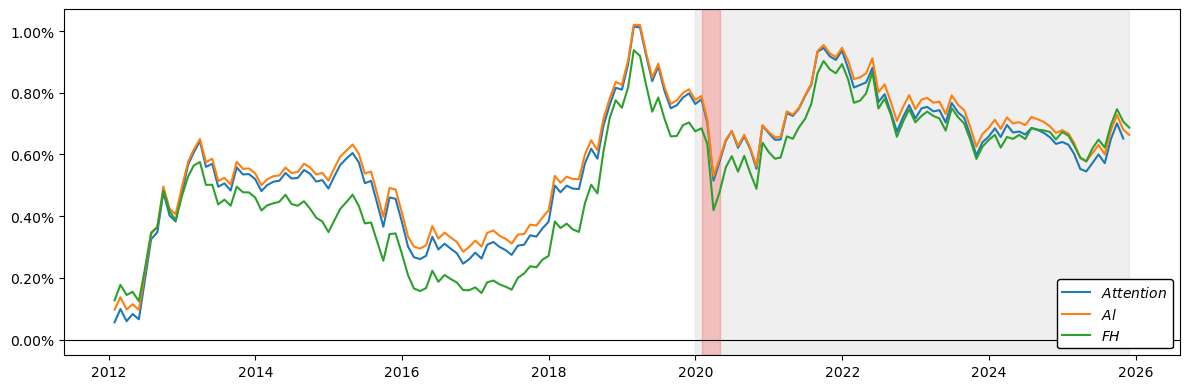

Figure X. Market-cap-weighted average implied prior returns for Attention, Allaj, and Fuhrer & Hock over the full sample period. The grey shaded region denotes the out-of-sample test period (from January 2020), and the red shaded region marks the COVID-19 bear market (February-April 2020). All values are expressed as percentages.


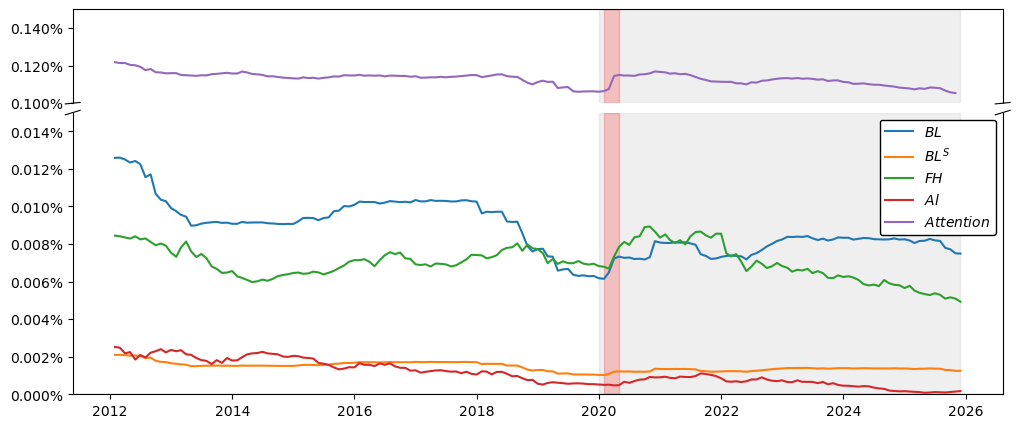

In [11]:
out_dir = "Data"

METHODS = {
    "Classical":    "Classical",
    "Sample_based": r"Classical$^{S}$",
    "FH":           "Fuhrer & Hock",
    "Allaj":        "Allaj",
    "Attention":    "Attention",
}

BENCH_NAMES = ["Classical", "Sample_based", "FH", "Allaj", "Attention"]

print("Loaded:")
for name in BENCH_NAMES:
    n_valid = implied_returns[name].notna().all(axis=1).sum()
    print(f"  {name:15s}  {n_valid} valid dates")

# ── Weighted average implied returns and variance ─────────────────────────────
PLOT_METHODS = {
    "Classical":    r"$BL$",
    "Sample_based": r"$BL^{S}$",
    "FH":           r"$FH$",
    "Allaj":        r"$Al$",
    "Attention":    r"$Attention$",
}

cols = assets.columns
idx  = implied_returns["Classical"].index

weighted_avg_returns  = pd.DataFrame(np.nan, index=idx, columns=list(PLOT_METHODS))
weighted_avg_variance = pd.DataFrame(np.nan, index=idx, columns=list(PLOT_METHODS))

for i, date in enumerate(idx):
    if date not in market_weights.index:
        continue
    w_raw = market_weights.loc[date].reindex(cols).to_numpy(dtype=float)

    for name in PLOT_METHODS:
        if date not in implied_returns[name].index:
            continue
        pi  = implied_returns[name].loc[date].to_numpy(dtype=float)
        Psi = implied_covmatrix[name][i]

        mask = np.isfinite(w_raw) & np.isfinite(pi) & np.isfinite(np.diag(Psi))
        if mask.sum() == 0:
            continue

        w = w_raw[mask]
        w = w / w.sum()
        weighted_avg_returns.loc[date, name]  = float(w @ pi[mask])
        weighted_avg_variance.loc[date, name] = float(w @ Psi[np.ix_(mask, mask)] @ w)

# ── Shared formatting helper ──────────────────────────────────────────────────
covid_start = pd.Timestamp("2020-02-01")
covid_end   = pd.Timestamp("2020-04-30")

def style_ax(ax):
    # `label="_nolegend_"` keeps the shaded regions out of the legend
    ax.axvspan(TEST_START, idx[-1], color="grey", alpha=0.12, label="_nolegend_")
    ax.axvspan(covid_start, covid_end, color="red", alpha=0.2, label="_nolegend_")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x * 100:.2f}%"))
    ax.grid(False)

# ── Figure 1: Implied prior returns (Attention, Allaj, FH only) ───────────────
RETURNS_METHODS = ["Attention", "Allaj", "FH"]

fig1, ax1 = plt.subplots(figsize=(12, 4))
for name in RETURNS_METHODS:
    ax1.plot(weighted_avg_returns.index, weighted_avg_returns[name], label=PLOT_METHODS[name])
style_ax(ax1)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc="lower right", framealpha=1.0, edgecolor="black")
plt.tight_layout()
plt.show()

print(
    "Figure X. Market-cap-weighted average implied prior returns for Attention, Allaj, and "
    "Fuhrer & Hock over the full sample period. "
    "The grey shaded region denotes the out-of-sample test period (from January 2020), and the red "
    "shaded region marks the COVID-19 bear market (February-April 2020). "
    "All values are expressed as percentages."
)


fig2 = plt.figure(figsize=(12, 5))
gs   = GridSpec(2, 1, figure=fig2, height_ratios=[1, 3], hspace=0.05)

ax_top = fig2.add_subplot(gs[0])   # upper panel: large values
ax_bot = fig2.add_subplot(gs[1])   # lower panel: small values

for name in PLOT_METHODS:
    ax_top.plot(weighted_avg_variance.index, weighted_avg_variance[name], label=PLOT_METHODS[name])
    ax_bot.plot(weighted_avg_variance.index, weighted_avg_variance[name], label=PLOT_METHODS[name])

# ── Set y-limits for each panel ───────────────────────────────────────────────
ax_bot.set_ylim(0, 0.00015)      # fine scale: 0 to 0.03%
ax_top.set_ylim(0.001, 0.0015)

# ── Formatting ────────────────────────────────────────────────────────────────
fmt = plt.FuncFormatter(lambda x, _: f"{x * 100:.3f}%")
for ax in [ax_top, ax_bot]:
    # `label="_nolegend_"` keeps the shaded regions out of the legend
    ax.axvspan(TEST_START, idx[-1], color="grey", alpha=0.12, label="_nolegend_")
    ax.axvspan(covid_start, covid_end, color="red", alpha=0.2, label="_nolegend_")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(False)

# ── Hide inner spines to make it look like one broken axis ────────────────────
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False, labelbottom=False)

# ── Diagonal break marks ──────────────────────────────────────────────────────
d = 0.008
kwargs = dict(transform=ax_top.transAxes, color="black", clip_on=False, linewidth=0.8)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1-d, 1+d), (-d, +d), **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1-d, 1+d), **kwargs)
ax_bot.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

handles, labels = ax_bot.get_legend_handles_labels()
ax_bot.legend(handles, labels, loc="upper right", framealpha=1.0, edgecolor="black")
plt.tight_layout()
plt.show()

## 4. QLIKE evaluation

Univariate and multivariate QLIKE scores, per-period summaries, and the Friedman–Nemenyi omnibus ranking.

In [12]:
# ---- QLIKE scores (Patton, 2011) — full period ----
# QLIKE_t = log(sigma2_{t-1}) + eps2_t / sigma2_{t-1}
# eps2_t  = (implied_return_{t-1} - excess_return_t)^2
# Score indexed at the realisation date (next_date = t).
cols         = assets.columns
qlike_scores = pd.DataFrame(np.nan, index=implied_returns["Classical"].index, columns=list(METHODS))

idx   = implied_returns["Classical"].index
dates = idx.to_numpy()
n     = len(dates)

for i in range(n - 1):
    date      = dates[i]        # prediction date (t-1)
    next_date = dates[i + 1]    # realisation date (t)

    if next_date not in assets.index or date not in market_weights.index:
        continue

    r_next = assets.loc[next_date].reindex(cols).to_numpy(dtype=float)
    w_raw  = market_weights.loc[date].reindex(cols).to_numpy(dtype=float)

    for name in METHODS:
        mu     = implied_returns[name].loc[date].to_numpy(dtype=float)
        sigma2 = np.diag(implied_covmatrix[name][i]).astype(float)

        mask = np.isfinite(mu) & (sigma2 > 0) & np.isfinite(r_next) & np.isfinite(w_raw)
        if mask.sum() == 0:
            continue

        mu_m     = mu[mask]
        sigma2_m = sigma2[mask]
        r_m      = r_next[mask]
        w_m      = w_raw[mask]; w_m = w_m / w_m.sum()

        # QLIKE_t = log(sigma2_{t-1}) + eps2_t / sigma2_{t-1}
        eps2   = (r_m - mu_m) ** 2
        scores = np.log(sigma2_m) + eps2 / sigma2_m
        qlike_scores.loc[next_date, name] = float(w_m @ scores)


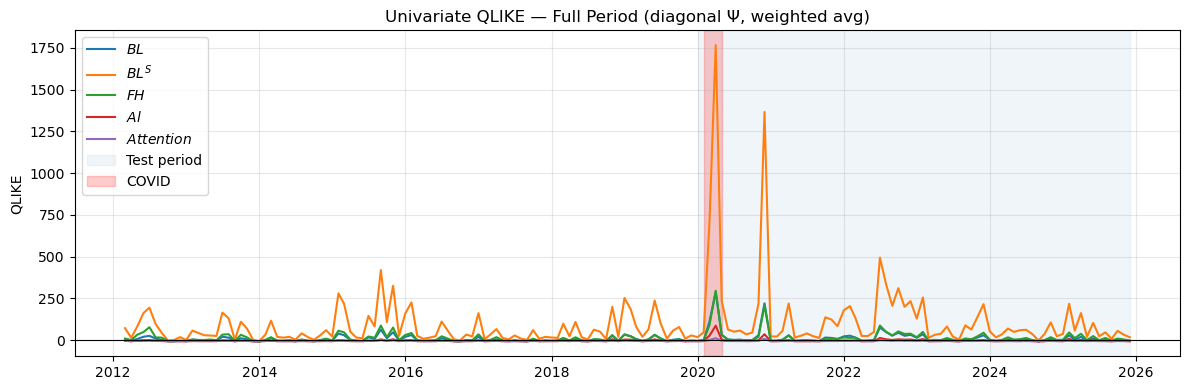

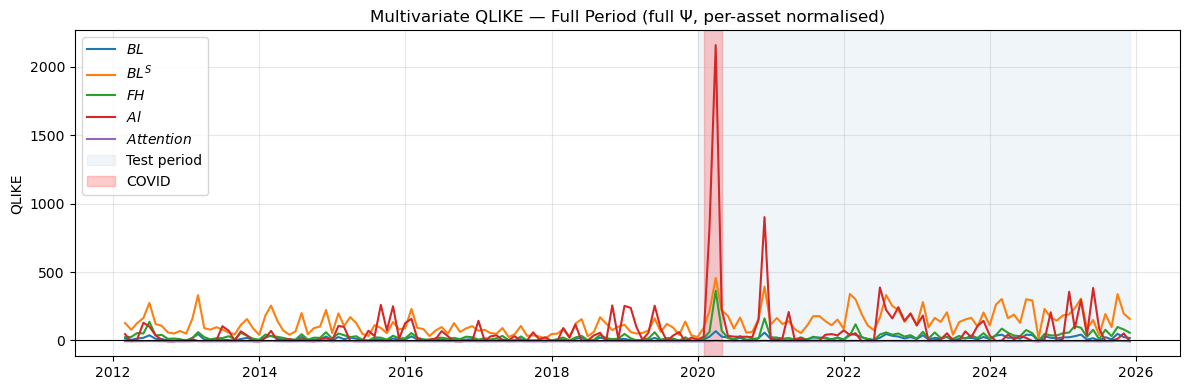

In [13]:
# ---- Multivariate QLIKE (Patton, 2011) — full period ----
# MV-QLIKE_t = [logdet(Psi_{t-1}) + (r_t - mu_{t-1})' Psi_{t-1}^{-1} (r_t - mu_{t-1})] / N
# Score indexed at the realisation date (next_date = t).
mv_qlike_scores = pd.DataFrame(np.nan, index=implied_returns["Classical"].index, columns=list(METHODS))

idx   = implied_returns["Classical"].index
dates = idx.to_numpy()
n     = len(dates)

for i in range(n - 1):
    date      = dates[i]        # prediction date (t-1)
    next_date = dates[i + 1]    # realisation date (t)

    if next_date not in assets.index:
        continue

    r_next = assets.loc[next_date].reindex(cols).to_numpy(dtype=float)

    for name in METHODS:
        mu  = implied_returns[name].loc[date].to_numpy(dtype=float)
        Psi = implied_covmatrix[name][i].astype(float)

        mask = np.isfinite(mu) & np.isfinite(r_next) & np.all(np.isfinite(Psi), axis=1)
        if mask.sum() == 0:
            continue

        mu_m  = mu[mask]
        r_m   = r_next[mask]
        Psi_m = Psi[np.ix_(mask, mask)]
        N_m   = int(mask.sum())

        eigvals, eigvecs = np.linalg.eigh(Psi_m)
        eigvals_pos = np.maximum(eigvals, 0.0)

        pos_mask = eigvals_pos > 0
        if pos_mask.sum() == 0:
            continue
        logdet = float(np.sum(np.log(eigvals_pos[pos_mask])))

        diff     = r_m - mu_m
        pinv_Psi = (eigvecs[:, pos_mask]
                    @ np.diag(1.0 / eigvals_pos[pos_mask])
                    @ eigvecs[:, pos_mask].T)
        quad = float(diff @ pinv_Psi @ diff)

        mv_qlike_scores.loc[next_date, name] = (logdet + quad) / N_m

# ---- Plot 1: Univariate QLIKE ----
fig1, ax1 = plt.subplots(figsize=(12, 4))
for name in METHODS:
    ax1.plot(qlike_scores.index, qlike_scores[name], label=PLOT_METHODS[name])
ax1.axvspan(TEST_START, idx[-1], color="steelblue", alpha=0.08, label="Test period")
ax1.axvspan(covid_start, covid_end, color="red", alpha=0.2, label="COVID")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_title("Univariate QLIKE — Full Period (diagonal Ψ, weighted avg)")
ax1.set_ylabel("QLIKE")
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot 2: Multivariate QLIKE ----
fig2, ax2 = plt.subplots(figsize=(12, 4))
for name in METHODS:
    ax2.plot(mv_qlike_scores.index, mv_qlike_scores[name], label=PLOT_METHODS[name])
ax2.axvspan(TEST_START, idx[-1], color="steelblue", alpha=0.08, label="Test period")
ax2.axvspan(covid_start, covid_end, color="red", alpha=0.2, label="COVID")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Multivariate QLIKE — Full Period (full Ψ, per-asset normalised)")
ax2.set_ylabel("QLIKE")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




In [14]:
def qlike_summary(scores, label):
    s = scores.dropna().agg(["mean", "std", "median", "min", "max"])
    s.index = ["Mean", "Std", "Median", "Min", "Max"]
    print(f"\n── QLIKE Summary — {label} ──")
    display(s.round(4))

train_mask = qlike_scores.index < TEST_START
test_mask  = qlike_scores.index >= TEST_START

qlike_summary(qlike_scores,             "Full Period")
qlike_summary(qlike_scores[train_mask], "Training Period")
qlike_summary(qlike_scores[test_mask],  "Test Period")
def dm_pairwise_table(qlike_scores, methods, maxlags=6):
    rows = []
    for i, name_i in enumerate(methods):
        row = {"Model": name_i}
        for j, name_j in enumerate(methods):
            if j >= i:
                row[name_j] = "—"
                continue
            d = (qlike_scores[name_i] - qlike_scores[name_j]).dropna().reset_index(drop=True)
            T = len(d)
            if T < 4:
                row[name_j] = "n/a"
                continue
            res  = sm.OLS(d.to_numpy(), np.ones(T)).fit(
                       cov_type='HAC', cov_kwds={'maxlags': maxlags})
            p    = float(res.pvalues[0]) / 2
            diff = float(d.mean())
            s    = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
            row[name_j] = f"{diff:+.4f}{s}"
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model")

methods = list(METHODS.keys())
display(dm_pairwise_table(qlike_scores[test_mask], methods))


── QLIKE Summary — Full Period ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,9.1146,98.5935,13.0446,-3.2577,-5.2655
Std,31.9705,192.0122,33.3452,8.7045,2.0186
Median,0.1030,45.6683,1.8614,-5.5344,-5.9244
Min,-8.2434,-5.8641,-8.2418,-7.5117,-6.5049
Max,286.9261,1766.6905,295.3806,86.0578,11.2289



── QLIKE Summary — Training Period ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,3.6619,65.4650,8.8157,-4.6847,-5.5384
Std,13.3736,80.2920,19.5138,2.9339,1.0712
Median,-2.5594,27.9970,0.3636,-6.0998,-6.0043
Min,-8.2434,-5.8641,-8.2418,-7.2484,-6.4594
Max,62.6498,419.3837,87.0442,5.0465,-0.7073



── QLIKE Summary — Test Period ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,16.4106,142.9205,18.7030,-1.3484,-4.9003
Std,45.5494,273.4323,45.3082,12.6719,2.7978
Median,1.8528,55.4921,3.8067,-5.1023,-5.8195
Min,-7.8181,-2.7161,-7.5494,-7.5117,-6.5049
Max,286.9261,1766.6905,295.3806,86.0578,11.2289


,Classical,Sample_based,FH,Allaj,Attention
Model,,,,,
Classical,—,—,—,—,—
Sample_based,+126.5099***,—,—,—,—
FH,+2.2924**,-124.2174***,—,—,—
Allaj,-17.7590***,-144.2689***,-20.0514***,—,—
Attention,-21.3109***,-147.8207***,-23.6033***,-3.5519***,—



Full Period  —  n=166

── α = 0.01 ──


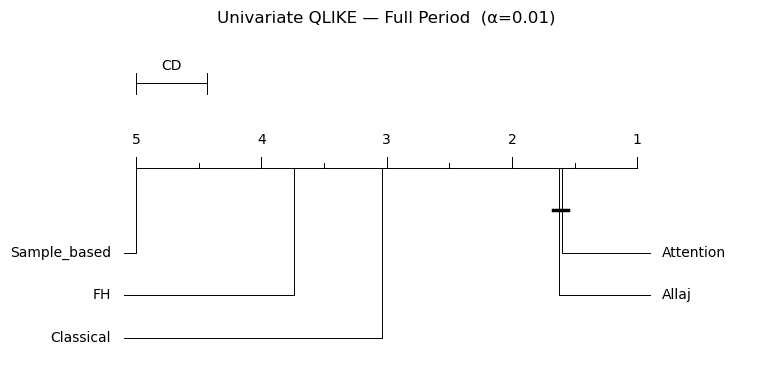


── α = 0.05 ──


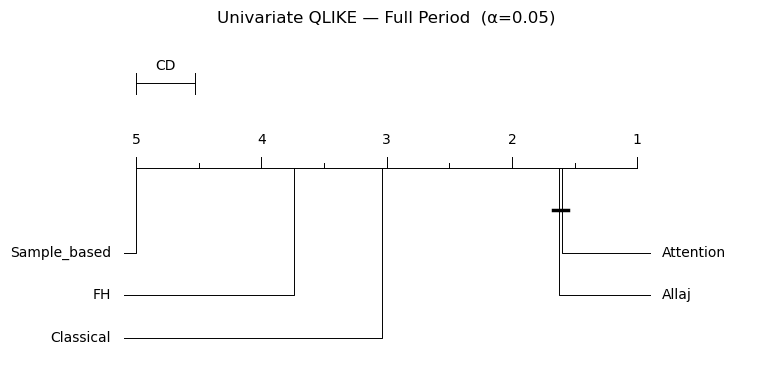


── α = 0.1 ──


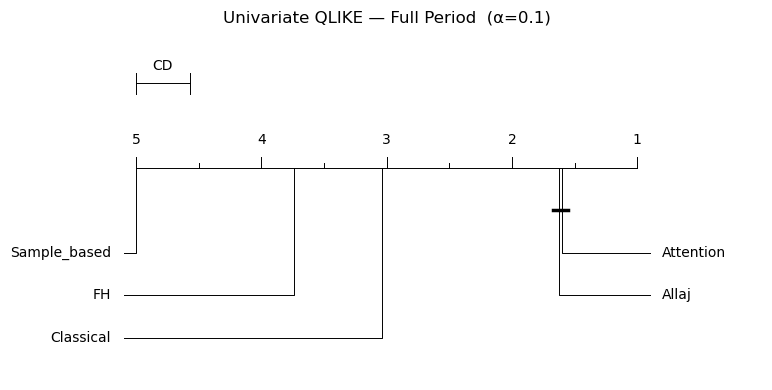


Training Period  —  n=95

── α = 0.01 ──


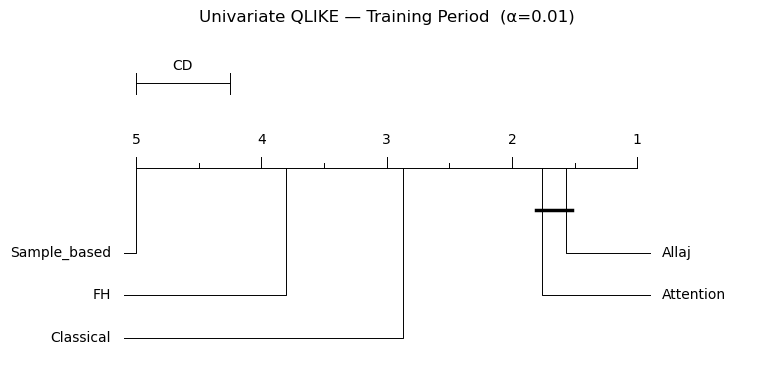


── α = 0.05 ──


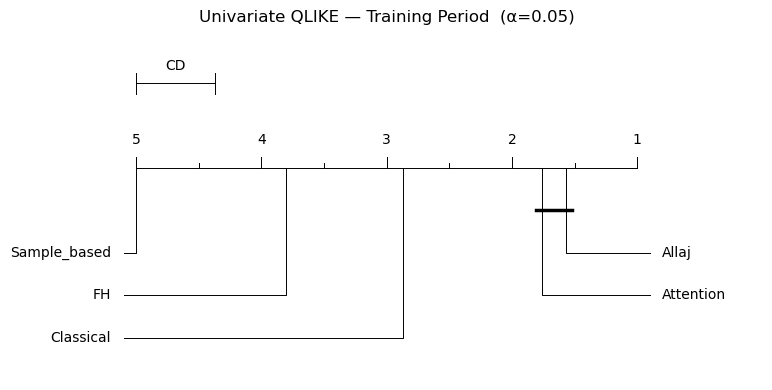


── α = 0.1 ──


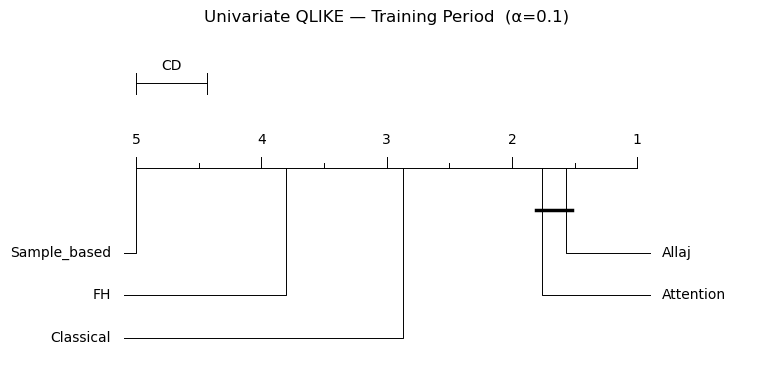


Test Period  —  n=71

── α = 0.01 ──


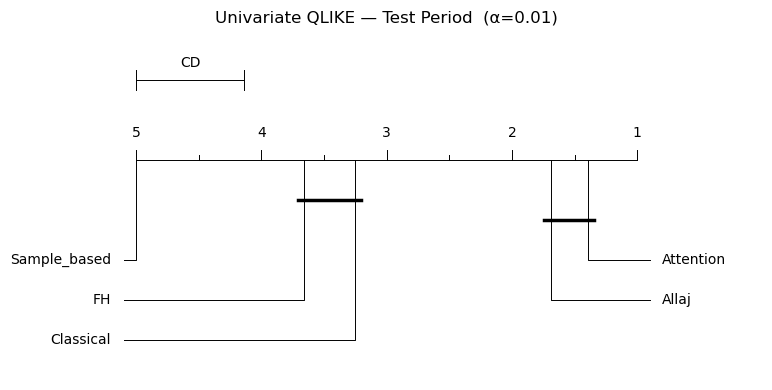


── α = 0.05 ──


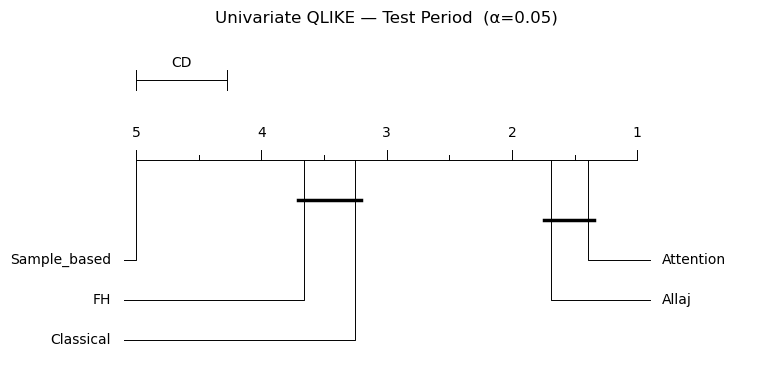


── α = 0.1 ──


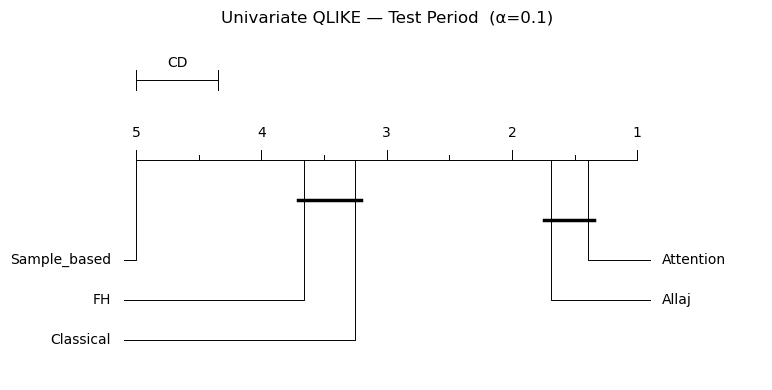

In [15]:
periods = {
    "Full Period":     qlike_scores,
    "Training Period": qlike_scores[qlike_scores.index < TEST_START],
    "Test Period":     qlike_scores[qlike_scores.index >= TEST_START],
}
alphas = [0.01, 0.05, 0.10]

for period_label, scores in periods.items():
    clean = scores.dropna()
    print(f"\n{'='*60}")
    print(f"{period_label}  —  n={len(clean)}")
    print('='*60)
    for alpha in alphas:
        print(f"\n── α = {alpha} ──")
        result = autorank(clean, alpha=alpha, verbose=False, order='ascending')
        fig, ax = plt.subplots(figsize=(8, 4))
        plot_stats(result, ax=ax)
        ax.set_title(f"Univariate QLIKE — {period_label}  (α={alpha})")
        plt.tight_layout()
        plt.show()

In [16]:
create_report(autorank(qlike_scores[test_mask].dropna(), alpha=alpha, verbose=False, order='ascending'))

The statistical analysis was conducted for 5 populations with 71 paired samples.
The family-wise significance level of the tests is alpha=0.100.
We rejected the null hypothesis that the population is normal for the populations Attention (p=0.000), Allaj (p=0.000), Classical (p=0.000), FH (p=0.000), and Sample_based (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is greater than the critical distance CD=0.653 of the Nemenyi test.
We rejec

In [17]:
# ---- QLIKE scores — equal weight ----
qlike_scores_ew = pd.DataFrame(np.nan, index=implied_returns["Classical"].index, columns=list(METHODS))

for i in range(n - 1):
    date      = dates[i]
    next_date = dates[i + 1]

    if next_date not in assets.index or date not in market_weights.index:
        continue

    r_next = assets.loc[next_date].reindex(cols).to_numpy(dtype=float)

    for name in METHODS:
        mu     = implied_returns[name].loc[date].to_numpy(dtype=float)
        sigma2 = np.diag(implied_covmatrix[name][i]).astype(float)

        mask = np.isfinite(mu) & (sigma2 > 0) & np.isfinite(r_next)
        if mask.sum() == 0:
            continue

        mu_m     = mu[mask]
        sigma2_m = sigma2[mask]
        r_m      = r_next[mask]

        eps2   = (r_m - mu_m) ** 2
        scores = np.log(sigma2_m) + eps2 / sigma2_m
        qlike_scores_ew.loc[next_date, name] = float(scores.mean())   # equal weight

# ---- Summary & DM ----
train_mask = qlike_scores_ew.index < TEST_START
test_mask  = qlike_scores_ew.index >= TEST_START

qlike_summary(qlike_scores_ew,             "Full Period — EW")
qlike_summary(qlike_scores_ew[train_mask], "Training Period — EW")
qlike_summary(qlike_scores_ew[test_mask],  "Test Period — EW")

methods = list(METHODS.keys())
display(dm_pairwise_table(qlike_scores_ew[test_mask], methods))


── QLIKE Summary — Full Period — EW ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,9.0607,97.0658,17.8585,-4.0741,-5.0458
Std,28.2894,169.9810,43.5644,4.8936,1.8351
Median,1.8974,53.6517,6.3083,-5.4572,-5.5861
Min,-7.6102,-2.3506,-6.8728,-6.9007,-6.2963
Max,256.1807,1581.1447,440.0403,45.8816,10.5017



── QLIKE Summary — Training Period — EW ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,3.2699,61.7218,10.1915,-4.9299,-5.3273
Std,10.9437,65.7237,18.1799,1.7257,0.9307
Median,-0.4603,39.4148,3.4826,-5.6088,-5.6660
Min,-6.6079,1.5895,-6.4729,-6.6022,-6.1680
Max,45.0390,312.1658,78.4663,0.8594,-1.5103



── QLIKE Summary — Test Period — EW ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,16.8089,144.3569,28.1171,-2.9292,-4.6692
Std,40.2389,241.5406,61.9934,7.0799,2.5541
Median,5.1458,74.3630,12.2949,-5.0103,-5.4018
Min,-7.6102,-2.3506,-6.8728,-6.9007,-6.2963
Max,256.1807,1581.1447,440.0403,45.8816,10.5017


,Classical,Sample_based,FH,Allaj,Attention
Model,,,,,
Classical,—,—,—,—,—
Sample_based,+127.5481***,—,—,—,—
FH,+11.3083***,-116.2398***,—,—,—
Allaj,-19.7380***,-147.2861***,-31.0463***,—,—
Attention,-21.4780***,-149.0261***,-32.7863***,-1.7400***,—



Univariate QLIKE (EW) — Full Period  —  n=166

── α = 0.01 ──


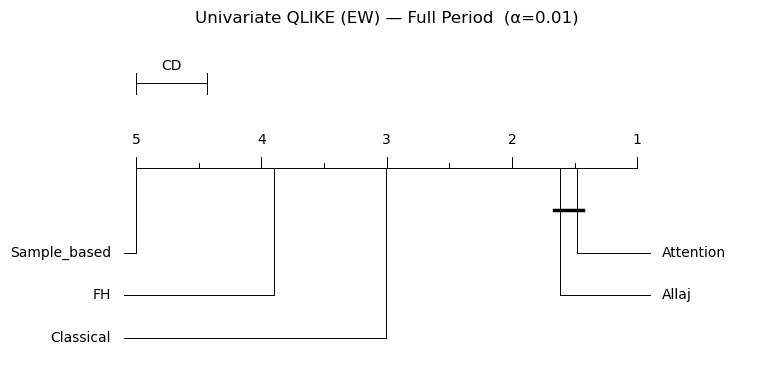


── α = 0.05 ──


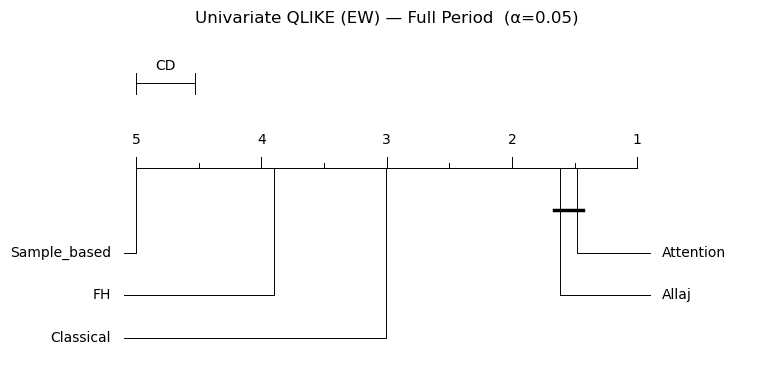


── α = 0.1 ──


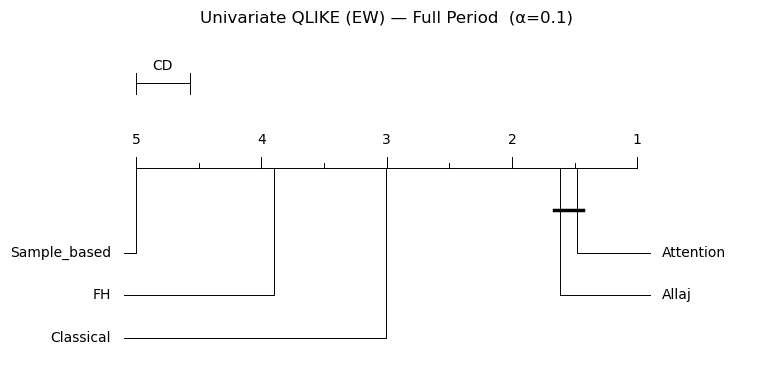


Univariate QLIKE (EW) — Training Period  —  n=95

── α = 0.01 ──


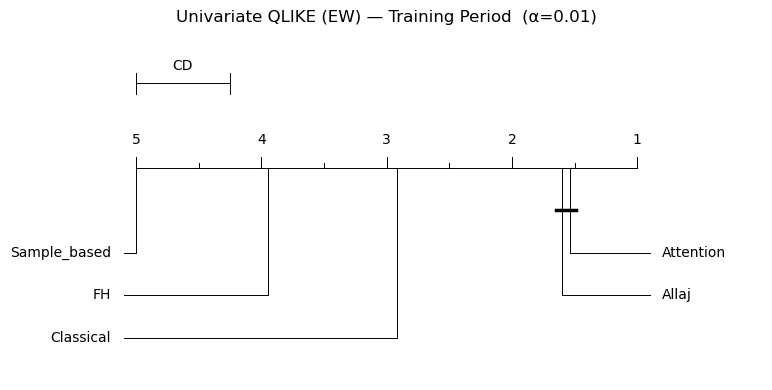


── α = 0.05 ──


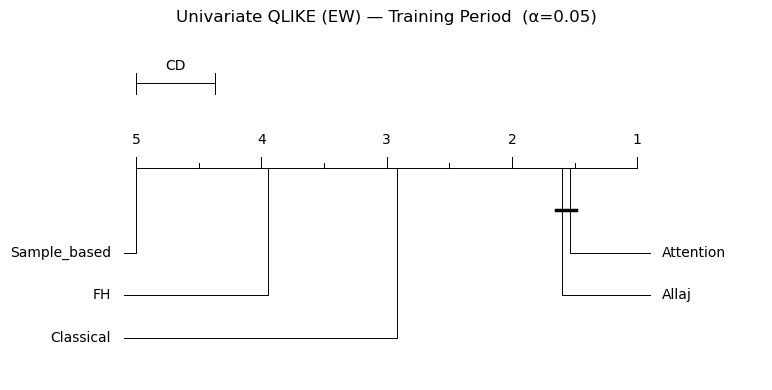


── α = 0.1 ──


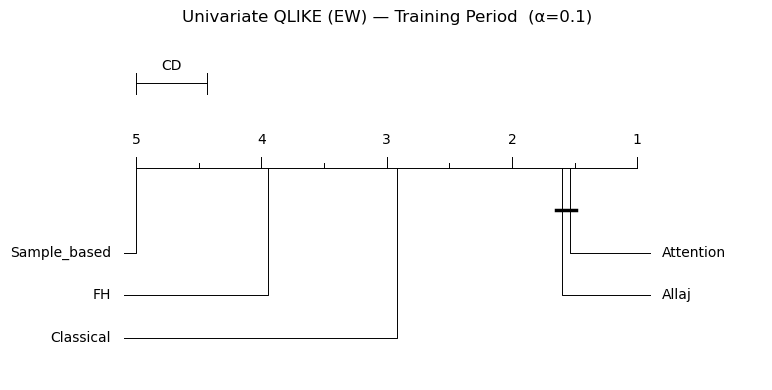


Univariate QLIKE (EW) — Test Period  —  n=71

── α = 0.01 ──


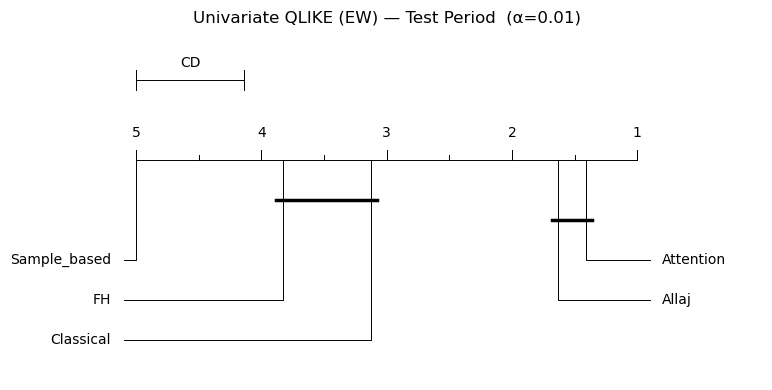


── α = 0.05 ──


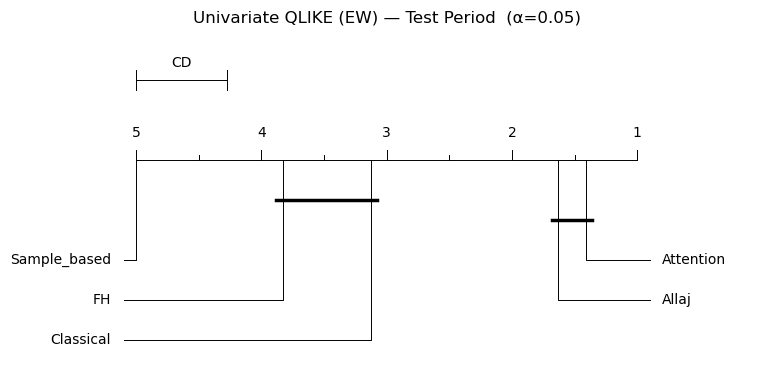


── α = 0.1 ──


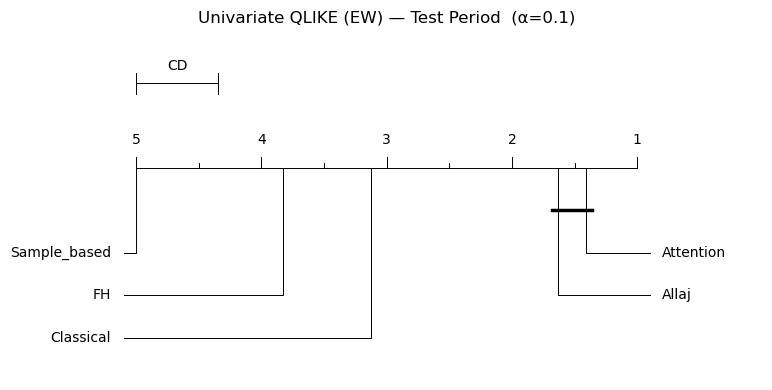

In [18]:
periods_ew = {
    "Full Period":     qlike_scores_ew,
    "Training Period": qlike_scores_ew[qlike_scores_ew.index < TEST_START],
    "Test Period":     qlike_scores_ew[qlike_scores_ew.index >= TEST_START],
}
for period_label, scores in periods_ew.items():
    clean = scores.dropna()
    print(f"\n{'='*60}")
    print(f"Univariate QLIKE (EW) — {period_label}  —  n={len(clean)}")
    print('='*60)
    for alpha in alphas:
        print(f"\n── α = {alpha} ──")
        result = autorank(clean, alpha=alpha, verbose=False, order='ascending')
        fig, ax = plt.subplots(figsize=(8, 4))
        plot_stats(result, ax=ax)
        ax.set_title(f"Univariate QLIKE (EW) — {period_label}  (α={alpha})")
        plt.tight_layout()
        plt.show()


In [19]:
def mv_qlike_summary(scores, label):
    s = scores.dropna().agg(["mean", "std", "median", "min", "max"])
    s.index = ["Mean", "Std", "Median", "Min", "Max"]
    print(f"\n── Multivariate QLIKE Summary — {label} ──")
    display(s.round(4))

train_mask = mv_qlike_scores.index < TEST_START
test_mask  = mv_qlike_scores.index >= TEST_START

mv_qlike_summary(mv_qlike_scores,             "Full Period")
mv_qlike_summary(mv_qlike_scores[train_mask], "Training Period")
mv_qlike_summary(mv_qlike_scores[test_mask],  "Test Period")


── Multivariate QLIKE Summary — Full Period ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,13.3704,128.8558,30.3023,76.4291,-5.7871
Std,13.6280,82.0682,37.4190,202.8303,0.9564
Median,10.1326,110.3455,20.4540,20.1201,-5.9235
Min,-5.5575,14.6094,-3.7864,-6.3530,-7.2543
Max,68.0664,457.6403,363.5479,2159.2241,-2.1810



── Multivariate QLIKE Summary — Training Period ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,7.8749,95.3343,20.7204,42.3765,-6.0640
Std,9.8100,58.8491,20.3043,67.8617,0.7742
Median,5.9356,83.4575,16.2203,10.8261,-6.1840
Min,-5.5437,14.6094,-3.7864,-6.3530,-7.1610
Max,47.1803,331.0905,136.5253,260.0578,-3.2567



── Multivariate QLIKE Summary — Test Period ──


,Classical,Sample_based,FH,Allaj,Attention
Mean,20.7234,173.7086,43.1233,121.9923,-5.4165
Std,14.5848,87.5195,49.5528,295.1434,1.0525
Median,19.1199,164.0306,31.5468,31.4222,-5.5594
Min,-5.5575,15.9173,-2.4928,-6.1835,-7.2543
Max,68.0664,457.6403,363.5479,2159.2241,-2.1810



Multivariate QLIKE — Full Period  —  n=166

── α = 0.01 ──


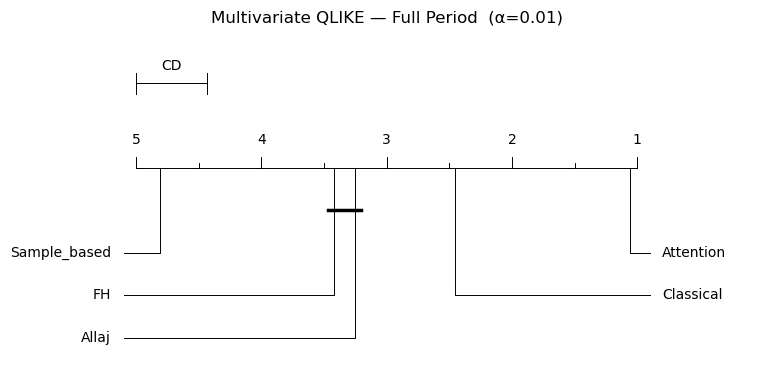


── α = 0.05 ──


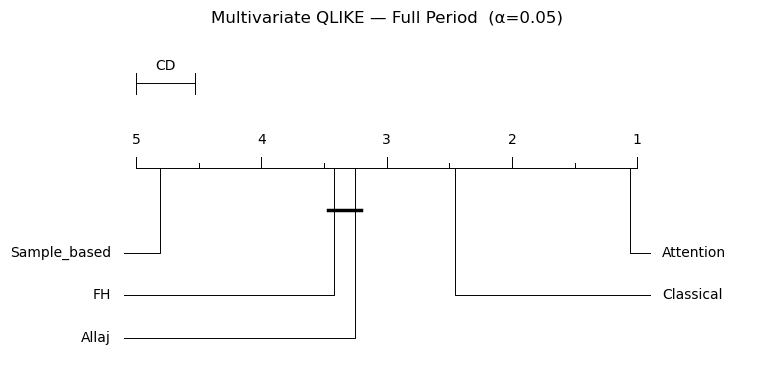


── α = 0.1 ──


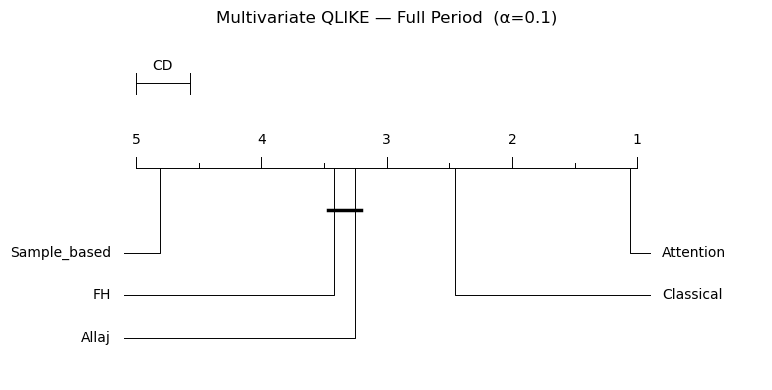


Multivariate QLIKE — Training Period  —  n=95

── α = 0.01 ──


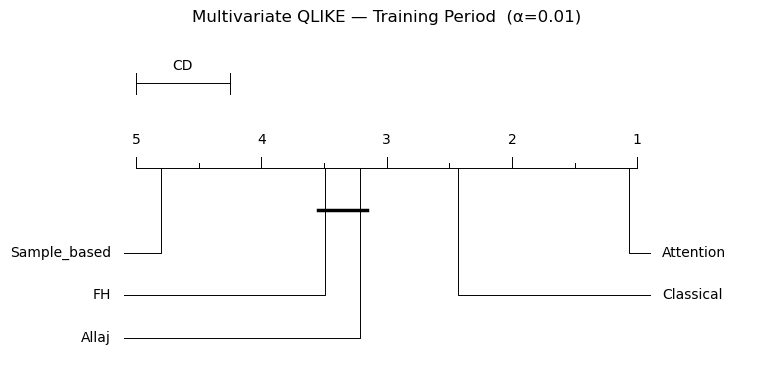


── α = 0.05 ──


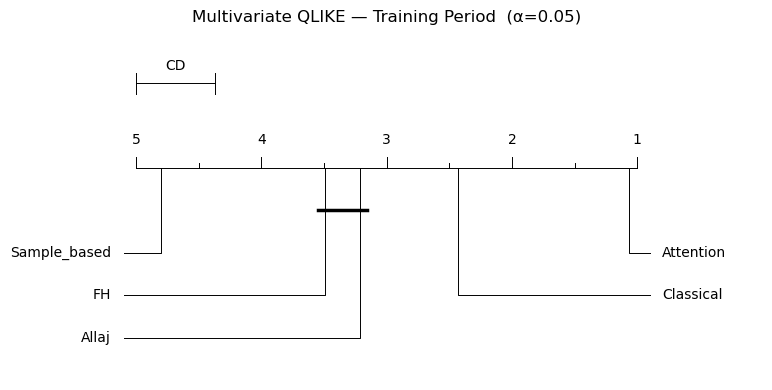


── α = 0.1 ──


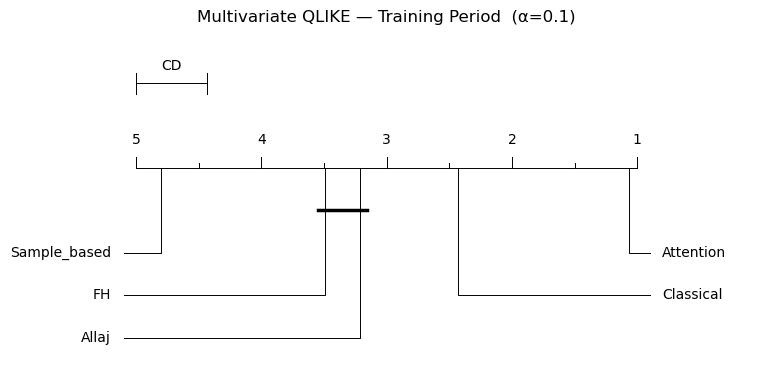


Multivariate QLIKE — Test Period  —  n=71

── α = 0.01 ──


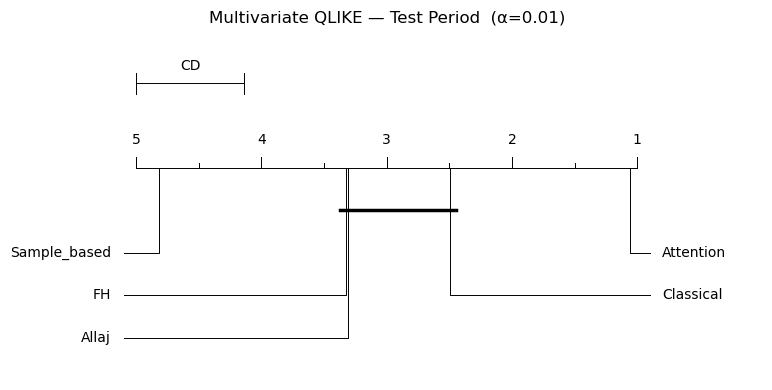


── α = 0.05 ──


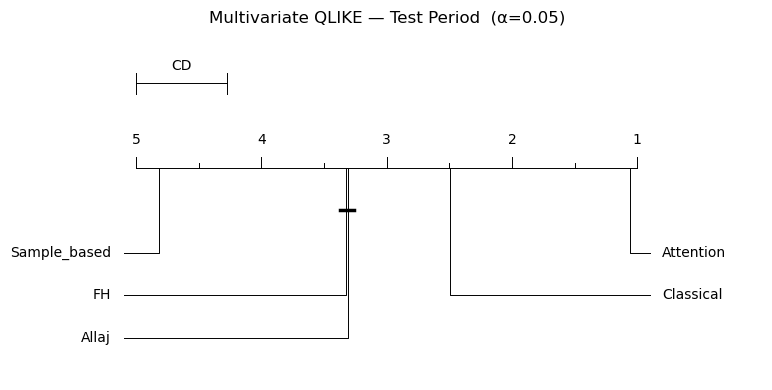


── α = 0.1 ──


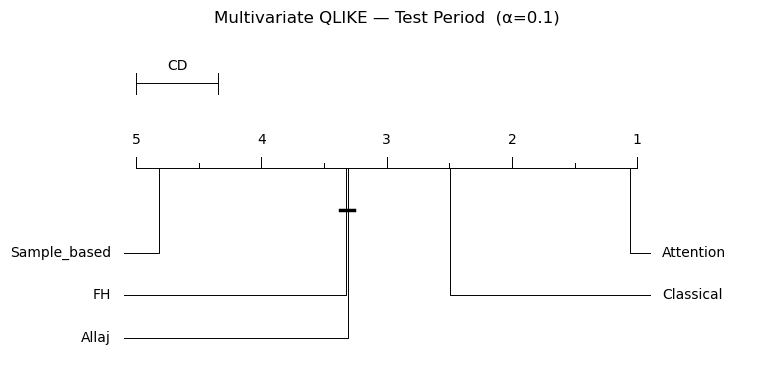

,Classical,Sample_based,FH,Allaj,Attention
Model,,,,,
Classical,—,—,—,—,—
Sample_based,+152.9852***,—,—,—,—
FH,+22.3999***,-130.5853***,—,—,—
Allaj,+101.2689***,-51.7163*,+78.8690**,—,—
Attention,-26.1399***,-179.1251***,-48.5398***,-127.4088***,—


In [20]:
periods = {
    "Full Period":     mv_qlike_scores,
    "Training Period": mv_qlike_scores[mv_qlike_scores.index < TEST_START],
    "Test Period":     mv_qlike_scores[mv_qlike_scores.index >= TEST_START],
}
for period_label, scores in periods.items():
    clean = scores.dropna()
    print(f"\n{'='*60}")
    print(f"Multivariate QLIKE — {period_label}  —  n={len(clean)}")
    print('='*60)
    for alpha in alphas:
        print(f"\n── α = {alpha} ──")
        result = autorank(clean, alpha=alpha, verbose=False, order='ascending')
        fig, ax = plt.subplots(figsize=(8, 4))
        plot_stats(result, ax=ax)
        ax.set_title(f"Multivariate QLIKE — {period_label}  (α={alpha})")
        plt.tight_layout()
        plt.show()

display(dm_pairwise_table(mv_qlike_scores[test_mask], methods))

## 5. Interpretability — attention weights

Per-asset attention heatmaps and the event-overlay cyclicality analysis of the learned temporal weights.

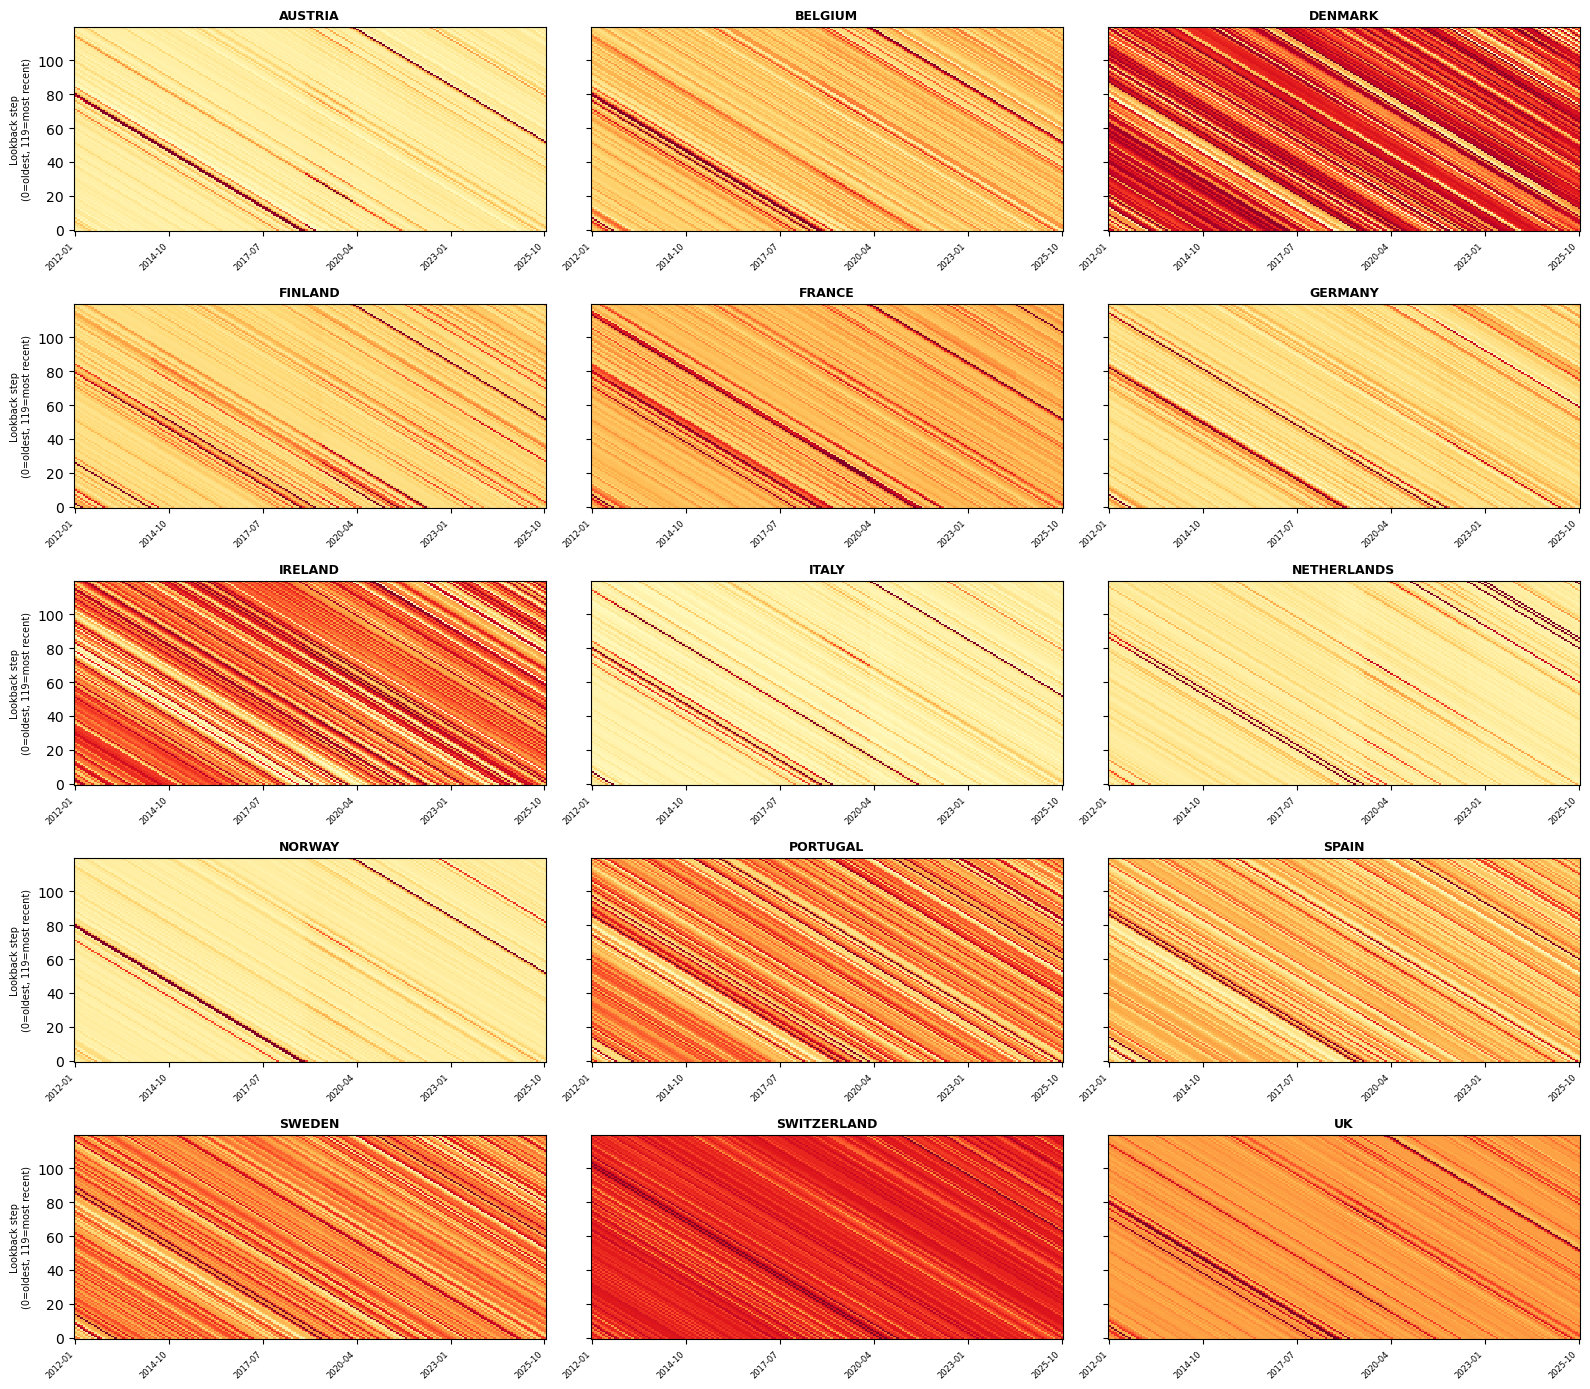

Figure X. Per-asset attention weight heatmaps from the Attention model over the full sample period. Each subplot corresponds to one MSCI regional index. The vertical axis represents the lookback step within the 120-month input window (step 0 = oldest month, step 119 = most recent), and the horizontal axis represents the prediction date. Colour intensity (YlOrRd colormap) encodes the attention weight assigned to each lookback step, with warmer colours indicating higher attention. The colour scale of each subplot is normalised to the 99th percentile of its own attention values.


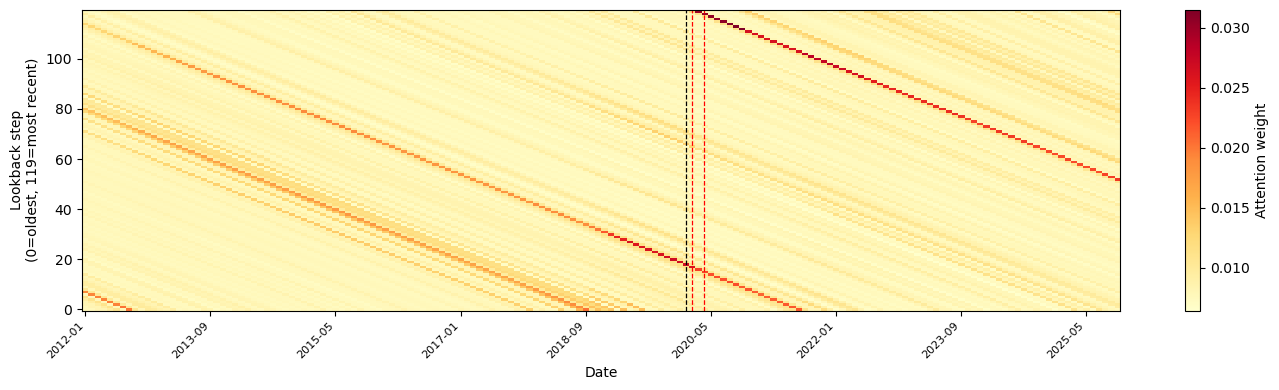

Figure X. Market-cap-weighted average attention weights across all assets over the full sample period. The vertical axis represents the lookback step within the 120-month input window (step 0 = oldest, step 119 = most recent), and the horizontal axis represents the prediction date. Colour intensity (YlOrRd colormap) encodes the cross-sectional market-cap-weighted average attention weight. The black dashed line marks the start of the out-of-sample test period (January 2020), and the red dashed lines delimit the COVID-19 bear market (February-April 2020).


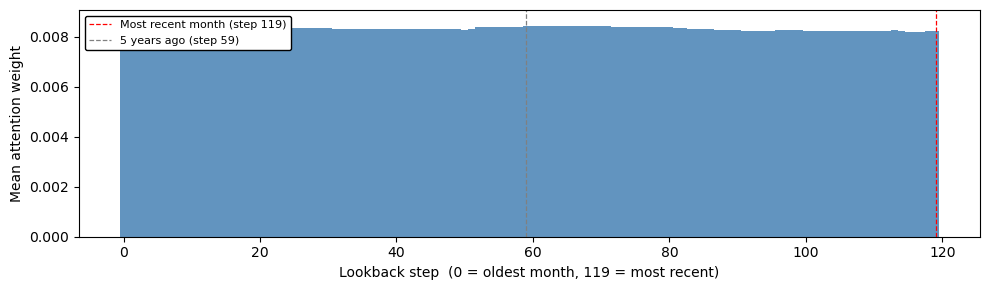

Figure X. Average attention profile of the Attention model, computed as the mean attention weight at each lookback step across all assets and all prediction dates in the full sample period. The horizontal axis represents the lookback step within the 120-month input window (step 0 = oldest month, step 119 = most recent). The red dashed line marks the most recent month (step 119), and the grey dashed line marks the position five years prior to the prediction date (step 59).


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# Interpretability — Attention Weight Analysis (Cyclicality Signal)
# ═══════════════════════════════════════════════════════════════════════════

idx_all   = assets.index.intersection(market.index)
dates_all = idx_all.to_numpy()
date_to_t = {pd.Timestamp(d): t for t, d in enumerate(dates_all)}

# All dates where Attention model produced predictions (full period)
test_dates = [d for d in implied_returns["Attention"].index
              if implied_returns["Attention"].loc[d].notna().all()]
n_test     = len(test_dates)

covid_start = pd.Timestamp("2020-02-01")
covid_end   = pd.Timestamp("2020-04-30")

# ── 1. Per-asset attention heatmaps ──────────────────────────────────────────
fig, axes = plt.subplots(5, 3, figsize=(16, 14), sharey=True)
axes_flat = axes.flatten()

for k, asset_name in enumerate(assets.columns):
    ax = axes_flat[k]

    attn_rows = []
    for date in test_dates:
        t_idx = date_to_t.get(pd.Timestamp(date))
        if t_idx is not None and not np.isnan(attn_t_arr[t_idx, k, 0]):
            attn_rows.append(attn_t_arr[t_idx, k, :])

    if not attn_rows:
        ax.set_visible(False)
        continue

    attn_matrix = np.stack(attn_rows)          # (n_test, 120)
    vmax        = float(np.percentile(attn_matrix, 99))
    im = ax.imshow(attn_matrix.T, aspect="auto", origin="lower",
                   cmap="YlOrRd", interpolation="nearest", vmin=0, vmax=vmax)

    ax.set_title(asset_name.replace("MSCI ", ""), fontsize=9, fontweight="bold")
    ticks = list(range(0, n_test, max(1, n_test // 5)))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(test_dates[p])[:7] for p in ticks],
                        rotation=45, ha="right", fontsize=6)

for row in range(5):
    axes_flat[row * 3].set_ylabel("Lookback step\n(0=oldest, 119=most recent)", fontsize=7)

for k in range(len(assets.columns), len(axes_flat)):
    axes_flat[k].set_visible(False)

plt.tight_layout()
plt.show()

print(
    "Figure X. Per-asset attention weight heatmaps from the Attention model over the full "
    "sample period. Each subplot corresponds to one MSCI regional index. The vertical axis "
    "represents the lookback step within the 120-month input window (step 0 = oldest month, "
    "step 119 = most recent), and the horizontal axis represents the prediction date. "
    "Colour intensity (YlOrRd colormap) encodes the attention weight assigned to each "
    "lookback step, with warmer colours indicating higher attention. The colour scale of "
    "each subplot is normalised to the 99th percentile of its own attention values."
)

# ── 2. Market-cap weighted average attention across all assets ────────────────
agg_attn, agg_dates = [], []
for date in test_dates:
    t_idx = date_to_t.get(pd.Timestamp(date))
    if t_idx is None or date not in market_weights.index:
        continue
    w = market_weights.loc[date].reindex(assets.columns).to_numpy(float)
    w = np.where(np.isfinite(w), w, 0.0)
    if w.sum() == 0:
        continue
    w /= w.sum()
    A_t = attn_t_arr[t_idx]    # (N, 120)
    if np.isnan(A_t).any():
        continue
    agg_attn.append((w[:, None] * A_t).sum(axis=0))
    agg_dates.append(date)

if agg_attn:
    agg_matrix = np.stack(agg_attn)   # (n_dates, 120)
    n_ag = len(agg_dates)

    fig2, ax2 = plt.subplots(figsize=(14, 4))
    im2 = ax2.imshow(agg_matrix.T, aspect="auto", origin="lower",
                     cmap="YlOrRd", interpolation="nearest")

    # Vertical reference lines for test-period start and COVID window
    agg_dates_ts = [pd.Timestamp(d) for d in agg_dates]
    try:
        test_x = next(i for i, d in enumerate(agg_dates_ts) if d >= pd.Timestamp(TEST_START))
        ax2.axvline(test_x, color="black", linestyle="--", linewidth=0.9, label="_nolegend_")
    except StopIteration:
        pass
    try:
        cov_start_x = next(i for i, d in enumerate(agg_dates_ts) if d >= covid_start)
        cov_end_x   = next(i for i, d in enumerate(agg_dates_ts) if d >= covid_end)
        ax2.axvline(cov_start_x, color="red", linestyle="--", linewidth=0.9, label="_nolegend_")
        ax2.axvline(cov_end_x,   color="red", linestyle="--", linewidth=0.9, label="_nolegend_")
    except StopIteration:
        pass

    ax2.set_ylabel("Lookback step\n(0=oldest, 119=most recent)")
    ax2.set_xlabel("Date")
    ticks2 = list(range(0, n_ag, max(1, n_ag // 8)))
    ax2.set_xticks(ticks2)
    ax2.set_xticklabels([str(agg_dates[p])[:7] for p in ticks2],
                         rotation=45, ha="right", fontsize=8)
    plt.colorbar(im2, ax=ax2, label="Attention weight")
    plt.tight_layout()
    plt.show()

    print(
        "Figure X. Market-cap-weighted average attention weights across all assets over the "
        "full sample period. The vertical axis represents the lookback step within the "
        "120-month input window (step 0 = oldest, step 119 = most recent), and the "
        "horizontal axis represents the prediction date. Colour intensity (YlOrRd colormap) "
        "encodes the cross-sectional market-cap-weighted average attention weight. The black "
        "dashed line marks the start of the out-of-sample test period (January 2020), and "
        "the red dashed lines delimit the COVID-19 bear market (February-April 2020)."
    )

    # ── 3. Average attention profile (mean over all dates and assets) ─────────
    mean_profile = agg_matrix.mean(axis=0)    # (120,)
    fig3, ax3 = plt.subplots(figsize=(10, 3))
    ax3.bar(range(120), mean_profile, color="steelblue", width=1.0, alpha=0.85)
    ax3.axvline(119, color="red",  linestyle="--", linewidth=0.9,
                label="Most recent month (step 119)")
    ax3.axvline(59,  color="grey", linestyle="--", linewidth=0.9,
                label="5 years ago (step 59)")
    ax3.set_xlabel("Lookback step  (0 = oldest month, 119 = most recent)")
    ax3.set_ylabel("Mean attention weight")
    ax3.legend(fontsize=8, framealpha=1.0, edgecolor="black")
    plt.tight_layout()
    plt.show()

    print(
        "Figure X. Average attention profile of the Attention model, computed as the mean "
        "attention weight at each lookback step across all assets and all prediction dates "
        "in the full sample period. The horizontal axis represents the lookback step within "
        "the 120-month input window (step 0 = oldest month, step 119 = most recent). "
        "The red dashed line marks the most recent month (step 119), and the grey dashed "
        "line marks the position five years prior to the prediction date (step 59)."
    )

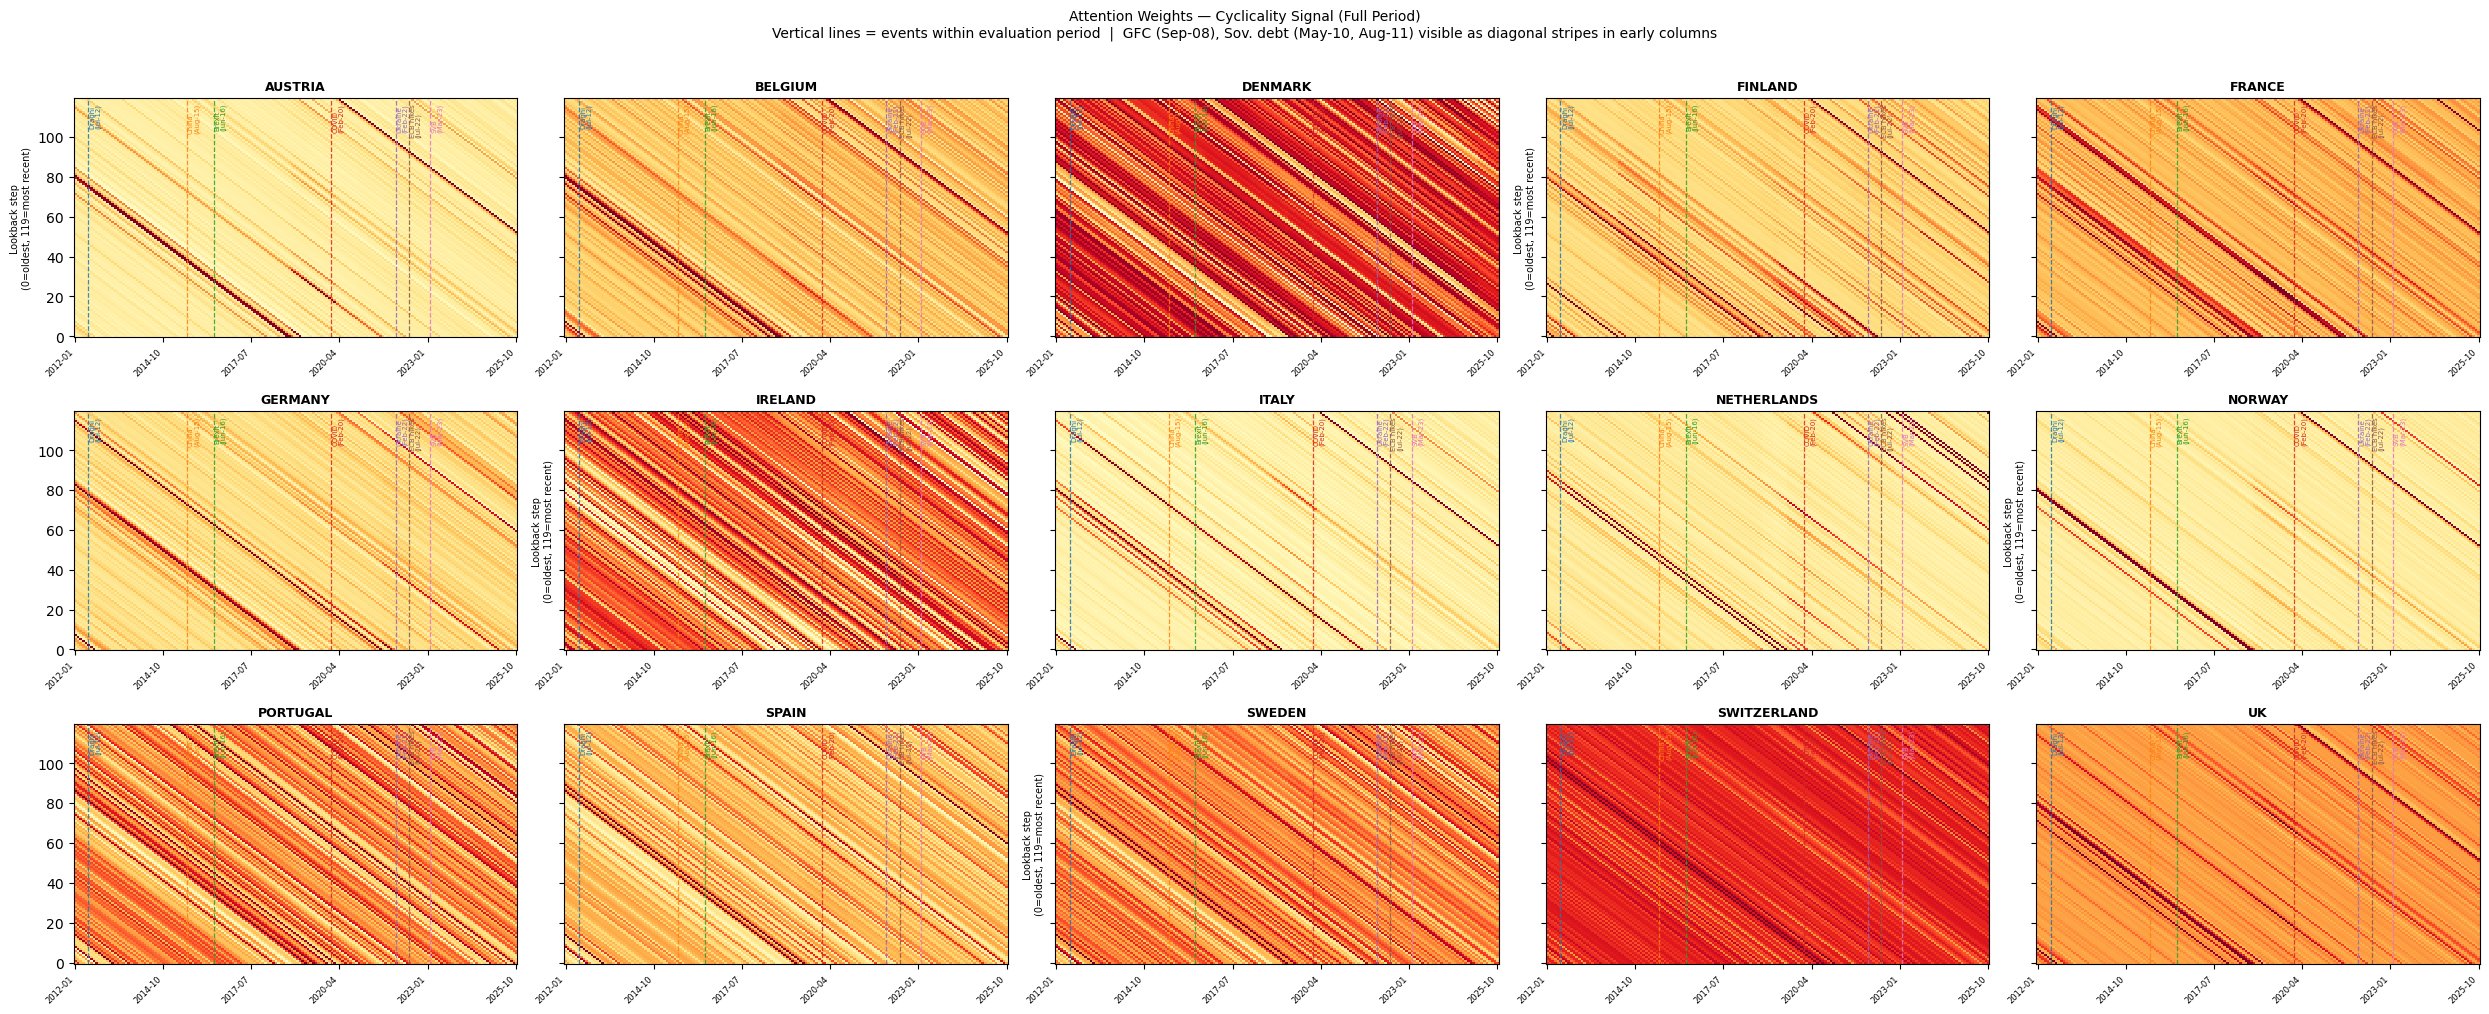

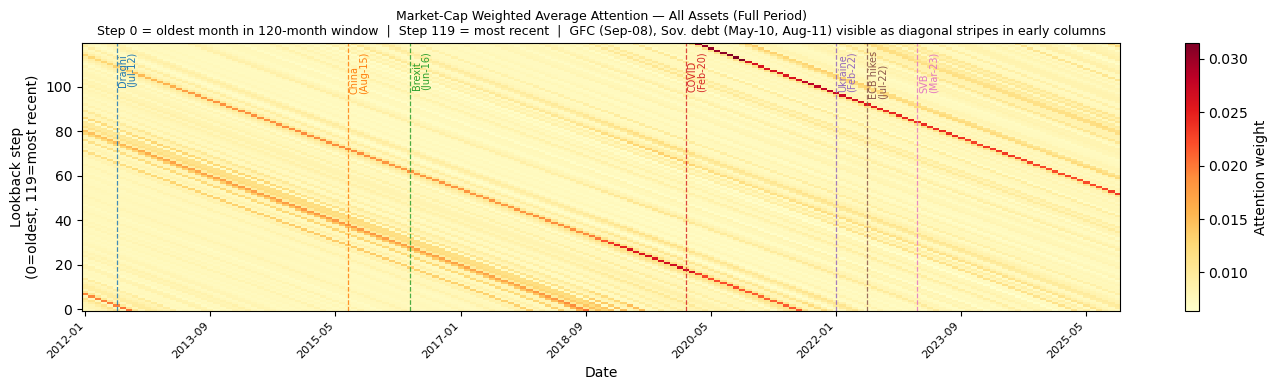

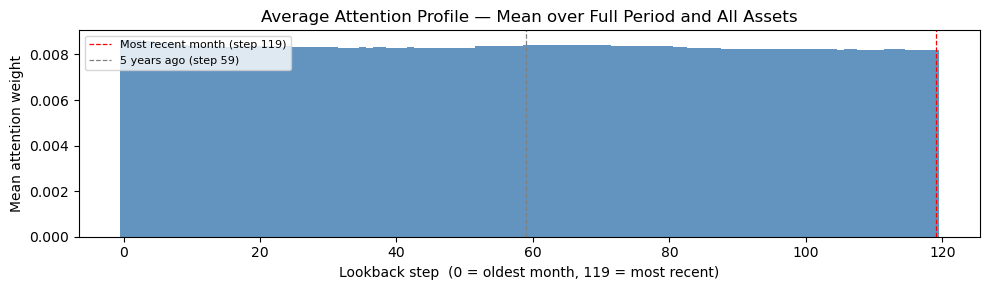

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# Interpretability — Attention Weight Analysis (Cyclicality Signal)
# ═══════════════════════════════════════════════════════════════════════════

idx_all   = assets.index.intersection(market.index)
dates_all = idx_all.to_numpy()
date_to_t = {pd.Timestamp(d): t for t, d in enumerate(dates_all)}

# All dates where Attention model produced predictions (full period)
test_dates = [d for d in implied_returns["Attention"].index
              if implied_returns["Attention"].loc[d].notna().all()]
n_test      = len(test_dates)
test_dates_ts = [pd.Timestamp(d) for d in test_dates]

# ── Key event dates ───────────────────────────────────────────────────────────
# Events before ~Feb-2012 (start of evaluation period) cannot be shown as
# x-axis lines but appear as diagonal stripes in the early heatmap columns.
EVENTS = {
    "Draghi\n(Jul-12)":    pd.Timestamp("2012-07-01"),   # "whatever it takes"
    "China\n(Aug-15)":     pd.Timestamp("2015-08-01"),   # EM/China selloff
    "Brexit\n(Jun-16)":    pd.Timestamp("2016-06-01"),   # UK referendum
    "COVID\n(Feb-20)":     pd.Timestamp("2020-02-01"),   # market crash
    "Ukraine\n(Feb-22)":   pd.Timestamp("2022-02-01"),   # Russian invasion
    "ECB hikes\n(Jul-22)": pd.Timestamp("2022-07-01"),   # first ECB rate hike
    "SVB\n(Mar-23)":       pd.Timestamp("2023-03-01"),   # banking stress
}
EVENT_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
                "#9467bd", "#8c564b", "#e377c2"]

def event_xpos(event_date, dates_list):
    """Return the nearest x-axis integer position for a calendar date."""
    diffs = [abs((pd.Timestamp(d) - event_date).days) for d in dates_list]
    return int(np.argmin(diffs))

def add_event_lines(ax, dates_list, fontsize=5, ypos=0.98):
    """Draw vertical event lines on a heatmap or bar axis."""
    ylim = ax.get_ylim()
    for (label, edate), color in zip(EVENTS.items(), EVENT_COLORS):
        xp = event_xpos(edate, dates_list)
        if 0 <= xp < len(dates_list):
            ax.axvline(xp, color=color, linewidth=0.9, linestyle="--", alpha=0.85)
            ax.text(xp + 0.3, ylim[0] + (ylim[1] - ylim[0]) * ypos, label,
                    color=color, fontsize=fontsize, va="top",
                    rotation=90, linespacing=0.9)

# ── 1. Per-asset attention heatmaps ──────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(25, 10), sharey=True)
axes_flat = axes.flatten()

for k, asset_name in enumerate(assets.columns):
    ax = axes_flat[k]

    attn_rows   = []
    panel_dates = []
    for date in test_dates:
        t_idx = date_to_t.get(pd.Timestamp(date))
        if t_idx is not None and not np.isnan(attn_t_arr[t_idx, k, 0]):
            attn_rows.append(attn_t_arr[t_idx, k, :])
            panel_dates.append(date)

    if not attn_rows:
        ax.set_visible(False)
        continue

    attn_matrix = np.stack(attn_rows)          # (n_panel, 120)
    vmax        = float(np.percentile(attn_matrix, 99))
    ax.imshow(attn_matrix.T, aspect="auto", origin="lower",
              cmap="YlOrRd", interpolation="nearest", vmin=0, vmax=vmax)

    ax.set_title(asset_name.replace("MSCI ", ""), fontsize=9, fontweight="bold")
    ticks = list(range(0, len(panel_dates), max(1, len(panel_dates) // 5)))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(panel_dates[p])[:7] for p in ticks],
                        rotation=45, ha="right", fontsize=6)
    add_event_lines(ax, panel_dates, fontsize=5, ypos=0.98)

for row in range(5):
    axes_flat[row * 3].set_ylabel("Lookback step\n(0=oldest, 119=most recent)", fontsize=7)

for k in range(len(assets.columns), len(axes_flat)):
    axes_flat[k].set_visible(False)

plt.suptitle(
    "Attention Weights — Cyclicality Signal (Full Period)\n"
    "Vertical lines = events within evaluation period  |  "
    "GFC (Sep-08), Sov. debt (May-10, Aug-11) visible as diagonal stripes in early columns",
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()

# ── 2. Market-cap weighted average attention across all assets ────────────────
agg_attn, agg_dates = [], []
for date in test_dates:
    t_idx = date_to_t.get(pd.Timestamp(date))
    if t_idx is None or date not in market_weights.index:
        continue
    w = market_weights.loc[date].reindex(assets.columns).to_numpy(float)
    w = np.where(np.isfinite(w), w, 0.0)
    if w.sum() == 0:
        continue
    w /= w.sum()
    A_t = attn_t_arr[t_idx]    # (N, 120)
    if np.isnan(A_t).any():
        continue
    agg_attn.append((w[:, None] * A_t).sum(axis=0))
    agg_dates.append(date)

if agg_attn:
    agg_matrix = np.stack(agg_attn)   # (n_dates, 120)
    n_ag = len(agg_dates)

    fig2, ax2 = plt.subplots(figsize=(14, 4))
    im2 = ax2.imshow(agg_matrix.T, aspect="auto", origin="lower",
                     cmap="YlOrRd", interpolation="nearest")
    ax2.set_title(
        "Market-Cap Weighted Average Attention — All Assets (Full Period)\n"
        "Step 0 = oldest month in 120-month window  |  Step 119 = most recent  |  "
        "GFC (Sep-08), Sov. debt (May-10, Aug-11) visible as diagonal stripes in early columns",
        fontsize=9
    )
    ax2.set_ylabel("Lookback step\n(0=oldest, 119=most recent)")
    ax2.set_xlabel("Date")
    ticks2 = list(range(0, n_ag, max(1, n_ag // 8)))
    ax2.set_xticks(ticks2)
    ax2.set_xticklabels([str(agg_dates[p])[:7] for p in ticks2],
                         rotation=45, ha="right", fontsize=8)
    plt.colorbar(im2, ax=ax2, label="Attention weight")
    add_event_lines(ax2, agg_dates, fontsize=7, ypos=0.97)
    plt.tight_layout()
    plt.show()

    # ── 3. Average attention profile (mean over all dates and assets) ─────────
    mean_profile = agg_matrix.mean(axis=0)    # (120,)
    fig3, ax3 = plt.subplots(figsize=(10, 3))
    ax3.bar(range(120), mean_profile, color="steelblue", width=1.0, alpha=0.85)
    ax3.axvline(119, color="red",  linestyle="--", linewidth=0.9,
                label="Most recent month (step 119)")
    ax3.axvline(59,  color="grey", linestyle="--", linewidth=0.9,
                label="5 years ago (step 59)")
    ax3.set_xlabel("Lookback step  (0 = oldest month, 119 = most recent)")
    ax3.set_ylabel("Mean attention weight")
    ax3.set_title("Average Attention Profile — Mean over Full Period and All Assets")
    ax3.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


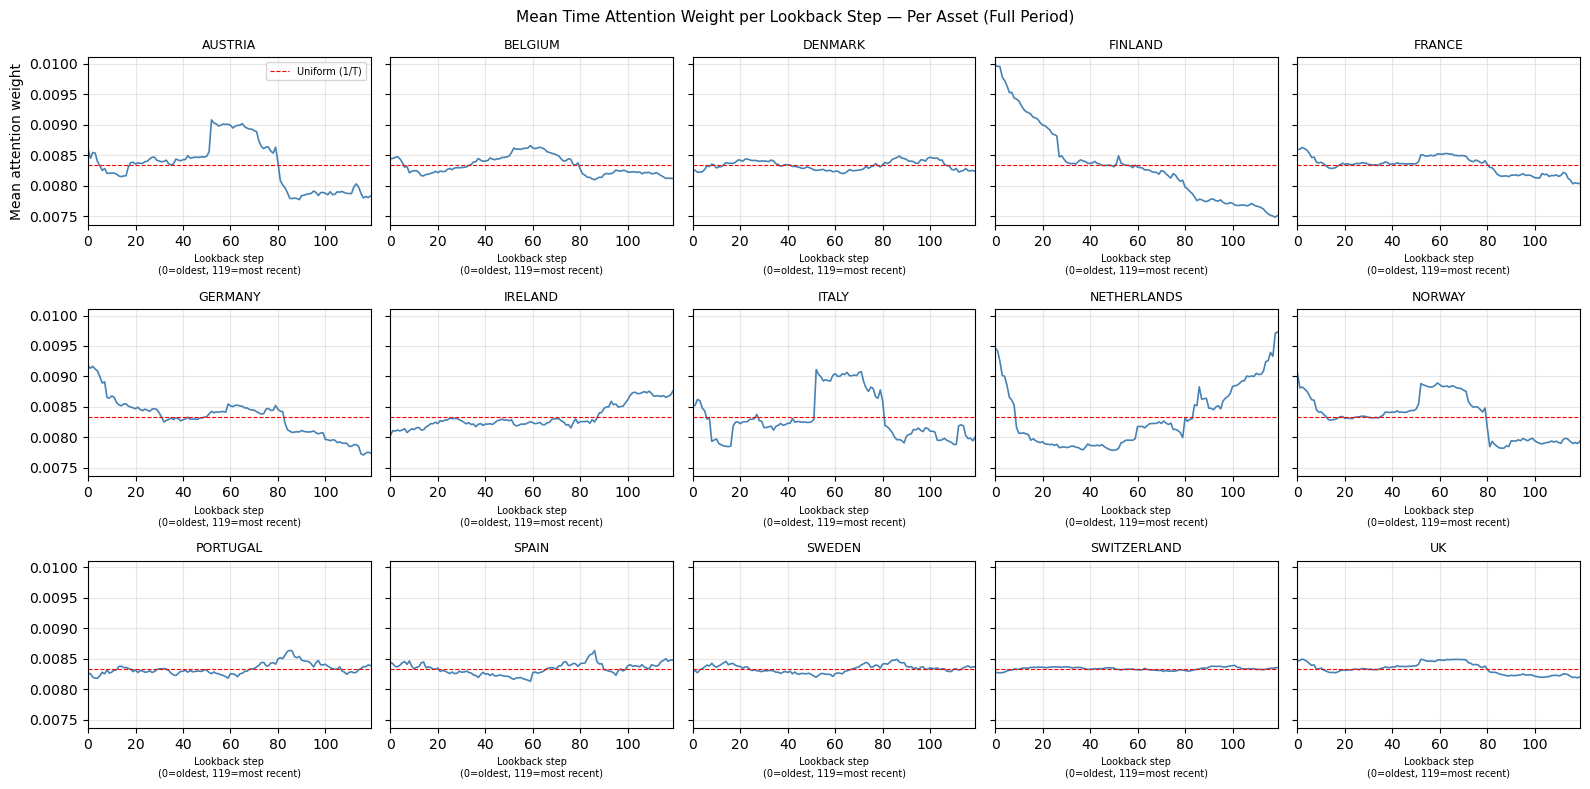

    Country  Entropy  Top-10 recent share  Peak lookback step
    FINLAND    4.785                0.076                   0
    AUSTRIA    4.786                0.079                  52
      ITALY    4.786                0.080                  52
NETHERLANDS    4.786                0.093                 119
    BELGIUM    4.787                0.082                  59
    DENMARK    4.787                0.083                  87
     FRANCE    4.787                0.081                   2
    GERMANY    4.787                0.078                   0
    IRELAND    4.787                0.087                 119
     NORWAY    4.787                0.079                   0
   PORTUGAL    4.787                0.083                  85
      SPAIN    4.787                0.084                  86
     SWEDEN    4.787                0.083                  86
SWITZERLAND    4.787                0.083                 101
         UK    4.787                0.082                   2


In [23]:
# ── Mean attention weight per lookback step, per asset ────────────────────────
mean_attn = np.nanmean(attn_t_arr, axis=0)   # (N, 120) — ignores NaN dates

fig, axes = plt.subplots(3, 5, figsize=(16, 8), sharey=True)
axes = axes.flatten()

steps = np.arange(120)

for k, country in enumerate(assets.columns):
    ax = axes[k]
    ax.plot(steps, mean_attn[k], color="steelblue", linewidth=1.2)
    ax.axhline(1 / 120, color="red", linewidth=0.8, linestyle="--", label="Uniform (1/T)")
    ax.set_title(country.replace("MSCI ", ""), fontsize=9)
    ax.set_xlim(0, 119)
    ax.set_xlabel("Lookback step\n(0=oldest, 119=most recent)", fontsize=7)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Mean attention weight")
axes[0].legend(fontsize=7)
plt.suptitle("Mean Time Attention Weight per Lookback Step — Per Asset (Full Period)", fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for k, country in enumerate(assets.columns):
    w = mean_attn[k]
    w = np.where(np.isfinite(w), w, 0.0)
    w = w / w.sum() if w.sum() > 0 else w
    entropy      = float(-np.sum(w * np.log(w + 1e-12)))
    top10_share  = float(w[-10:].sum())
    peak_step    = int(np.argmax(w))
    rows.append({"Country":            country.replace("MSCI ", ""),
                 "Entropy":            round(entropy, 3),
                 "Top-10 recent share": round(top10_share, 3),
                 "Peak lookback step": peak_step})

summary = pd.DataFrame(rows).sort_values("Entropy")
print(summary.to_string(index=False))


## 6. Interpretability — SHAP / WindowSHAP 

Model-agnostic Shapley feature attribution and Stationary WindowSHAP time attribution.

In [24]:
# ── SHAP setup: ensure per-asset models exist in memory ─────────────────────
# If `models` is not in scope (e.g. user only ran the cell that loads results
# from Data/), retrain a Stage-1-only checkpoint. This trains on all
# pre-TEST_START windows for each asset with no online fine-tuning, which is
# sufficient for explainability of the learned mapping.

if "models" not in dir() or not isinstance(models, list) or len(models) == 0:
    print("models[] not in memory — retraining Stage 1 only for explainability ...")
    idx_att = assets.index.intersection(market.index).intersection(market_weights.index)
    assets_df         = assets.loc[idx_att]
    market_s          = market.loc[idx_att]
    market_weights_df = market_weights.loc[idx_att]
    cols_att = assets_df.columns
    dates_att = assets_df.index.to_numpy()
    n_att     = len(dates_att)
    N_att     = assets_df.shape[1]

    all_Xs, all_eta2s = [[] for _ in range(N_att)], [[] for _ in range(N_att)]
    for s in range(WINDOW - 1, n_att - 1):
        if pd.Timestamp(dates_att[s]) >= TEST_START:
            break
        r_a = assets_df.iloc[s - WINDOW + 1 : s + 1].to_numpy(np.float64)
        r_m = market_s.iloc[s - WINDOW + 1 : s + 1].to_numpy(np.float64)
        r_next = assets_df.iloc[s + 1].to_numpy(np.float64)
        w_win = market_weights_df.iloc[s - WINDOW + 1 : s + 1].reindex(columns=cols_att).to_numpy(np.float64)
        pi_s  = reverse_optimisation(r_a, r_m, w_win)
        eps2  = capm_residuals_squared(r_a, r_m)
        eta2_win = (r_a - pi_s[None, :]) ** 2
        eta2_tgt = (r_next - pi_s) ** 2
        for k in range(N_att):
            X_seq = np.stack([r_m, r_a[:, k], eta2_win[:, k], eps2[:, k]], axis=1).astype(np.float32)
            if np.isfinite(X_seq).all() and np.isfinite(eta2_tgt[k]):
                all_Xs[k].append(X_seq)
                all_eta2s[k].append(float(eta2_tgt[k]))

    models = []
    for k in range(N_att):
        torch.manual_seed(DL_SEED + k)
        m = Attention(n_features=4).to(DEVICE)
        if all_Xs[k]:
            X_k    = torch.tensor(np.stack(all_Xs[k]),    dtype=torch.float32)
            eta2_k = torch.tensor(np.array(all_eta2s[k]), dtype=torch.float32)
            train_asset_model(m, X_k, eta2_k, epochs=1500, lr=1e-3, batch_size=64)
        models.append(m)
        print(f"  Asset {k+1:2d}/{N_att}  ({cols_att[k].replace('MSCI ', '')})  "
              f"{len(all_Xs[k])} obs", end="\r", flush=True)
    print(f"\nStage-1 retrain complete ({len(models)} asset models).")
else:
    print(f"Reusing in-memory models[] — {len(models)} asset models.")

FEATURE_NAMES = ["r_m (market excess)", "r_a (asset excess)",
                 "eta^2 (equilibrium shock^2)", "eps^2 (CAPM residual^2)"]
print("Features:", FEATURE_NAMES)


# ── Build inputs for explainability ─────────────────────────────────────────
N_DATES_PER_ASSET = 24      # ~quarterly across the test period
WIN_LEN           = 12      # months per WindowSHAP block (10 blocks)
N_PERMS_FEAT      = 200     # MC samples for feature SHAP
N_PERMS_TIME      = 200     # MC samples for time SHAP

def _build_xseq(t, k, assets_df, market_s, market_weights_df, cols):
    r_a = assets_df.iloc[t - WINDOW + 1 : t + 1].to_numpy(np.float64)
    r_m = market_s.iloc[t - WINDOW + 1 : t + 1].to_numpy(np.float64)
    w   = market_weights_df.iloc[t - WINDOW + 1 : t + 1].reindex(columns=cols).to_numpy(np.float64)
    pi  = reverse_optimisation(r_a, r_m, w)
    eps2 = capm_residuals_squared(r_a, r_m)
    eta2 = (r_a - pi[None, :]) ** 2
    X = np.stack([r_m, r_a[:, k], eta2[:, k], eps2[:, k]], axis=1).astype(np.float32)
    return X if np.isfinite(X).all() else None

idx_att = assets.index.intersection(market.index).intersection(market_weights.index)
assets_df         = assets.loc[idx_att]
market_s          = market.loc[idx_att]
market_weights_df = market_weights.loc[idx_att]
cols_att          = assets_df.columns
dates_att         = idx_att.to_numpy()
n_att             = len(dates_att)
N_att             = len(cols_att)

test_t = [t for t in range(WINDOW - 1, n_att) if pd.Timestamp(dates_att[t]) >= TEST_START]
sel    = np.linspace(0, len(test_t) - 1, N_DATES_PER_ASSET).astype(int)
SHAP_T = [test_t[i] for i in sel]

print(f"Sampling {len(SHAP_T)} dates between "
      f"{pd.Timestamp(dates_att[SHAP_T[0]]).strftime('%Y-%m')} and "
      f"{pd.Timestamp(dates_att[SHAP_T[-1]]).strftime('%Y-%m')}.")


models[] not in memory — retraining Stage 1 only for explainability ...
  Asset 15/15  (UK)  96 obs)  96 obs
Stage-1 retrain complete (15 asset models).
Features: ['r_m (market excess)', 'r_a (asset excess)', 'eta^2 (equilibrium shock^2)', 'eps^2 (CAPM residual^2)']
Sampling 24 dates between 2020-01 and 2025-11.


In [25]:
# ── Feature importance: Monte-Carlo Shapley over the 4 input features ──────
# Coalition value v(S) = model output when features in S are real and the rest
# are replaced by their within-window mean (KernelSHAP-style baseline).

@torch.no_grad()
def _predict_batch(model, X_batch_np):
    """X_batch_np: (B, T, F) numpy -> log_sigma2 (B,) numpy."""
    X_t = torch.tensor(X_batch_np, dtype=torch.float32, device=DEVICE)
    log_s2, _ = model(X_t)
    return log_s2.cpu().numpy()

def feature_shap(model, X, n_perms=N_PERMS_FEAT, seed=0):
    """
    Vectorised MC Shapley for the F=4 feature groups.
    Each player is one feature column (length T).
    Baseline: within-window mean repeated along time axis.
    Returns: phi (F,)  — average marginal contribution to log_sigma2.
    """
    rng = np.random.default_rng(seed)
    T, F_ = X.shape
    base = np.broadcast_to(X.mean(axis=0, keepdims=True), (T, F_)).astype(np.float32)

    perms  = np.stack([rng.permutation(F_) for _ in range(n_perms)])   # (P, F)
    states = np.empty((n_perms, F_ + 1, T, F_), dtype=np.float32)
    states[:, 0] = base
    for p in range(n_perms):
        cur = base.copy()
        for j, f in enumerate(perms[p]):
            cur = cur.copy()
            cur[:, f] = X[:, f]
            states[p, j + 1] = cur

    flat = states.reshape(-1, T, F_)
    y    = _predict_batch(model, flat).reshape(n_perms, F_ + 1)
    marg = np.diff(y, axis=1)

    phi = np.zeros(F_)
    for p in range(n_perms):
        for j, f in enumerate(perms[p]):
            phi[f] += marg[p, j]
    return phi / n_perms


print("Computing feature SHAP per asset ...")
phi_feat = np.full((N_att, len(SHAP_T), 4), np.nan)
for k in range(N_att):
    for di, t in enumerate(SHAP_T):
        X = _build_xseq(t, k, assets_df, market_s, market_weights_df, cols_att)
        if X is None:
            continue
        phi_feat[k, di] = feature_shap(models[k], X, n_perms=N_PERMS_FEAT, seed=di)
    print(f"  Asset {k+1:2d}/{N_att}  ({cols_att[k].replace('MSCI ', '')})", end="\r", flush=True)

mean_abs_per_asset = np.nanmean(np.abs(phi_feat), axis=1)            # (N, 4)
global_feat        = mean_abs_per_asset.mean(axis=0)                 # (4,)
global_feat_share  = global_feat / global_feat.sum()
print("\n\nGlobal feature importance (mean |phi| over assets and dates):")
for f, name in enumerate(FEATURE_NAMES):
    print(f"  {name:32s}  |phi| = {global_feat[f]:.4f}   share = {global_feat_share[f]:.1%}")


Computing feature SHAP per asset ...
  Asset 15/15  (UK)TZERLAND)

Global feature importance (mean |phi| over assets and dates):
  r_m (market excess)               |phi| = 0.1733   share = 34.0%
  r_a (asset excess)                |phi| = 0.1649   share = 32.4%
  eta^2 (equilibrium shock^2)       |phi| = 0.0946   share = 18.6%
  eps^2 (CAPM residual^2)           |phi| = 0.0761   share = 15.0%


In [26]:
# ── Time importance: Stationary WindowSHAP (Nayebi et al., 2023) ───────────
# Partition the 120-month lookback into K = 120 / WIN_LEN non-overlapping
# windows of length WIN_LEN. Each window is one player. Baseline: replace the
# window with the within-sequence mean (preserves marginals, breaks pattern).

K_WIN     = WINDOW // WIN_LEN
WIN_BOUNDS = [(j * WIN_LEN, (j + 1) * WIN_LEN) for j in range(K_WIN)]
print(f"WindowSHAP partition: {K_WIN} windows of length {WIN_LEN} months.")

def window_shap(model, X, n_perms=N_PERMS_TIME, seed=0):
    """MC Shapley over K_WIN time-window players. Baseline: per-feature mean."""
    rng = np.random.default_rng(seed)
    T, F_ = X.shape
    base_row = X.mean(axis=0, keepdims=True).astype(np.float32)
    base = np.broadcast_to(base_row, (T, F_)).astype(np.float32).copy()

    perms = np.stack([rng.permutation(K_WIN) for _ in range(n_perms)])
    states = np.empty((n_perms, K_WIN + 1, T, F_), dtype=np.float32)
    states[:, 0] = base
    for p in range(n_perms):
        cur = base.copy()
        for j, w in enumerate(perms[p]):
            cur = cur.copy()
            a, b = WIN_BOUNDS[w]
            cur[a:b, :] = X[a:b, :]
            states[p, j + 1] = cur

    flat = states.reshape(-1, T, F_)
    y    = _predict_batch(model, flat).reshape(n_perms, K_WIN + 1)
    marg = np.diff(y, axis=1)

    phi = np.zeros(K_WIN)
    for p in range(n_perms):
        for j, w in enumerate(perms[p]):
            phi[w] += marg[p, j]
    return phi / n_perms


print("Computing WindowSHAP per asset ...")
phi_time = np.full((N_att, len(SHAP_T), K_WIN), np.nan)
for k in range(N_att):
    for di, t in enumerate(SHAP_T):
        X = _build_xseq(t, k, assets_df, market_s, market_weights_df, cols_att)
        if X is None:
            continue
        phi_time[k, di] = window_shap(models[k], X, n_perms=N_PERMS_TIME, seed=di)
    print(f"  Asset {k+1:2d}/{N_att}  ({cols_att[k].replace('MSCI ', '')})", end="\r", flush=True)

mean_abs_time = np.nanmean(np.abs(phi_time), axis=1)                 # (N, K_WIN)
global_time   = mean_abs_time.mean(axis=0)                           # (K_WIN,)
print("\n\nGlobal time-window importance (mean |phi|, oldest -> most recent):")
for j, (a, b) in enumerate(WIN_BOUNDS):
    bar = "#" * int(40 * global_time[j] / max(global_time.max(), 1e-12))
    print(f"  months [{a:3d}, {b:3d})   |phi| = {global_time[j]:.4f}  {bar}")


WindowSHAP partition: 10 windows of length 12 months.
Computing WindowSHAP per asset ...
  Asset 15/15  (UK)TZERLAND)

Global time-window importance (mean |phi|, oldest -> most recent):
  months [  0,  12)   |phi| = 0.1127  ##############################
  months [ 12,  24)   |phi| = 0.1117  ##############################
  months [ 24,  36)   |phi| = 0.0840  ######################
  months [ 36,  48)   |phi| = 0.0775  #####################
  months [ 48,  60)   |phi| = 0.1024  ###########################
  months [ 60,  72)   |phi| = 0.1213  #################################
  months [ 72,  84)   |phi| = 0.1265  ##################################
  months [ 84,  96)   |phi| = 0.1373  #####################################
  months [ 96, 108)   |phi| = 0.1464  ########################################
  months [108, 120)   |phi| = 0.1440  #######################################


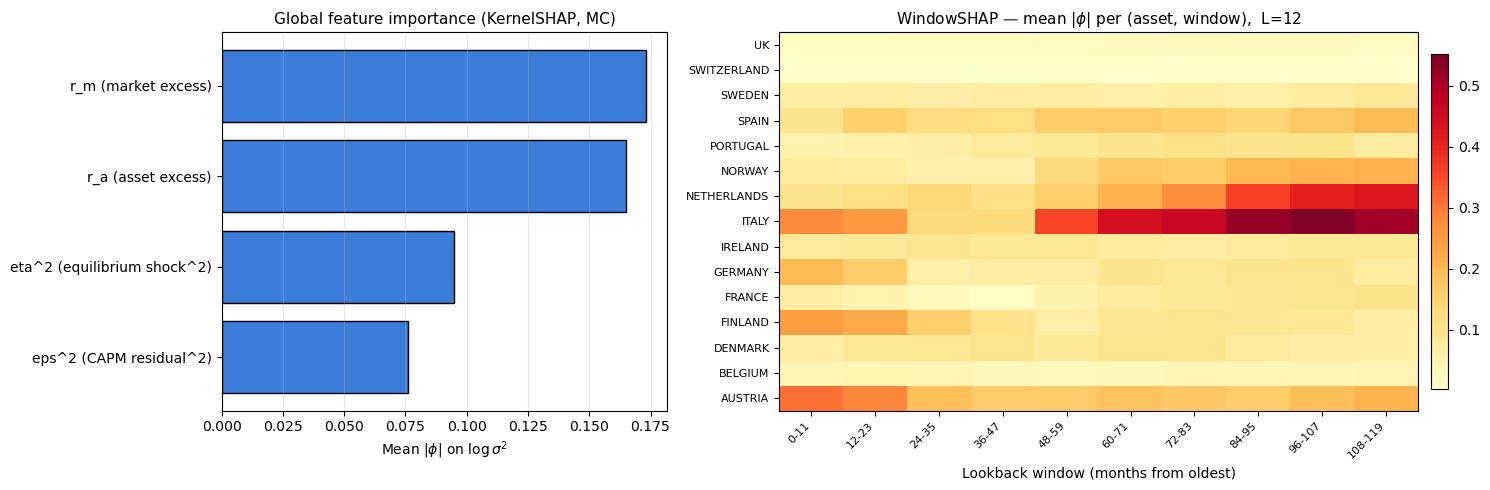

Feature importance share per asset (rows sum to 1):
               r_m    r_a  eta^2  eps^2
AUSTRIA      0.305  0.171  0.283  0.241
BELGIUM      0.492  0.404  0.075  0.028
DENMARK      0.128  0.417  0.229  0.227
FINLAND      0.099  0.255  0.213  0.432
FRANCE       0.024  0.432  0.296  0.249
GERMANY      0.208  0.249  0.245  0.298
IRELAND      0.279  0.334  0.179  0.208
ITALY        0.412  0.415  0.149  0.024
NETHERLANDS  0.303  0.331  0.343  0.022
NORWAY       0.359  0.270  0.312  0.060
PORTUGAL     0.543  0.257  0.048  0.152
SPAIN        0.483  0.338  0.016  0.163
SWEDEN       0.323  0.619  0.044  0.014
SWITZERLAND  0.237  0.135  0.510  0.118
UK           0.533  0.060  0.382  0.025

WindowSHAP recency per asset:
             Recent-24m share Peak window (months)
AUSTRIA                 0.194                 0-11
BELGIUM                 0.215                12-23
DENMARK                 0.158                36-47
FINLAND                 0.126                 0-11
FRANCE                

In [27]:
# ── Plots: feature SHAP bar chart + WindowSHAP heatmap ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                         gridspec_kw={"width_ratios": [1, 1.5]})

# (a) Global feature importance
ax = axes[0]
order = np.argsort(global_feat)[::-1]
ax.barh([FEATURE_NAMES[i] for i in order][::-1],
        global_feat[order][::-1], color="#3b7dd8", edgecolor="black")
ax.set_xlabel(r"Mean $|\phi|$ on $\log\sigma^2$")
ax.set_title("Global feature importance (KernelSHAP, MC)", fontsize=11)
ax.grid(axis="x", alpha=0.3)

# (b) Per-asset time-window importance heatmap
ax = axes[1]
im = ax.imshow(mean_abs_time, aspect="auto", cmap="YlOrRd", origin="lower")
ax.set_yticks(range(N_att))
ax.set_yticklabels([c.replace("MSCI ", "") for c in cols_att], fontsize=8)
ax.set_xticks(range(K_WIN))
ax.set_xticklabels([f"{a}-{b-1}" for a, b in WIN_BOUNDS], fontsize=8, rotation=45, ha="right")
ax.set_xlabel("Lookback window (months from oldest)")
ax.set_title(rf"WindowSHAP — mean $|\phi|$ per (asset, window),  L={WIN_LEN}", fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)


plt.tight_layout()
plt.show()


# ── Summary tables ─────────────────────────────────────────────────────────
share_per_asset = mean_abs_per_asset / mean_abs_per_asset.sum(axis=1, keepdims=True)
df_feat = pd.DataFrame(share_per_asset,
                       index=[c.replace("MSCI ", "") for c in cols_att],
                       columns=["r_m", "r_a", "eta^2", "eps^2"]).round(3)
print("Feature importance share per asset (rows sum to 1):")
print(df_feat.to_string())

recent_mask = np.zeros(K_WIN, dtype=bool)
recent_mask[-(24 // WIN_LEN):] = True
recent_share = mean_abs_time[:, recent_mask].sum(axis=1) / mean_abs_time.sum(axis=1)
df_time = pd.DataFrame({
    "Recent-24m share": recent_share.round(3),
    "Peak window (months)": [f"{WIN_BOUNDS[j][0]}-{WIN_BOUNDS[j][1]-1}"
                             for j in mean_abs_time.argmax(axis=1)],
}, index=[c.replace("MSCI ", "") for c in cols_att])
print("\nWindowSHAP recency per asset:")
print(df_time.to_string())


## 7. Robustness — Fama–French factor augmentation

Attention-FF3 and Attention-FF5 variants; QLIKE comparison against the CAPM specification and per-asset factor SHAP.

In [32]:
# -------------------------------------------------------------------------
# Load the Fama-French factor file and align it to the asset-level index
# -------------------------------------------------------------------------
FACTOR_FILE = os.path.join("Data", "Factor models.xlsx")

_aliases_ff5 = {
    "MKT-RF": {"mktrf", "mkt", "marketrf", "market", "rmrf"},
    "SMB":    {"smb"},
    "HML":    {"hml"},
    "RMW":    {"rmw"},
    "CMA":    {"cma"},
}


def _norm(s):
    return str(s).lower().replace(" ", "").replace("-", "").replace("_", "")


def _identify_factor_columns(df, aliases):
    cols = {c: _norm(c) for c in df.columns}
    out  = {}
    for canon, names in aliases.items():
        for c, n in cols.items():
            if n in names:
                out[canon] = c
                break
        if canon not in out:
            raise KeyError(f"Could not find a column for {canon!r}; "
                           f"columns available: {list(df.columns)}")
    return out


_book = pd.read_excel(FACTOR_FILE, sheet_name=None)
print(f"Sheets in {FACTOR_FILE}: {list(_book.keys())}")

factor_df = None
for _name, _df in _book.items():
    try:
        _df = _df.copy()
        if _df.index.dtype.kind not in "MO":
            for c in _df.columns:
                try:
                    parsed = pd.to_datetime(_df[c], errors="coerce")
                    if parsed.notna().sum() > 0.8 * len(parsed):
                        _df = _df.set_index(parsed).drop(columns=[c])
                        break
                except Exception:
                    continue
        _df.index = pd.to_datetime(_df.index)
        _identify_factor_columns(_df, _aliases_ff5)
        factor_df = _df
        print(f"  -> Using sheet {_name!r}")
        break
    except KeyError:
        continue

if factor_df is None:
    raise RuntimeError(f"No sheet in {FACTOR_FILE} contains the FF5 set "
                       f"(MKT-RF, SMB, HML, RMW, CMA).")

_factor_cols = _identify_factor_columns(factor_df, _aliases_ff5)
factor_df = factor_df.rename(columns={v: k for k, v in _factor_cols.items()})[
    ["MKT-RF", "SMB", "HML", "RMW", "CMA"]
]

idx_att   = assets.index.intersection(market.index).intersection(market_weights.index)
factor_df = factor_df.reindex(idx_att).ffill(limit=1)

if factor_df.abs().mean().mean() > 1.0:
    factor_df = factor_df / 100.0
    print("Factors appear to be in percent units; converted to decimal.")

print("Factor sample:")
print(factor_df.head(3))
print("Coverage:", factor_df.notna().all(axis=1).sum(), "/", len(factor_df), "months.")

FACTORS_FF3 = ["MKT-RF", "SMB", "HML"]
FACTORS_FF5 = ["MKT-RF", "SMB", "HML", "RMW", "CMA"]

Sheets in Data\Factor models.xlsx: ['Europe_5_Factors']
  -> Using sheet 'Europe_5_Factors'
Factor sample:
            MKT-RF     SMB     HML     RMW     CMA
Date                                              
2002-02-28  0.0041 -0.0002  0.0174  0.0285  0.0465
2002-03-31  0.0508 -0.0048  0.0074  0.0039 -0.0029
2002-04-30 -0.0032  0.0337  0.0476  0.0139  0.0528
Coverage: 286 / 286 months.


In [33]:
# -------------------------------------------------------------------------
# Multi-factor helpers + per-asset Attention pipeline (factor variant)
# -------------------------------------------------------------------------
def factor_regression(r_a, F):
    """OLS r_a on [1, F] per asset over the window.

    r_a : (T, N), F : (T, K). Returns alpha (N,), beta (K, N), eps (T, N).
    """
    T = r_a.shape[0]
    X = np.column_stack([np.ones(T), F])
    coef, *_ = np.linalg.lstsq(X, r_a, rcond=None)
    return coef[0], coef[1:], r_a - X @ coef


def factor_implied_returns(F, beta):
    """pi_i = sum_k beta_{i,k} * mean(f_k)  -- factor risk premia from window."""
    return beta.T @ F.mean(axis=0)


def build_attention_with_factors(model_key, factors_used,
                                 assets_df, market_weights_df, factor_df,
                                 implied_returns, implied_covmatrix,
                                 shocks, attention_record,
                                 WINDOW=120, epochs=1000, lr=1e-3,
                                 batch_size=64, seed=DL_SEED,
                                 online_steps=5, online_lr=1e-4):
    """Per-asset Attention training/prediction with a K-factor regression
    replacing the CAPM step. Feature order: [f_1, ..., f_K, r_a, eta^2, eps^2].
    """
    idx    = assets_df.index
    dates  = idx.to_numpy()
    n      = len(dates)
    N      = assets_df.shape[1]
    cols   = assets_df.columns
    K      = len(factors_used)
    n_feat = K + 3

    implied_returns[model_key]   = pd.DataFrame(np.nan, index=idx, columns=cols)
    implied_covmatrix[model_key] = np.full((n, N, N), np.nan)
    shocks[model_key]            = np.full((n, N),    np.nan)
    attention_record[model_key]  = np.full((n, N, WINDOW), np.nan)

    F_full = factor_df[factors_used].reindex(idx).to_numpy(float)

    # -- Stage 1: per-asset batch training on pre-TEST_START data ---------
    all_Xs    = [[] for _ in range(N)]
    all_eta2s = [[] for _ in range(N)]
    for s in range(WINDOW - 1, n - 1):
        if pd.Timestamp(dates[s]) >= TEST_START:
            break
        r_a  = assets_df.iloc[s - WINDOW + 1 : s + 1].to_numpy(float)
        F_w  = F_full[s - WINDOW + 1 : s + 1]
        if not (np.isfinite(r_a).all() and np.isfinite(F_w).all()):
            continue
        r_next = assets_df.iloc[s + 1].to_numpy(float)
        _, beta, eps = factor_regression(r_a, F_w)
        pi_s     = factor_implied_returns(F_w, beta)
        eps2     = eps ** 2
        eta2_win = (r_a - pi_s[None, :]) ** 2
        eta2_tgt = (r_next - pi_s) ** 2
        for k in range(N):
            X_seq = np.column_stack([F_w,
                                     r_a[:, k:k+1],
                                     eta2_win[:, k:k+1],
                                     eps2[:, k:k+1]]).astype(np.float32)
            if np.isfinite(X_seq).all() and np.isfinite(eta2_tgt[k]):
                all_Xs[k].append(X_seq)
                all_eta2s[k].append(float(eta2_tgt[k]))

    print(f"[{model_key}] Stage 1 - training {N} per-asset models ({n_feat} features) ...")
    models = []
    for k in range(N):
        torch.manual_seed(seed + k)
        m = Attention(n_features=n_feat).to(DEVICE)
        if all_Xs[k]:
            X_k    = torch.tensor(np.stack(all_Xs[k]), dtype=torch.float32)
            eta2_k = torch.tensor(np.array(all_eta2s[k]), dtype=torch.float32)
            train_asset_model(m, X_k, eta2_k,
                              epochs=epochs, lr=lr, batch_size=batch_size)
        models.append(m)
        print(f"  Asset {k+1:2d}/{N}  ({cols[k].replace('MSCI ', '')})  "
              f"{len(all_Xs[k])} obs", end="\r", flush=True)
    print(f"\n[{model_key}] Stage 1 complete.")

    def _predict_at(t):
        r_a_t = assets_df.iloc[t - WINDOW + 1 : t + 1].to_numpy(float)
        F_w   = F_full[t - WINDOW + 1 : t + 1]
        if not (np.isfinite(r_a_t).all() and np.isfinite(F_w).all()):
            return None
        _, beta_t, eps_t = factor_regression(r_a_t, F_w)
        pi_t   = factor_implied_returns(F_w, beta_t)
        eps2_t = eps_t ** 2
        eta2_t = (r_a_t - pi_t[None, :]) ** 2

        implied_returns[model_key].loc[dates[t]] = pi_t
        sigma2_diag = np.full(N, np.nan)
        for k in range(N):
            X_seq = np.column_stack([F_w,
                                     r_a_t[:, k:k+1],
                                     eta2_t[:, k:k+1],
                                     eps2_t[:, k:k+1]]).astype(np.float32)
            if not np.isfinite(X_seq).all():
                continue
            with torch.no_grad():
                log_s2, a_t = models[k](torch.tensor(X_seq[None]).to(DEVICE))
            sigma2_diag[k] = float(torch.exp(log_s2).cpu())
            attention_record[model_key][t, k] = a_t.cpu().numpy()[0]

        sigma2_diag = np.maximum(sigma2_diag, 0.0)
        med = np.nanmedian(sigma2_diag)
        sigma2_diag = np.where(np.isfinite(sigma2_diag), sigma2_diag,
                               med if np.isfinite(med) else 1e-4)
        sigma_pi = np.sqrt(sigma2_diag)
        Phi      = sample_correlation(r_a_t)
        implied_covmatrix[model_key][t] = (
            np.diag(sigma_pi) @ Phi @ np.diag(sigma_pi)
        )
        if t + 1 < n:
            shocks[model_key][t] = (
                assets_df.iloc[t + 1].reindex(cols).to_numpy(float) - pi_t
            )
        return r_a_t, F_w, pi_t, eps2_t

    # -- Stage 2: in-sample predictions ------------------------------------
    train_indices = [t for t in range(WINDOW - 1, n)
                     if pd.Timestamp(dates[t]) < TEST_START]
    print(f"[{model_key}] Stage 2 - in-sample predictions over "
          f"{len(train_indices)} dates ...")
    for step, t in enumerate(train_indices):
        if step % 20 == 0:
            print(f"  {pd.Timestamp(dates[t]).strftime('%Y-%m')} "
                  f"({step + 1}/{len(train_indices)})", end="\r", flush=True)
        _predict_at(t)
    print(f"\n[{model_key}] Stage 2 complete.")

    # -- Stage 3: test period with online fine-tuning ----------------------
    test_indices = [t for t in range(WINDOW - 1, n - 1)
                    if pd.Timestamp(dates[t]) >= TEST_START]
    print(f"[{model_key}] Stage 3 - online learning over "
          f"{len(test_indices)} dates ...")
    for step, t in enumerate(test_indices):
        if step % 12 == 0:
            print(f"  {pd.Timestamp(dates[t]).strftime('%Y-%m')} "
                  f"({step + 1}/{len(test_indices)})", end="\r", flush=True)
        out = _predict_at(t)
        if out is None:
            continue
        r_a_t, F_w, pi_t, eps2_t = out
        r_next_t   = assets_df.iloc[t + 1].reindex(cols).to_numpy(float)
        eta2_new   = (r_next_t - pi_t) ** 2
        eta2_win_t = (r_a_t - pi_t[None, :]) ** 2
        for k in range(N):
            X_seq = np.column_stack([F_w,
                                     r_a_t[:, k:k+1],
                                     eta2_win_t[:, k:k+1],
                                     eps2_t[:, k:k+1]]).astype(np.float32)
            if np.isfinite(X_seq).all() and np.isfinite(eta2_new[k]):
                online_update(models[k], X_seq, float(eta2_new[k]),
                              steps=online_steps, lr=online_lr)
    print(f"\n[{model_key}] Stage 3 complete.")
    return models

In [34]:
# -------------------------------------------------------------------------
# Train Attention-FF3 and Attention-FF5, save outputs alongside the baseline
# -------------------------------------------------------------------------
attn_factor_record = {}
factor_models      = {}

for spec_name, spec_factors in [("Attention_FF3", FACTORS_FF3),
                                ("Attention_FF5", FACTORS_FF5)]:
    factor_models[spec_name] = build_attention_with_factors(
        model_key=spec_name,
        factors_used=spec_factors,
        assets_df=assets.loc[idx_att],
        market_weights_df=market_weights.loc[idx_att],
        factor_df=factor_df,
        implied_returns=implied_returns,
        implied_covmatrix=implied_covmatrix,
        shocks=shocks,
        attention_record=attn_factor_record,
        WINDOW=120, epochs=1000, lr=1e-3, batch_size=64,
        seed=DL_SEED, online_steps=5, online_lr=1e-4,
    )

for spec_name in ["Attention_FF3", "Attention_FF5"]:
    implied_returns[spec_name].to_csv(
        os.path.join(out_dir, f"implied_returns_{spec_name}.csv"))
    np.save(os.path.join(out_dir, f"implied_covmatrix_{spec_name}.npy"),
            implied_covmatrix[spec_name])
    pd.DataFrame(shocks[spec_name], index=idx_att,
                 columns=assets.loc[idx_att].columns).to_csv(
        os.path.join(out_dir, f"shocks_{spec_name}.csv"))
    print(f"Saved implied_returns_{spec_name}.csv, "
          f"implied_covmatrix_{spec_name}.npy, "
          f"shocks_{spec_name}.csv")

[Attention_FF3] Stage 1 - training 15 per-asset models (6 features) ...
  Asset 15/15  (UK)  96 obs)  96 obs
[Attention_FF3] Stage 1 complete.
[Attention_FF3] Stage 2 - in-sample predictions over 96 dates ...
  2018-09 (81/96)
[Attention_FF3] Stage 2 complete.
[Attention_FF3] Stage 3 - online learning over 70 dates ...
  2025-01 (61/70)
[Attention_FF3] Stage 3 complete.
[Attention_FF5] Stage 1 - training 15 per-asset models (8 features) ...
  Asset 15/15  (UK)  96 obs)  96 obs
[Attention_FF5] Stage 1 complete.
[Attention_FF5] Stage 2 - in-sample predictions over 96 dates ...
  2018-09 (81/96)
[Attention_FF5] Stage 2 complete.
[Attention_FF5] Stage 3 - online learning over 70 dates ...
  2025-01 (61/70)
[Attention_FF5] Stage 3 complete.
Saved implied_returns_Attention_FF3.csv, implied_covmatrix_Attention_FF3.npy, shocks_Attention_FF3.csv
Saved implied_returns_Attention_FF5.csv, implied_covmatrix_Attention_FF5.npy, shocks_Attention_FF5.csv


In [35]:
# -------------------------------------------------------------------------
# QLIKE comparison: Attention (CAPM) vs Attention-FF3 vs Attention-FF5
# -------------------------------------------------------------------------


def _uni_qlike(eta, Psi):
    """eta: (n, N); Psi: (n, N, N). Returns per-asset QLIKE (n, N)."""
    s2 = np.einsum("tii->ti", Psi)
    out  = np.full_like(eta, np.nan, dtype=float)
    mask = np.isfinite(eta) & np.isfinite(s2) & (s2 > 0)
    out[mask] = np.log(s2[mask]) + (eta[mask] ** 2) / s2[mask]
    return out


def _mv_qlike(eta, Psi):
    """(1/N) * [log det(Psi) + eta' Psi^{-1} eta] per date."""
    n_t, N_t, _ = Psi.shape
    out = np.full(n_t, np.nan)
    for t in range(n_t):
        e, P = eta[t], Psi[t]
        if not (np.isfinite(e).all() and np.isfinite(P).all()):
            continue
        try:
            sign, logdet = np.linalg.slogdet(P)
            if sign <= 0:
                continue
            out[t] = (logdet + float(e @ np.linalg.solve(P, e))) / N_t
        except np.linalg.LinAlgError:
            continue
    return out


def _mcw(mw_df, idx, cols):
    w = mw_df.reindex(idx).reindex(columns=cols).to_numpy(float)
    w = np.where(np.isfinite(w), w, 0.0)
    s = w.sum(axis=1, keepdims=True)
    return np.divide(w, s, out=np.zeros_like(w), where=s > 0)


SPECS  = ["Attention", "Attention_FF3", "Attention_FF5"]
LABELS = {"Attention":     "Attention (CAPM)",
          "Attention_FF3": "Attention (FF3)",
          "Attention_FF5": "Attention (FF5)"}
cols_q    = assets.loc[idx_att].columns
mc_w      = _mcw(market_weights, idx_att, cols_q)
test_mask = np.array([pd.Timestamp(d) >= TEST_START for d in idx_att])

rows = []
uni_series = {}
mv_series  = {}
for spec in SPECS:
    eta = shocks[spec]
    Psi = implied_covmatrix[spec]
    uni = _uni_qlike(eta, Psi)
    mv  = _mv_qlike(eta, Psi)
    uni_mcw = np.nansum(uni * mc_w, axis=1)
    uni_series[spec] = uni_mcw
    mv_series[spec]  = mv
    rows.append({
        "Model": LABELS[spec],
        "Uni mean (full)":   np.nanmean(uni_mcw),
        "Uni median (full)": np.nanmedian(uni_mcw),
        "Uni mean (test)":   np.nanmean(uni_mcw[test_mask]),
        "Uni median (test)": np.nanmedian(uni_mcw[test_mask]),
        "Mv mean (full)":    np.nanmean(mv),
        "Mv median (full)":  np.nanmedian(mv),
        "Mv mean (test)":    np.nanmean(mv[test_mask]),
        "Mv median (test)":  np.nanmedian(mv[test_mask]),
    })

qlike_table = pd.DataFrame(rows).set_index("Model").round(4)
print("\nQLIKE comparison (univariate is market-cap weighted):")
display(qlike_table)


def _hac_dm(diff_series, maxlags=6):
    d = diff_series[np.isfinite(diff_series)]
    T = len(d)
    if T < 4:
        return np.nan, np.nan
    res = sm.OLS(np.asarray(d), np.ones(T)).fit(
        cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return float(d.mean() / res.bse[0]), float(res.pvalues[0])


def _stars(p):
    if not np.isfinite(p):
        return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""


print("\nDiebold-Mariano vs Attention (CAPM) on the test period (HAC, maxlags=6):")
print("negative => row spec has lower QLIKE than Attention (CAPM)")
dm_rows = []
for spec in ["Attention_FF3", "Attention_FF5"]:
    u_stat, u_p = _hac_dm((uni_series[spec] - uni_series["Attention"])[test_mask])
    m_stat, m_p = _hac_dm((mv_series[spec]  - mv_series["Attention"])[test_mask])
    dm_rows.append({
        "Spec":            LABELS[spec],
        "DM univariate":   f"{u_stat:+.3f}{_stars(u_p)}  (p={u_p:.3f})",
        "DM multivariate": f"{m_stat:+.3f}{_stars(m_p)}  (p={m_p:.3f})",
    })
display(pd.DataFrame(dm_rows).set_index("Spec"))


QLIKE comparison (univariate is market-cap weighted):


,Uni mean (full),Uni median (full),Uni mean (test),Uni median (test),Mv mean (full),Mv median (full),Mv mean (test),Mv median (test)
Model,,,,,,,,
Attention (CAPM),-3.0562,-4.0807,-4.8153,-5.7987,-5.7871,-5.9235,-5.4035,-5.5470
Attention (FF3),-3.0138,-4.1496,-4.6293,-5.7815,-5.5753,-5.9294,-4.8764,-5.4576
Attention (FF5),-3.0322,-4.2136,-4.7178,-5.7376,-5.6951,-5.9610,-5.1424,-5.2855



Diebold-Mariano vs Attention (CAPM) on the test period (HAC, maxlags=6):
negative => row spec has lower QLIKE than Attention (CAPM)


,DM univariate,DM multivariate
Spec,,
Attention (FF3),+2.136** (p=0.033),+2.672*** (p=0.008)
Attention (FF5),+1.958* (p=0.050),+6.265*** (p=0.000)


In [36]:
# -------------------------------------------------------------------------
# Per-asset feature SHAP for the factor-augmented Attention models
# (the K factor columns are the players of interest;
#  r_a, eta^2, eps^2 are reported alongside but not ranked)
# -------------------------------------------------------------------------


def _factor_xseq(t, k, factors_used, assets_df, factor_df, cols):
    r_a = assets_df.iloc[t - WINDOW + 1 : t + 1].to_numpy(float)
    F_w = factor_df[factors_used].reindex(assets_df.index)\
              .iloc[t - WINDOW + 1 : t + 1].to_numpy(float)
    if not (np.isfinite(r_a).all() and np.isfinite(F_w).all()):
        return None
    _, beta, eps = factor_regression(r_a, F_w)
    pi   = factor_implied_returns(F_w, beta)
    eps2 = eps ** 2
    eta2 = (r_a - pi[None, :]) ** 2
    X = np.column_stack([F_w, r_a[:, k:k+1],
                         eta2[:, k:k+1], eps2[:, k:k+1]]).astype(np.float32)
    return X if np.isfinite(X).all() else None


def factor_shap_table(model_key, factors_used):
    K          = len(factors_used)
    feat_names = factors_used + ["r_a", "eta^2", "eps^2"]
    spec_mods  = factor_models[model_key]
    a_df       = assets.loc[idx_att]
    cols       = a_df.columns
    N          = len(cols)

    phi = np.full((N, len(SHAP_T), K + 3), np.nan)
    print(f"[{model_key}] Computing per-asset feature SHAP ({K+3} features) ...")
    for k in range(N):
        for di, t in enumerate(SHAP_T):
            X = _factor_xseq(t, k, factors_used, a_df, factor_df, cols)
            if X is None:
                continue
            phi[k, di] = feature_shap(spec_mods[k], X,
                                      n_perms=N_PERMS_FEAT, seed=di)
        print(f"  Asset {k+1:2d}/{N}  ({cols[k].replace('MSCI ', '')})",
              end="\r", flush=True)
    print()

    mean_abs = np.nanmean(np.abs(phi), axis=1)
    totals   = mean_abs.sum(axis=1, keepdims=True)
    share    = np.divide(mean_abs, totals, out=np.zeros_like(mean_abs),
                         where=totals > 0)
    table = pd.DataFrame(share,
                         index=[c.replace("MSCI ", "") for c in cols],
                         columns=feat_names).round(3)
    dom_idx = np.nanargmax(mean_abs[:, :K], axis=1)
    table["Dominant factor"] = [factors_used[i] for i in dom_idx]

    print(f"\nGlobal feature share (mean across countries) - {model_key}:")
    print(table[feat_names].mean(axis=0).round(3).to_string())
    print(f"\nPer-country feature share and dominant factor - {model_key}:")
    display(table)
    return table


shap_table_ff3 = factor_shap_table("Attention_FF3", FACTORS_FF3)
shap_table_ff5 = factor_shap_table("Attention_FF5", FACTORS_FF5)

[Attention_FF3] Computing per-asset feature SHAP (6 features) ...
  Asset 15/15  (UK)TZERLAND)

Global feature share (mean across countries) - Attention_FF3:
MKT-RF    0.154
SMB       0.140
HML       0.216
r_a       0.189
eta^2     0.190
eps^2     0.111

Per-country feature share and dominant factor - Attention_FF3:


,MKT-RF,SMB,HML,r_a,eta^2,eps^2,Dominant factor
AUSTRIA,0.234,0.056,0.124,0.295,0.102,0.190,MKT-RF
BELGIUM,0.083,0.013,0.454,0.360,0.042,0.049,HML
DENMARK,0.098,0.147,0.435,0.103,0.081,0.137,HML
FINLAND,0.111,0.045,0.191,0.391,0.144,0.119,HML
FRANCE,0.086,0.236,0.390,0.154,0.123,0.011,HML
GERMANY,0.104,0.232,0.151,0.006,0.303,0.204,SMB
IRELAND,0.061,0.367,0.259,0.012,0.171,0.130,SMB
ITALY,0.081,0.021,0.200,0.265,0.389,0.043,HML
NETHERLANDS,0.233,0.098,0.275,0.338,0.016,0.040,HML
NORWAY,0.117,0.081,0.182,0.265,0.296,0.059,HML


[Attention_FF5] Computing per-asset feature SHAP (8 features) ...
  Asset 15/15  (UK)TZERLAND)

Global feature share (mean across countries) - Attention_FF5:
MKT-RF    0.108
SMB       0.065
HML       0.140
RMW       0.148
CMA       0.163
r_a       0.137
eta^2     0.154
eps^2     0.085

Per-country feature share and dominant factor - Attention_FF5:


,MKT-RF,SMB,HML,RMW,CMA,r_a,eta^2,eps^2,Dominant factor
AUSTRIA,0.115,0.020,0.006,0.037,0.327,0.053,0.344,0.099,CMA
BELGIUM,0.052,0.009,0.207,0.259,0.284,0.012,0.081,0.095,CMA
DENMARK,0.062,0.058,0.010,0.018,0.292,0.502,0.053,0.005,CMA
FINLAND,0.052,0.076,0.231,0.127,0.330,0.011,0.116,0.057,CMA
FRANCE,0.085,0.074,0.009,0.123,0.029,0.396,0.253,0.031,RMW
GERMANY,0.163,0.069,0.086,0.146,0.160,0.166,0.121,0.088,MKT-RF
IRELAND,0.025,0.091,0.357,0.266,0.026,0.125,0.040,0.070,HML
ITALY,0.073,0.033,0.185,0.009,0.045,0.403,0.177,0.074,HML
NETHERLANDS,0.216,0.020,0.306,0.334,0.062,0.018,0.044,0.000,RMW
NORWAY,0.266,0.017,0.088,0.270,0.174,0.039,0.076,0.069,RMW


## 8. Robustness — test-period boundary sweep 

Re-estimation at every monthly boundary in a ±24-month window around the canonical 2020-01 train/test split.

In [37]:
# ── Robustness setup ──────────────────────────────────────────────────────

ROBUST_DIR    = os.path.join(out_dir, "robustness")
os.makedirs(ROBUST_DIR, exist_ok=True)

CANONICAL_TS  = pd.Timestamp("2020-01-01")
OFFSETS       = list(range(-24, 25))                # -36 .. +36 inclusive (73)
ROBUST_METHODS = ["Classical", "Sample_based", "FH", "Allaj", "Attention"]
ROBUST_EPOCHS  = 1000                                # match production training
ROBUST_BATCH   = 64
ROBUST_LR      = 1e-3
ROBUST_ONLINE  = (5, 1e-4)                           # (online_steps, online_lr)

cols_robust = assets.columns
idx_robust  = assets.index.intersection(market.index).intersection(market_weights.index)

def _retrain_attention_at(test_start_ts):
    """Retrain the Attention model with a custom TEST_START. Overwrites
    implied_returns['Attention'], implied_covmatrix['Attention'], shocks['Attention']
    in-place. Returns nothing — read the dicts after the call."""
    global TEST_START
    old_ts = TEST_START
    TEST_START = pd.Timestamp(test_start_ts)
    try:
        build_online_tahn_predictions(
            assets.loc[idx_robust], market.loc[idx_robust],
            market_weights.loc[idx_robust],
            implied_returns, implied_covmatrix, shocks,
            model_cls=Attention, WINDOW=120,
            epochs=ROBUST_EPOCHS, lr=ROBUST_LR, batch_size=ROBUST_BATCH,
            seed=DL_SEED, online_steps=ROBUST_ONLINE[0], online_lr=ROBUST_ONLINE[1])
    finally:
        TEST_START = old_ts


def _per_date_qlike(method_name, multivariate=False):
    """Return a Series of per-date QLIKE for `method_name`. Mirrors cells 12/13."""
    idx0   = implied_returns[method_name].index
    out    = pd.Series(np.nan, index=idx0)
    dates0 = idx0.to_numpy()
    for i in range(len(dates0) - 1):
        date, next_date = dates0[i], dates0[i + 1]
        if next_date not in assets.index:
            continue
        r_next = assets.loc[next_date].reindex(cols_robust).to_numpy(float)
        mu     = implied_returns[method_name].loc[date].to_numpy(float)
        Psi    = implied_covmatrix[method_name][i].astype(float)

        if not multivariate:
            if date not in market_weights.index:
                continue
            w_raw  = market_weights.loc[date].reindex(cols_robust).to_numpy(float)
            sigma2 = np.diag(Psi)
            mask   = np.isfinite(mu) & (sigma2 > 0) & np.isfinite(r_next) & np.isfinite(w_raw)
            if mask.sum() == 0:
                continue
            mu_m, s2_m, r_m_, w_m = mu[mask], sigma2[mask], r_next[mask], w_raw[mask]
            w_m = w_m / w_m.sum()
            eps2 = (r_m_ - mu_m) ** 2
            out.loc[next_date] = float(w_m @ (np.log(s2_m) + eps2 / s2_m))
        else:
            mask = np.isfinite(mu) & np.isfinite(r_next) & np.all(np.isfinite(Psi), axis=1)
            if mask.sum() == 0:
                continue
            mu_m, r_m_, Psi_m = mu[mask], r_next[mask], Psi[np.ix_(mask, mask)]
            N_m = int(mask.sum())
            eigvals, eigvecs = np.linalg.eigh(Psi_m)
            pos = eigvals > 1e-12
            if pos.sum() == 0:
                continue
            logdet   = float(np.sum(np.log(eigvals[pos])))
            pinv_Psi = eigvecs[:, pos] @ np.diag(1.0 / eigvals[pos]) @ eigvecs[:, pos].T
            quad     = float((r_m_ - mu_m) @ pinv_Psi @ (r_m_ - mu_m))
            out.loc[next_date] = (logdet + quad) / N_m
    return out


# Pre-compute per-date QLIKE for the 4 BL benchmarks ONCE (boundary-invariant).
print("Pre-computing QLIKE for BL benchmarks (boundary-invariant) ...")
BL_UNI = {m: _per_date_qlike(m, multivariate=False) for m in ROBUST_METHODS if m != "Attention"}
BL_MV  = {m: _per_date_qlike(m, multivariate=True ) for m in ROBUST_METHODS if m != "Attention"}
print("  done.")


Pre-computing QLIKE for BL benchmarks (boundary-invariant) ...
  done.


In [38]:
# ── Sweep: retrain at each boundary, save per-date Attention QLIKE ────────

def _ckpt_path(off):
    sign = "+" if off >= 0 else "-"
    return os.path.join(ROBUST_DIR, f"b{sign}{abs(off):02d}.npz")

t0 = time.time()
done = sum(1 for o in OFFSETS if os.path.exists(_ckpt_path(o)))
print(f"{len(OFFSETS)} boundaries total, {done} already on disk, {len(OFFSETS) - done} to run.")

for k, off in enumerate(OFFSETS, start=1):
    ckpt = _ckpt_path(off)
    if os.path.exists(ckpt):
        continue
    ts_b = CANONICAL_TS + relativedelta(months=off)
    print(f"\n[{k}/{len(OFFSETS)}]  offset {off:+d}m  TEST_START = {ts_b.strftime('%Y-%m')}  ...")
    t_b = time.time()

    _retrain_attention_at(ts_b)
    att_uni = _per_date_qlike("Attention", multivariate=False)
    att_mv  = _per_date_qlike("Attention", multivariate=True )

    np.savez(ckpt,
             uni_dates = att_uni.index.values.astype("datetime64[ns]"),
             uni_vals  = att_uni.values.astype(float),
             mv_dates  = att_mv.index.values.astype("datetime64[ns]"),
             mv_vals   = att_mv.values.astype(float),
             test_start = np.array([ts_b.value]))                           # ns since epoch

    elapsed = time.time() - t_b
    eta = (time.time() - t0) / max(k - done, 1) * (len(OFFSETS) - k)
    print(f"   done in {elapsed/60:.1f} min  | rolling ETA {eta/60:.1f} min")

print(f"\nSweep complete in {(time.time()-t0)/60:.1f} min.")


49 boundaries total, 49 already on disk, 0 to run.

Sweep complete in 0.0 min.


Loaded 49 boundaries.
Sample of mean univariate QLIKE per boundary:
     Classical  Sample_based       FH   Allaj  Attention
-24    13.4440      125.0718  15.3701 -1.9701    -4.9482
-23    13.6403      126.2637  15.5494 -1.9221    -4.8558
-22    13.6881      126.5614  15.5762 -1.9066    -4.7594
-21    13.8753      127.6967  15.7683 -1.8608    -4.7549
-20    13.9082      127.9063  15.7555 -1.8786    -4.2854


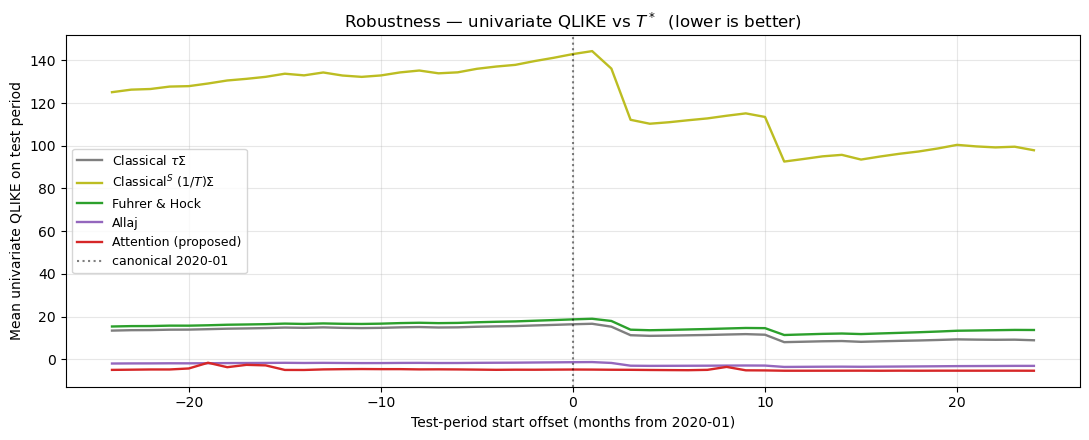

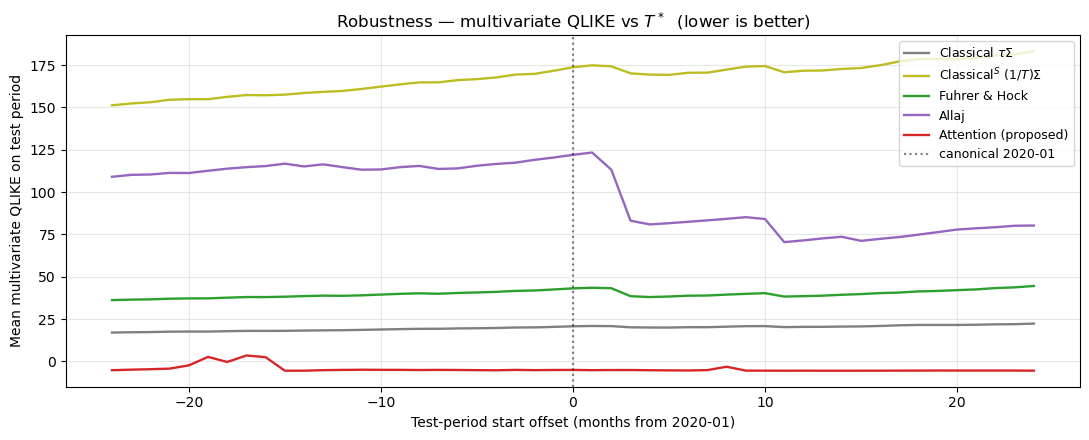

In [39]:
# ── Load checkpoints and assemble per-boundary summary ────────────────────
def _load_ckpt(off):
    sign = "+" if off >= 0 else "-"
    p = os.path.join(ROBUST_DIR, f"b{sign}{abs(off):02d}.npz")
    if not os.path.exists(p):
        return None
    z = np.load(p, allow_pickle=False)
    uni = pd.Series(z["uni_vals"], index=pd.DatetimeIndex(z["uni_dates"]))
    mv  = pd.Series(z["mv_vals"],  index=pd.DatetimeIndex(z["mv_dates"]))
    ts  = pd.Timestamp(int(z["test_start"][0]))
    return ts, uni, mv

# Per-boundary mean QLIKE per method, for both metrics
mean_uni = {m: [] for m in ROBUST_METHODS}
mean_mv  = {m: [] for m in ROBUST_METHODS}
boundary_dates = []
boundary_offsets = []

# Per-boundary per-date series for the DM test
ATT_UNI_BY_OFF = {}
ATT_MV_BY_OFF  = {}

for off in OFFSETS:
    ck = _load_ckpt(off)
    if ck is None:
        continue
    ts_b, att_uni, att_mv = ck
    boundary_dates.append(ts_b)
    boundary_offsets.append(off)

    test_mask = att_uni.index >= ts_b
    for m in ROBUST_METHODS:
        if m == "Attention":
            uni_m, mv_m = att_uni, att_mv
        else:
            uni_m, mv_m = BL_UNI[m], BL_MV[m]
        mean_uni[m].append(float(uni_m[test_mask].mean()))
        mean_mv[m].append (float(mv_m [test_mask].mean()))
    ATT_UNI_BY_OFF[off] = att_uni
    ATT_MV_BY_OFF [off] = att_mv

mean_uni_df = pd.DataFrame(mean_uni, index=boundary_offsets)
mean_mv_df  = pd.DataFrame(mean_mv,  index=boundary_offsets)
print(f"Loaded {len(boundary_offsets)} boundaries.")
print("Sample of mean univariate QLIKE per boundary:")
print(mean_uni_df.head().round(4))


# ── Plots: univariate and multivariate QLIKE vs boundary offset ───────────
PLOT_LBL = {
    "Classical":    r"Classical $\tau\Sigma$",
    "Sample_based": r"Classical$^{S}$ $(1/T)\Sigma$",
    "FH":           "Fuhrer & Hock",
    "Allaj":        "Allaj",
    "Attention":    "Attention (proposed)",
}
COLORS = {"Classical":"#7f7f7f", "Sample_based":"#bcbd22", "FH":"#2ca02c",
          "Allaj":"#9467bd", "Attention":"#d62728"}

fig1, ax = plt.subplots(figsize=(11, 4.5))
for m in ROBUST_METHODS:
    ax.plot(mean_uni_df.index, mean_uni_df[m], label=PLOT_LBL[m],
            color=COLORS[m], linewidth=1.7)
ax.axvline(0, color="black", linestyle=":", alpha=0.5, label="canonical 2020-01")
ax.set_xlabel(r"Test-period start offset (months from 2020-01)")
ax.set_ylabel("Mean univariate QLIKE on test period")
ax.set_title("Robustness — univariate QLIKE vs $T^*$  (lower is better)")
ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()

fig2, ax = plt.subplots(figsize=(11, 4.5))
for m in ROBUST_METHODS:
    ax.plot(mean_mv_df.index, mean_mv_df[m], label=PLOT_LBL[m],
            color=COLORS[m], linewidth=1.7)
ax.axvline(0, color="black", linestyle=":", alpha=0.5, label="canonical 2020-01")
ax.set_xlabel(r"Test-period start offset (months from 2020-01)")
ax.set_ylabel("Mean multivariate QLIKE on test period")
ax.set_title("Robustness — multivariate QLIKE vs $T^*$  (lower is better)")
ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()


In [40]:
# ── Summary table: mean QLIKE + DM significance vs per-boundary 2nd-best ─
def _dm_pvalue(d, maxlags=6):
    """Two-sided p-value of the mean of `d` (HAC SE). d is the per-date diff."""
    d = np.asarray(d, dtype=float); d = d[np.isfinite(d)]
    if len(d) < 4:
        return np.nan, np.nan
    res = sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return float(res.params[0]), float(res.pvalues[0])

def _series_for(method, off, multivariate):
    """Per-date QLIKE series for `method` at boundary `off`."""
    if method == "Attention":
        return (ATT_MV_BY_OFF if multivariate else ATT_UNI_BY_OFF)[off]
    return (BL_MV if multivariate else BL_UNI)[method]

def _build_table(metric_label, multivariate):
    sig_count = {m: {0.10: 0, 0.05: 0, 0.01: 0} for m in ROBUST_METHODS}
    n_bound   = {m: 0 for m in ROBUST_METHODS}

    for off, ts_b in zip(boundary_offsets, boundary_dates):
        # rank methods at this boundary by mean QLIKE
        means = {m: (mean_mv_df if multivariate else mean_uni_df).loc[off, m]
                 for m in ROBUST_METHODS}
        ordered = sorted(ROBUST_METHODS, key=lambda m: means[m])
        best, second = ordered[0], ordered[1]

        for m in ROBUST_METHODS:
            comp = second if m != second else best
            s_m  = _series_for(m, off, multivariate)
            s_c  = _series_for(comp, off, multivariate)
            mask = (s_m.index >= ts_b)
            d    = (s_m[mask] - s_c[mask]).dropna()
            _, p = _dm_pvalue(d)
            if np.isnan(p):
                continue
            n_bound[m] += 1
            for a in (0.10, 0.05, 0.01):
                if p < a:
                    sig_count[m][a] += 1

    means_df = (mean_mv_df if multivariate else mean_uni_df)
    rows = []
    for m in ROBUST_METHODS:
        nb = max(n_bound[m], 1)
        rows.append({
            "Method":       PLOT_LBL[m],
            "Mean QLIKE":   round(means_df[m].mean(), 4),
            "Std QLIKE":    round(means_df[m].std(),  4),
            "n boundaries": int(n_bound[m]),
            "% sig 10%":    f"{100 * sig_count[m][0.10] / nb:5.1f}%",
            "% sig 5%":     f"{100 * sig_count[m][0.05] / nb:5.1f}%",
            "% sig 1%":     f"{100 * sig_count[m][0.01] / nb:5.1f}%",
        })
    df = pd.DataFrame(rows).set_index("Method").sort_values("Mean QLIKE")
    print(f"\n{'='*88}\n{metric_label}\n"
          f"DM tests are vs the per-boundary second-best method "
          f"(or vs the best for the second-best itself).\n{'='*88}")
    print(df.to_string())
    return df

tbl_uni = _build_table("Univariate QLIKE",   multivariate=False)
tbl_mv  = _build_table("Multivariate QLIKE", multivariate=True )

# Save tables for the paper
tbl_uni.to_csv(os.path.join(ROBUST_DIR, "robustness_table_univariate.csv"))
tbl_mv .to_csv(os.path.join(ROBUST_DIR, "robustness_table_multivariate.csv"))
print(f"\nTables saved to {ROBUST_DIR}/robustness_table_*.csv")



Univariate QLIKE
DM tests are vs the per-boundary second-best method (or vs the best for the second-best itself).
                               Mean QLIKE  Std QLIKE  n boundaries % sig 10% % sig 5% % sig 1%
Method                                                                                        
Attention (proposed)              -4.7723     0.7462            49     89.8%    89.8%    59.2%
Allaj                             -2.3676     0.7791            49     89.8%    89.8%    59.2%
Classical $\tau\Sigma$            12.5395     2.8131            49    100.0%   100.0%   100.0%
Fuhrer & Hock                     15.2210     2.0979            49    100.0%   100.0%   100.0%
Classical$^{S}$ $(1/T)\Sigma$    119.6781    16.9291            49    100.0%   100.0%   100.0%

Multivariate QLIKE
DM tests are vs the per-boundary second-best method (or vs the best for the second-best itself).
                               Mean QLIKE  Std QLIKE  n boundaries % sig 10% % sig 5% % sig 1%
Method  

## 9. Robustness — multi-asset universe without constituent data 

Applies the locked *Attention* pipeline and the BL ($\tau\Sigma$), sample-size ($BL^{S}$) and Allaj benchmarks to a ten-asset cross-asset US-listed ETF panel (`SPY, EFA, EEM, IEF, TLT, LQD, AGG, IYR, GLD, DBC`) over the common monthly window Feb 2006–Mar 2026. The Fuhrer–Hock estimator is **structurally infeasible** here — no priced-constituent panel exists, so its Stage-2 loader cannot be formed — and is therefore excluded by construction; the other three BL specifications still run on index-level data. Source data: dividend/split-adjusted ETF total returns (Yahoo Finance) and the 1-month US Treasury bill (Kenneth French), in `Data/Robustness Multi-Asset USD - Excess Returns.xlsx`. The canonical January-2020 train/test split is retained for comparability with Section 5. The cells below output the univariate and multivariate QLIKE summary tables and the Diebold–Mariano pairwise tables, and persist them to `Data/robustness_multiasset_*.csv`.

In [41]:
# =====================================================================
# Section 6.3 — Robustness: multi-asset USD universe (no constituent data)
# ---------------------------------------------------------------------
# Re-runs the *locked* Attention pipeline and the BL / Allaj benchmarks
# on a cross-asset US-listed ETF panel where the Fuhrer-Hock estimator
# is structurally infeasible (no priced-constituent panel exists, so the
# Stage-2 loader of Cell `Fuhrer_and_Hock` cannot be formed). The tau*Sigma,
# sample-size and Allaj specifications still run on index-level data.
#
# Non-destructive: every object is suffixed `_R` and the Attention call
# receives fresh dicts, so the canonical MSCI-Europe globals
# (assets, market, implied_returns, ...) are never overwritten.
# Test split is kept at the canonical TEST_START (Jan 2020) for
# comparability with Section 5.
# =====================================================================

ROB_FILE = os.path.join("Data", "Robustness Multi-Asset USD - Excess Returns.xlsx")

# ---- Load (identical loader convention to the Setup cell) -----------
_xe       = pd.read_excel(ROB_FILE, sheet_name="Market_monthly_excess").set_index("Date").dropna()
market_R  = _xe["MARKET"]
assets_R  = _xe.drop(columns=["MARKET"])
mw_R      = pd.read_excel(ROB_FILE, sheet_name="Market Weights").set_index("Date").dropna()
rf_R      = pd.read_excel(ROB_FILE, sheet_name="RF_monthly_used").set_index("Date").dropna()["RF_monthly"]

idx_R     = assets_R.index.intersection(market_R.index).intersection(mw_R.index)
assets_R  = assets_R.loc[idx_R]
market_R  = market_R.loc[idx_R]
mw_R      = mw_R.loc[idx_R]
dates_R   = idx_R.to_numpy()
n_R       = len(dates_R)
cols_R    = assets_R.columns
N_R       = len(cols_R)

print(f"Robustness universe: {N_R} assets  {list(cols_R)}")
print(f"Sample {pd.Timestamp(dates_R[0]):%Y-%m} .. {pd.Timestamp(dates_R[-1]):%Y-%m} "
      f"({n_R} months) | WINDOW={WINDOW} | TEST_START={TEST_START:%Y-%m} | "
      f"FH excluded (constituent data infeasible)")

# ---- BL / Allaj benchmarks (120-month sliding window) ---------------
BENCH_R = {
    "Classical":    lambda m, a, w: Classical(m, a, w, tau=0.05),
    "Sample_based": Classical_1_T,
    "Allaj":        Allaj,
}
ir_R   = {nm: pd.DataFrame(np.nan, index=idx_R, columns=cols_R) for nm in BENCH_R}
icov_R = {nm: np.full((n_R, N_R, N_R), np.nan)                   for nm in BENCH_R}
shk_R  = {nm: np.full((n_R, N_R), np.nan)                        for nm in BENCH_R}

print("Running 120-month sliding window for BL / Allaj benchmarks ...")
for end in range(WINDOW - 1, n_R):
    wd  = dates_R[end - WINDOW + 1: end + 1]
    m_w = market_R.loc[wd]
    a_w = assets_R.loc[wd]
    w_w = mw_R.loc[wd]
    for nm, fn in BENCH_R.items():
        try:
            pi_hat, Psi, _ = fn(m_w, a_w, w_w)
            pv = pi_hat.reindex(cols_R).to_numpy(float)
            ir_R[nm].iloc[end] = pv
            icov_R[nm][end]    = np.asarray(Psi, float)
            if end + 1 < n_R:
                shk_R[nm][end] = assets_R.iloc[end + 1].to_numpy(float) - pv
        except Exception:
            pass
print("Benchmarks done.")

# ---- Attention model (locked pipeline, fresh dicts) -----------------
_ir_a, _icov_a, _shk_a = {}, {}, {}
attn_R = build_online_tahn_predictions(
    assets_R, market_R, mw_R,
    _ir_a, _icov_a, _shk_a,
    model_cls=Attention, WINDOW=WINDOW, epochs=1000, lr=1e-3,
    batch_size=64, seed=DL_SEED, online_steps=5, online_lr=1e-4)
ir_R["Attention"]   = _ir_a["Attention"]
icov_R["Attention"] = _icov_a["Attention"]
shk_R["Attention"]  = _shk_a["Attention"]
print(f"Attention predictions: {ir_R['Attention'].notna().all(axis=1).sum()} months")


Robustness universe: 10 assets  ['SPY', 'EFA', 'EEM', 'IEF', 'TLT', 'LQD', 'AGG', 'IYR', 'GLD', 'DBC']
Sample 2006-03 .. 2026-03 (241 months) | WINDOW=120 | TEST_START=2020-01 | FH excluded (constituent data infeasible)
Running 120-month sliding window for BL / Allaj benchmarks ...
Benchmarks done.
Stage 1: training one model per asset on all in-sample data ...
  Asset 10/10  (DBC)  47 obs
Stage 1 complete.
Stage 2: in-sample predictions over 47 training dates ...
  2019-06 (41/47)
Stage 2 complete.
Stage 3: online learning over 74 test dates ...
  2026-01 (73/74)
Stage 3 complete.
Done: 47 in-sample + 74 test dates.
Attention predictions: 121 months


In [42]:
# ---- QLIKE evaluation + Diebold-Mariano (Section 6.3) ---------------
# Self-contained QLIKE / DM helpers (same definitions as Section 5/6.1)
# so this block runs independently of cell-execution order.
def _uni_q_R(eta, Psi):
    s2 = np.einsum("tii->ti", Psi)
    o  = np.full_like(eta, np.nan, dtype=float)
    m  = np.isfinite(eta) & np.isfinite(s2) & (s2 > 0)
    o[m] = np.log(s2[m]) + (eta[m] ** 2) / s2[m]
    return o

def _mv_q_R(eta, Psi):
    nt = Psi.shape[0]
    o  = np.full(nt, np.nan)
    for t in range(nt):
        e, P = eta[t], Psi[t]
        if not (np.isfinite(e).all() and np.isfinite(P).all()):
            continue
        try:
            sgn, ld = np.linalg.slogdet(P)
            if sgn <= 0:
                continue
            o[t] = (ld + float(e @ np.linalg.solve(P, e))) / P.shape[0]
        except np.linalg.LinAlgError:
            continue
    return o

def _mcw_R(mw, idx, cols):
    w = mw.reindex(idx).reindex(columns=cols).to_numpy(float)
    w = np.where(np.isfinite(w), w, 0.0)
    s = w.sum(axis=1, keepdims=True)
    return np.divide(w, s, out=np.zeros_like(w), where=s > 0)

def _hac_R(d, maxlags=6):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    if len(d) < 4:
        return np.nan, np.nan
    r = sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return float(d.mean() / r.bse[0]), float(r.pvalues[0])

def _st_R(p):
    if not np.isfinite(p):
        return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

PRETTY_R = {"Classical": r"$BL$", "Sample_based": r"$BL^{S}$",
            "Allaj": r"$Al$", "Attention": r"$Attention$"}
ORDER_R  = ["Classical", "Sample_based", "Allaj", "Attention"]

mcw_R = _mcw_R(mw_R, idx_R, cols_R)
ts_R  = pd.DatetimeIndex(idx_R)
tr_m  = ts_R <  TEST_START
te_m  = ts_R >= TEST_START

uni_R, mv_R = {}, {}
for nm in ORDER_R:
    uni_R[nm] = np.nansum(_uni_q_R(shk_R[nm], icov_R[nm]) * mcw_R, axis=1)
    mv_R[nm]  = _mv_q_R(shk_R[nm], icov_R[nm])

def _summary_R(series_dict, title):
    rows = []
    for nm in ORDER_R:
        s = pd.Series(series_dict[nm], index=ts_R)
        for lab, sub in [("Overall", s), ("Training", s[tr_m]), ("Testing", s[te_m])]:
            v = sub.dropna()
            rows.append({"Method": PRETTY_R[nm], "Period": lab,
                         "Mean": v.mean(), "Std": v.std(), "Median": v.median(),
                         "Min": v.min(), "Max": v.max()})
    df = pd.DataFrame(rows).set_index(["Method", "Period"]).round(4)
    print(f"\n{'=' * 72}\n{title}\n{'=' * 72}")
    display(df)
    return df

uni_tbl_R = _summary_R(uni_R, "Section 6.3  Univariate QLIKE  (market-cap weighted)")
mv_tbl_R  = _summary_R(mv_R,  "Section 6.3  Multivariate QLIKE")

def _dm_tbl_R(series_dict, title):
    rows = []
    for i, a in enumerate(ORDER_R):
        row = {"Model": PRETTY_R[a]}
        for j, b in enumerate(ORDER_R):
            if j >= i:
                row[PRETTY_R[b]] = "—"
                continue
            da = pd.Series(series_dict[a], index=ts_R)[te_m]
            db = pd.Series(series_dict[b], index=ts_R)[te_m]
            stat, p = _hac_R((da - db).to_numpy())
            row[PRETTY_R[b]] = "n/a" if not np.isfinite(stat) else f"{stat:+.4f}{_st_R(p / 2)}"
        rows.append(row)
    df = pd.DataFrame(rows).set_index("Model")
    print(f"\n{title}")
    print("test period | HAC maxlags=6 | one-sided | negative => row has lower QLIKE")
    display(df)
    return df

dm_uni_R = _dm_tbl_R(uni_R, "Section 6.3  DM pairwise — univariate QLIKE")
dm_mv_R  = _dm_tbl_R(mv_R,  "Section 6.3  DM pairwise — multivariate QLIKE")

# ---- Persist for the manuscript -------------------------------------
uni_tbl_R.to_csv(os.path.join("Data", "robustness_multiasset_uni.csv"))
mv_tbl_R .to_csv(os.path.join("Data", "robustness_multiasset_mv.csv"))
dm_uni_R .to_csv(os.path.join("Data", "robustness_multiasset_dm_uni.csv"))
dm_mv_R  .to_csv(os.path.join("Data", "robustness_multiasset_dm_mv.csv"))
print("\nSaved: Data/robustness_multiasset_{uni,mv,dm_uni,dm_mv}.csv")



Section 6.3  Univariate QLIKE  (market-cap weighted)


Mean       Std    Median     Min        Max
Method      Period                                                   
$BL$        Overall     7.2993   23.6274    0.0000 -9.3233   166.0070
            Training    1.1708   10.6306    0.0000 -9.3233    77.7271
            Testing    20.8637   35.8864    8.6521 -8.8891   166.0070
$BL^{S}$    Overall    67.7155  151.0025    0.0000 -8.2708  1045.3262
            Training   20.6404   71.0348    0.0000 -8.2708   514.8329
            Testing   171.9084  216.1632  100.5973 -6.4117  1045.3262
$Al$        Overall    -2.3638    3.7396    0.0000 -7.8081    19.4552
            Training   -1.7338    2.7906    0.0000 -6.7907     0.0000
            Testing    -3.7582    5.0130   -5.5895 -7.8081    19.4552
$Attention$ Overall    -2.8497    3.1174    0.0000 -7.2760     3.0429
            Training   -1.8069    2.9387    0.0000 -7.2760     0.0000
            Testing    -5.1577    2.1036   -5.8119 -7.0251     3.0429


Section 6.3  Multivariate QLIKE


Mean       Std    Median      Min        Max
Method      Period                                                    
$BL$        Overall    13.6045   24.4192    8.5383  -8.6847   177.3132
            Training    2.6331   10.5642   -1.6806  -8.6847    31.4010
            Testing    20.5729   27.9852   15.1042  -7.1404   177.3132
$BL^{S}$    Overall   134.3967  146.9110  103.8765   1.4886  1117.6653
            Training   67.5708   63.6829   42.0280   1.4886   241.8499
            Testing   176.8403  167.9935  144.0142  10.6563  1117.6653
$Al$        Overall     2.5820   20.9865   -5.3801  -7.9260   132.3876
            Training   -5.4993    2.0162   -6.4901  -7.1736     0.6939
            Testing     7.7148   25.5476   -2.8151  -7.9260   132.3876
$Attention$ Overall    -5.7704    2.1495   -6.2388  -8.0189     3.0481
            Training   -6.6850    1.3363   -7.1849  -8.0189    -1.5963
            Testing    -5.1896    2.3642   -5.8534  -7.9285     3.0481


Section 6.3  DM pairwise — univariate QLIKE
test period | HAC maxlags=6 | one-sided | negative => row has lower QLIKE


,$BL$,$BL^{S}$,$Al$,$Attention$
Model,,,,
$BL$,—,—,—,—
$BL^{S}$,+4.6119***,—,—,—
$Al$,-4.3312***,-4.5727***,—,—
$Attention$,-4.2091***,-4.5479***,-1.8665**,—



Section 6.3  DM pairwise — multivariate QLIKE
test period | HAC maxlags=6 | one-sided | negative => row has lower QLIKE


,$BL$,$BL^{S}$,$Al$,$Attention$
Model,,,,
$BL$,—,—,—,—
$BL^{S}$,+6.8941***,—,—,—
$Al$,-2.7070***,-6.7734***,—,—
$Attention$,-6.0513***,-6.7621***,-2.7128***,—



Saved: Data/robustness_multiasset_{uni,mv,dm_uni,dm_mv}.csv


## 10. Portfolio analysis under simulated views

Gofman–Manela (2012) view simulation over the $(\kappa, \delta)$ grid; cumulative-return paths and performance metrics.

In [43]:
def generate_views(pi_hat, Sigma_hat, r_next, kappa=1.0, delta=1.0, n_draws=300, seed=None):
    rng = np.random.default_rng(seed)
    N   = len(pi_hat)
    P   = np.eye(N)

    # view centre: Eq. 60 — reduces to Eq. 59 when kappa=1
    q_center = pi_hat + kappa * (r_next - pi_hat)   # (N,)

    # noise: delta * eps,  eps ~ N(0, Sigma_hat)
    try:
        L     = np.linalg.cholesky(Sigma_hat)
        noise = delta * (rng.standard_normal((n_draws, N)) @ L.T)
    except np.linalg.LinAlgError:
        # fallback: diagonal approximation if Sigma not PD
        std   = np.sqrt(np.clip(np.diag(Sigma_hat), 0, np.inf))
        noise = delta * rng.standard_normal((n_draws, N)) * std[None, :]

    Q = q_center[None, :] + noise    # (n_draws, N)

    # Omega = delta^2 * diag(Sigma) — view error covariance is diagonal
    Omega = np.diag(delta**2 * np.diag(Sigma_hat))

    return P, Q, Omega

In [44]:

def bl_posterior(pi, Psi, Sigma, q, Omega):  #
    """BL posterior with P = I (absolute views). Returns mu_hat, Sigma_post."""  #
    omega_inv = np.where(np.diag(Omega) > 0, 1.0 / np.diag(Omega), 0.0)  #
    try:  #
        Psi_inv = np.linalg.inv(Psi)  #
    except np.linalg.LinAlgError:  #
        Psi_inv = np.linalg.pinv(Psi)  #
    try:  #
        V = np.linalg.inv(Psi_inv + np.diag(omega_inv))  #
    except np.linalg.LinAlgError:  #
        V = np.linalg.pinv(Psi_inv + np.diag(omega_inv))  #
    m          = V @ (Psi_inv @ pi + omega_inv * q)  #
    Sigma_post = Sigma + V  #
    return m, Sigma_post  #

def mv_optimize(mu, Sigma):  #
    """Long-only, fully-invested maximum Sharpe ratio optimisation."""  #
    N  = len(mu)  #
    w0 = np.ones(N) / N  #
    def neg_sharpe(w):  #
        port_ret = w @ mu  #
        port_vol = np.sqrt(np.maximum(w @ Sigma @ w, 1e-12))  #
        return -port_ret / port_vol  #
    def neg_sharpe_jac(w):  #
        port_ret = w @ mu  #
        port_var = np.maximum(w @ Sigma @ w, 1e-12)  #
        port_vol = np.sqrt(port_var)  #
        return -(mu * port_vol - port_ret * (Sigma @ w) / port_vol) / port_var  #
    res = minimize(  #
        fun=neg_sharpe,  #
        x0=w0,  #
        jac=neg_sharpe_jac,  #
        method="SLSQP",  #
        bounds=[(0.0, 1.0)] * N,  #
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1.0},  #
        options={"ftol": 1e-9, "maxiter": 500},  #
    )  #
    return res.x if res.success else w0  #

def compute_metrics(r, r_bench):  #
    """Performance metrics using excess returns."""  #
    r  = r.dropna()  #
    rb = r_bench.loc[r.index].dropna()  #
    r  = r.loc[rb.index]  #
    ret_pa = r.mean() * 12  #
    vol_pa = r.std()  * np.sqrt(12)  #
    sharpe = ret_pa / vol_pa if vol_pa > 0 else np.nan  #
    rel    = ret_pa - rb.mean() * 12  #
    te     = (r - rb).std() * np.sqrt(12)  #
    ir     = rel / te if te > 0 else np.nan  #
    ols    = sm.OLS(r, sm.add_constant(rb)).fit()  #
    alpha  = ols.params.iloc[0] * 12  #
    beta   = ols.params.iloc[1]  #
    return {  #
        "Return p.a. (%)": round(ret_pa * 100, 2),  #
        "Volatility p.a. (%)": round(vol_pa * 100, 2),  #
        "Sharpe Ratio": round(sharpe, 4),  #
        "Rel. Return p.a. (%)": round(rel * 100, 2),  #
        "Tracking Error p.a. (%)": round(te * 100, 2),  #
        "Information Ratio": round(ir, 4),  #
        "Beta": round(beta, 4),  #
        "Alpha p.a. (%)": round(alpha * 100, 2),  #
        "T-stat Alpha": round(ols.tvalues.iloc[0], 4),  #
        "P-val Alpha": round(ols.pvalues.iloc[0], 4),  #
    }  #


In [45]:
N_DRAWS = 100
KAPPAS  = [0, 0.5, 1]
DELTAS  = [1, 2, 4, 8,16,32]
WINDOW  = 120

cols  = assets.columns
N     = len(cols)
idx   = implied_returns["Classical"].index
dates = idx.to_numpy()
n     = len(dates)

def bl_posterior_batch(pi, Psi, Sig, Q, Omega):
    """Q: (n_draws, N). Returns M: (n_draws, N), Sigma_post: (N, N)."""
    omega_inv = np.where(np.diag(Omega) > 0, 1.0 / np.diag(Omega), 0.0)
    try:
        Psi_inv = np.linalg.inv(Psi)
    except np.linalg.LinAlgError:
        Psi_inv = np.linalg.pinv(Psi)
    try:
        V = np.linalg.inv(Psi_inv + np.diag(omega_inv))
    except np.linalg.LinAlgError:
        V = np.linalg.pinv(Psi_inv + np.diag(omega_inv))
    const = V @ (Psi_inv @ pi)
    M     = const[None, :] + (V @ (omega_inv[:, None] * Q.T)).T
    return M, Sig + V

# ── 1. MSCI Europe benchmark returns (test period only) ───────────────────
market_ret     = pd.Series(np.nan, index=idx)
market_ret_raw = pd.Series(np.nan, index=idx)
for i in range(WINDOW - 1, n - 1):
    date, next_date = dates[i], dates[i + 1]
    if pd.Timestamp(date) < TEST_START:
        continue
    if next_date not in raw_market.index:
        continue
    rf_val_i = float(rf.loc[next_date]) if next_date in rf.index else 0.0
    market_ret.loc[date]     = float(raw_market.loc[next_date]) - rf_val_i
    market_ret_raw.loc[date] = float(raw_market.loc[next_date])

# ── 2. Pre-cache window data (test period only) ───────────────────────────
print("Caching window data (test period) ...", end=" ", flush=True)
window_cache = []

for i in range(WINDOW - 1, n - 1):
    date      = dates[i]
    next_date = dates[i + 1]

    if pd.Timestamp(date) < TEST_START:
        continue
    if next_date not in assets.index or next_date not in raw_assets.index:
        continue

    r_next     = assets.loc[next_date].reindex(cols).to_numpy(dtype=float)
    r_next_raw = raw_assets.loc[next_date].reindex(cols).to_numpy(dtype=float)
    if not np.isfinite(r_next).all() or not np.isfinite(r_next_raw).all():
        continue

    rf_val = float(rf.loc[next_date]) if next_date in rf.index else 0.0

    # Market lambda from excess return window
    rm_win   = market.iloc[i - WINDOW + 1 : i + 1].to_numpy(dtype=float)
    sigma2_m = rm_win.var(ddof=1)
    lam      = rm_win.mean() / sigma2_m if sigma2_m > 0 else 1.0

    # Sample covariance of asset excess returns in window (Sigma)
    ra_win = assets.iloc[i - WINDOW + 1 : i + 1].reindex(columns=cols).to_numpy(dtype=float)
    valid  = np.isfinite(ra_win).all(axis=1)
    ra_win = ra_win[valid]
    Sig_win = np.cov(ra_win.T) if ra_win.shape[0] > 1 else np.eye(N) * 1e-4

    rng = np.random.default_rng(seed=i)
    z   = rng.standard_normal((N_DRAWS, N))

    models = {}
    for name in METHODS:
        pi  = implied_returns[name].loc[date].to_numpy(dtype=float)
        Psi = implied_covmatrix[name][i].astype(float)
        if not (np.isfinite(pi).all() and np.isfinite(Psi).all() and np.isfinite(Sig_win).all()):
            models[name] = None
            continue
        try:
            noise_base = z @ np.linalg.cholesky(Sig_win).T
        except np.linalg.LinAlgError:
            noise_base = z * np.sqrt(np.clip(np.diag(Sig_win), 0, np.inf))[None, :]
        models[name] = {
            "pi":         pi,
            "Psi":        Psi,
            "Sig":        Sig_win,
            "noise_base": noise_base,
            "sig_diag":   np.diag(Sig_win),
        }

    window_cache.append({
        "date":       date,
        "r_next":     r_next,
        "r_next_raw": r_next_raw,
        "rf_val":     rf_val,
        "lam":        lam,
        "models":     models,
    })

print(f"done  ({len(window_cache)} test windows).")

Caching window data (test period) ... 

done  (70 test windows).


In [ ]:
METHODS ={'Classical': 'Classical',
 'Sample_based': 'Classical$^{S}$',
 'FH': 'Fuhrer & Hock',
 'Allaj': 'Allaj',
 'Attention': 'Attention'}


═════════════════════════════════════════════════════════════════
  κ = 0  —  No Skill
═════════════════════════════════════════════════════════════════
  δ =  1 ... done


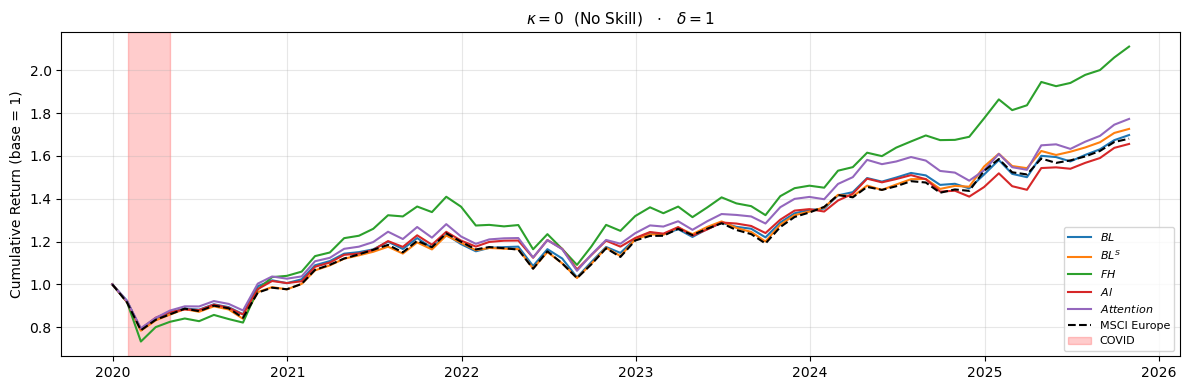

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,8.84,14.99,0.5899,0.19,2.91,0.0669,0.9907,0.27,0.2235,0.8238
$BL^{S}$,9.13,14.97,0.6098,0.48,0.88,0.5462,1.0069,0.42,1.1385,0.2589
$FH$,13.04,17.52,0.7444,4.39,5.79,0.7588,1.1204,3.35,1.4386,0.1549
$Al$,8.32,14.36,0.5796,-0.33,4.09,-0.0804,0.9296,0.28,0.1675,0.8675
$Attention$,9.58,14.87,0.6439,0.93,4.38,0.2115,0.9582,1.29,0.7023,0.4849
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  2 ... done


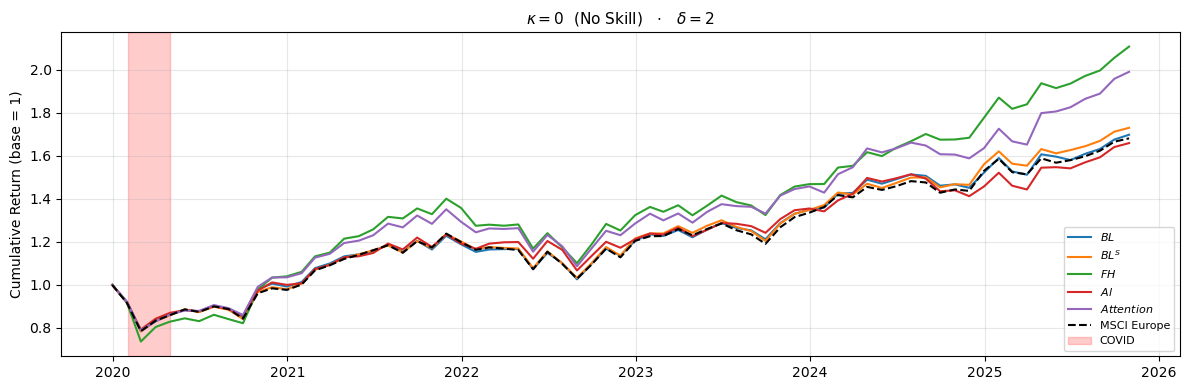

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,8.85,15.03,0.5888,0.20,2.18,0.0905,1.0015,0.18,0.1998,0.8422
$BL^{S}$,9.17,15.01,0.6109,0.52,0.78,0.6683,1.0097,0.43,1.3485,0.1820
$FH$,12.97,17.31,0.7488,4.32,5.32,0.8108,1.1158,3.31,1.5550,0.1246
$Al$,8.33,14.25,0.5849,-0.32,4.19,-0.0756,0.9207,0.37,0.2170,0.8289
$Attention$,11.65,15.44,0.7547,3.00,4.81,0.6240,0.9883,3.10,1.5257,0.1317
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  4 ... done


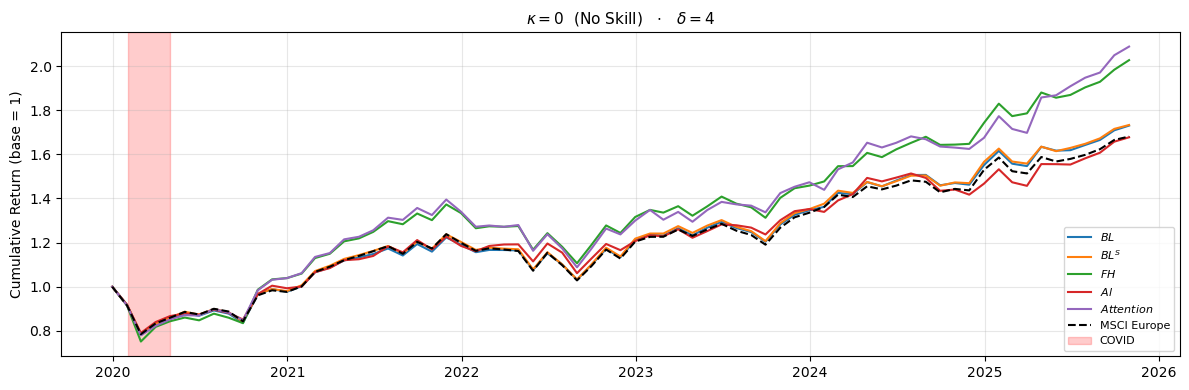

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.18,15.05,0.6101,0.53,1.33,0.3990,1.0096,0.45,0.8002,0.4264
$BL^{S}$,9.20,15.01,0.6129,0.55,0.74,0.7486,1.0101,0.46,1.5213,0.1328
$FH$,12.15,16.53,0.7352,3.50,4.01,0.8744,1.0836,2.78,1.7252,0.0890
$Al$,8.52,14.23,0.5991,-0.13,4.00,-0.0313,0.9230,0.54,0.3335,0.7397
$Attention$,12.60,16.16,0.7798,3.95,5.35,0.7395,1.0279,3.71,1.6465,0.1043
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  8 ... done


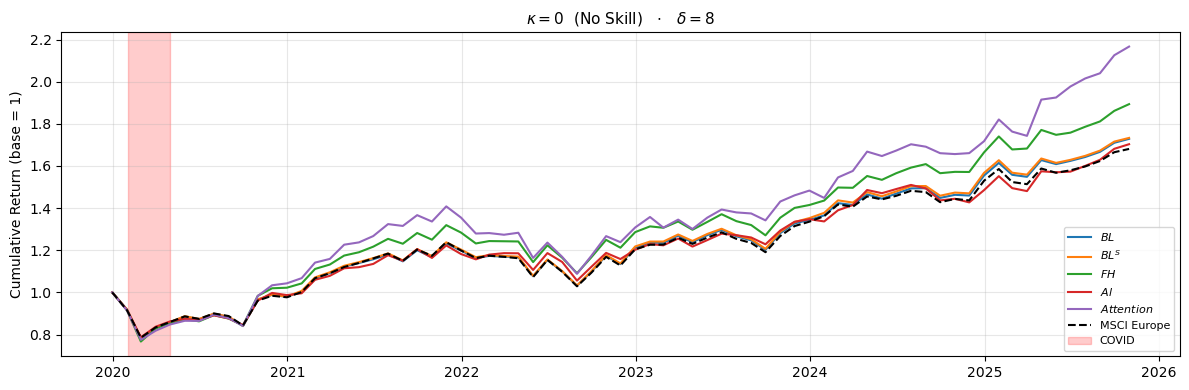

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.16,15.00,0.6106,0.51,0.82,0.6143,1.0086,0.43,1.2535,0.2143
$BL^{S}$,9.20,15.01,0.6129,0.55,0.73,0.7601,1.0103,0.46,1.5424,0.1276
$FH$,10.84,15.71,0.6897,2.19,2.48,0.8817,1.0463,1.79,1.7724,0.0808
$Al$,8.80,14.27,0.6164,0.15,3.58,0.0410,0.9329,0.73,0.4998,0.6188
$Attention$,13.31,16.61,0.8015,4.66,5.66,0.8237,1.0532,4.20,1.7723,0.0808
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ = 16 ... done


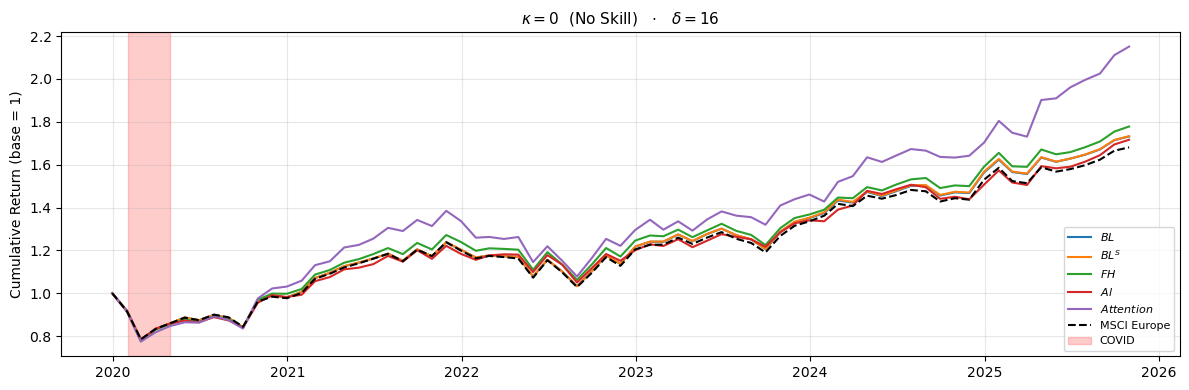

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.19,15.01,0.6122,0.54,0.76,0.7145,1.0099,0.45,1.4481,0.1522
$BL^{S}$,9.20,15.02,0.6127,0.55,0.73,0.7581,1.0104,0.46,1.5350,0.1294
$FH$,9.68,15.20,0.6367,1.03,1.34,0.7680,1.0199,0.85,1.5492,0.1260
$Al$,8.94,14.34,0.6234,0.29,2.95,0.0989,0.9470,0.75,0.6233,0.5352
$Attention$,13.18,16.57,0.7956,4.53,5.32,0.8523,1.0588,4.02,1.8135,0.0742
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ = 32 ... done


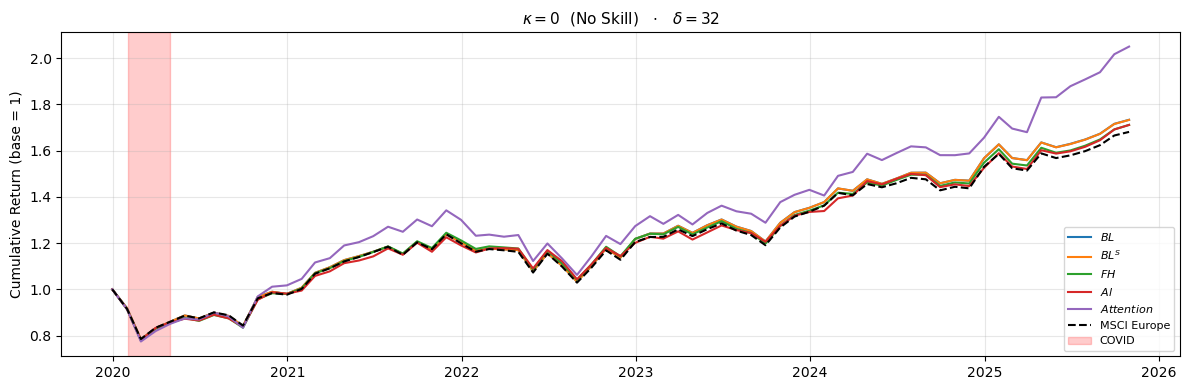

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.20,15.01,0.6130,0.55,0.73,0.7572,1.0102,0.47,1.5385,0.1286
$BL^{S}$,9.20,15.02,0.6125,0.55,0.73,0.7542,1.0104,0.46,1.5245,0.1320
$FH$,8.98,15.01,0.5983,0.33,0.76,0.4363,1.0102,0.25,0.7746,0.4412
$Al$,8.91,14.52,0.6138,0.26,2.14,0.1224,0.9678,0.54,0.6129,0.5420
$Attention$,12.31,16.31,0.7546,3.66,4.32,0.8470,1.0611,3.13,1.7520,0.0843
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430



═════════════════════════════════════════════════════════════════
  κ = 0.5  —  Some Skill
═════════════════════════════════════════════════════════════════
  δ =  1 ... done


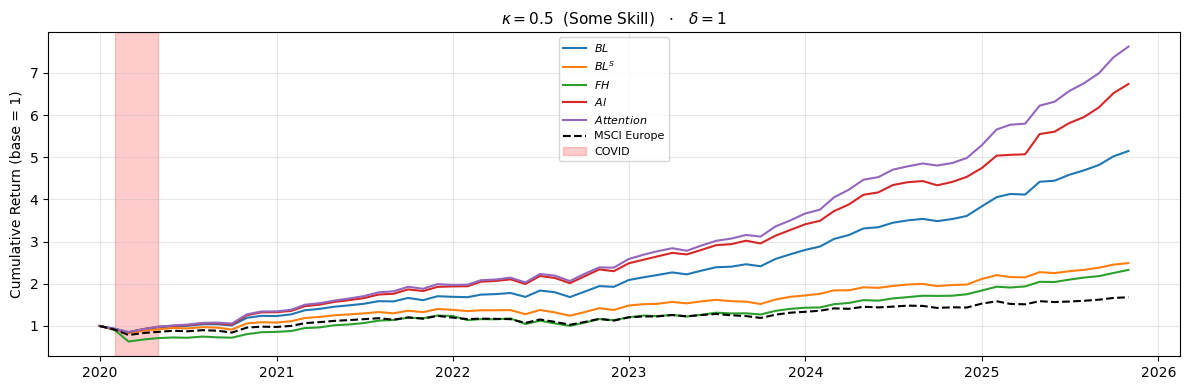

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,27.98,13.92,2.0100,19.33,4.16,4.6500,0.9003,20.19,12.2874,0.0000
$BL^{S}$,15.37,14.31,1.0742,6.72,2.15,3.1289,0.9539,7.12,8.2666,0.0000
$FH$,15.26,19.26,0.7924,6.61,8.96,0.7381,1.1596,5.23,1.4316,0.1568
$Al$,32.85,15.03,2.1849,24.20,5.64,4.2928,0.9407,24.71,10.4924,0.0000
$Attention$,34.97,14.59,2.3974,26.32,5.26,5.0025,0.9198,27.01,12.4604,0.0000
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  2 ... done


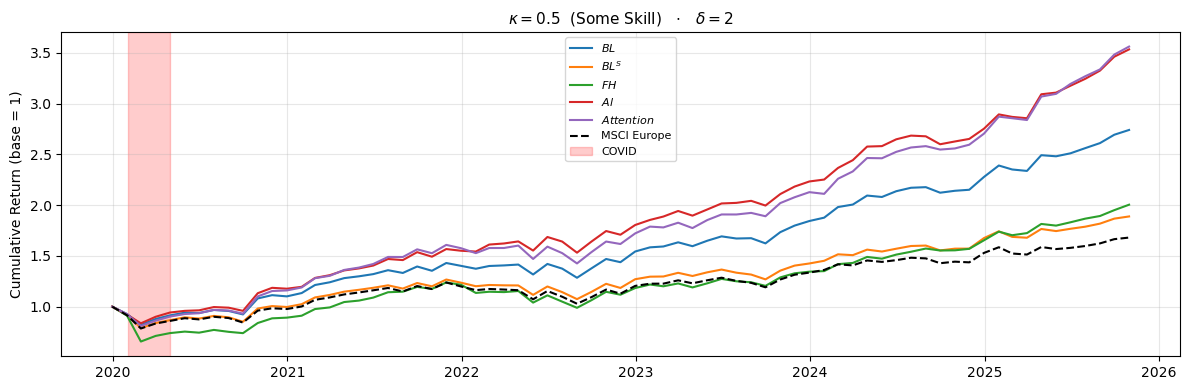

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,17.07,14.57,1.1710,8.42,2.52,3.3444,0.9675,8.70,8.3239,0.0000
$BL^{S}$,10.69,14.99,0.7128,2.04,0.90,2.2712,1.0080,1.97,5.2324,0.0000
$FH$,12.46,18.52,0.6725,3.81,7.43,0.5126,1.1532,2.48,0.8297,0.4096
$Al$,21.43,14.19,1.5108,12.78,4.78,2.6752,0.9048,13.61,7.0474,0.0000
$Attention$,21.75,15.33,1.4186,13.10,4.64,2.8237,0.9843,13.23,6.7526,0.0000
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  4 ... done


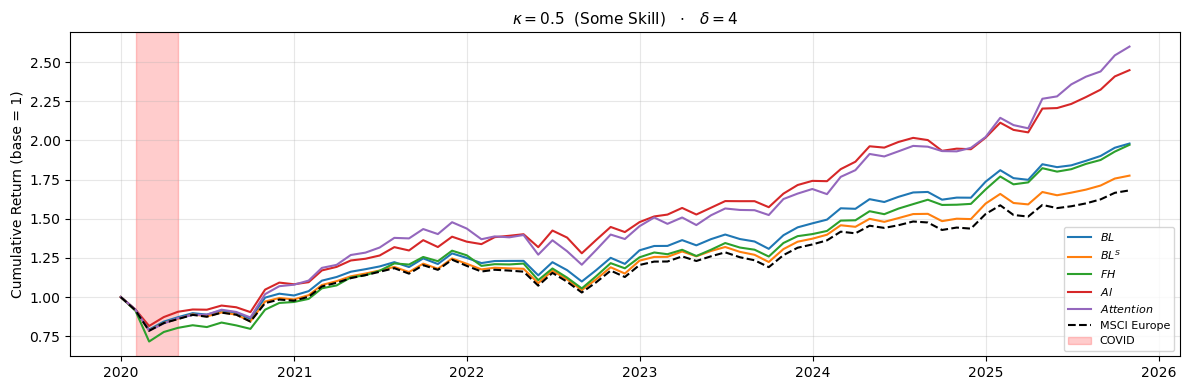

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,11.48,14.89,0.7709,2.83,1.35,2.0912,0.9989,2.84,4.9607,0.0000
$BL^{S}$,9.61,15.01,0.6405,0.96,0.76,1.2628,1.0098,0.88,2.7741,0.0071
$FH$,11.77,16.85,0.6987,3.12,4.60,0.6780,1.0959,2.29,1.2374,0.2202
$Al$,15.03,14.06,1.0692,6.38,4.12,1.5502,0.9100,7.16,4.3475,0.0000
$Attention$,16.38,16.11,1.0170,7.73,5.20,1.4881,1.0274,7.50,3.4204,0.0011
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  8 ... done


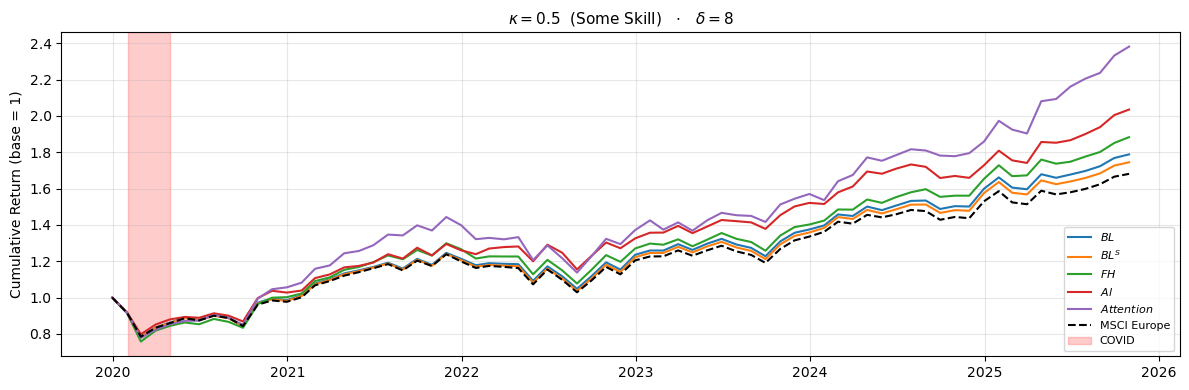

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.74,15.00,0.6493,1.09,0.86,1.2709,1.0087,1.01,2.8295,0.0061
$BL^{S}$,9.31,15.01,0.6203,0.66,0.73,0.9051,1.0102,0.58,1.8970,0.0621
$FH$,10.75,15.69,0.6849,2.10,2.48,0.8473,1.0448,1.71,1.6951,0.0946
$Al$,11.85,14.19,0.8351,3.20,3.56,0.8999,0.9283,3.82,2.6609,0.0097
$Attention$,14.92,16.46,0.9069,6.28,5.53,1.1357,1.0452,5.88,2.5362,0.0135
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ = 16 ... done


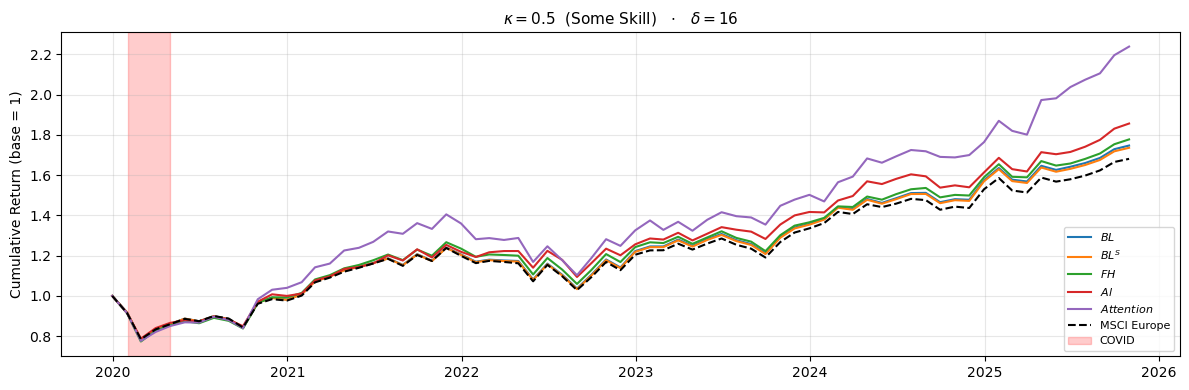

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.34,15.01,0.6221,0.69,0.76,0.9010,1.0098,0.60,1.9018,0.0614
$BL^{S}$,9.23,15.02,0.6147,0.58,0.73,0.7962,1.0104,0.49,1.6280,0.1081
$FH$,9.66,15.17,0.6369,1.02,1.31,0.7755,1.0185,0.85,1.5789,0.1190
$Al$,10.29,14.33,0.7181,1.64,2.92,0.5603,0.9463,2.10,1.7672,0.0817
$Attention$,13.86,16.54,0.8383,5.21,5.27,0.9895,1.0575,4.72,2.1444,0.0356
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ = 32 ... done


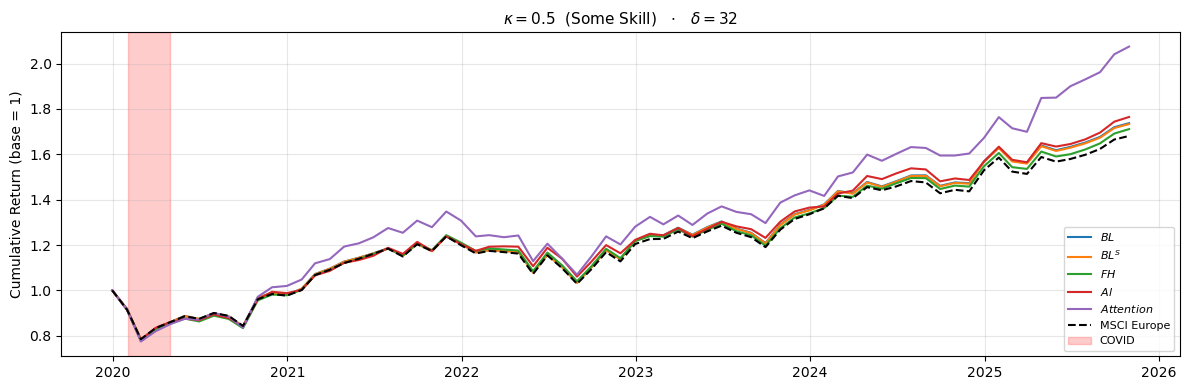

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.24,15.01,0.6157,0.59,0.73,0.8095,1.0101,0.51,1.6665,0.1002
$BL^{S}$,9.21,15.02,0.6130,0.56,0.73,0.7639,1.0104,0.47,1.5481,0.1262
$FH$,8.98,15.01,0.5985,0.33,0.75,0.4398,1.0097,0.25,0.7904,0.4320
$Al$,9.44,14.52,0.6504,0.79,2.13,0.3735,0.9681,1.07,1.2198,0.2267
$Attention$,12.51,16.27,0.7690,3.86,4.30,0.8987,1.0586,3.35,1.8846,0.0638
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430



═════════════════════════════════════════════════════════════════
  κ = 1  —  Perfect Foresight
═════════════════════════════════════════════════════════════════
  δ =  1 ... done


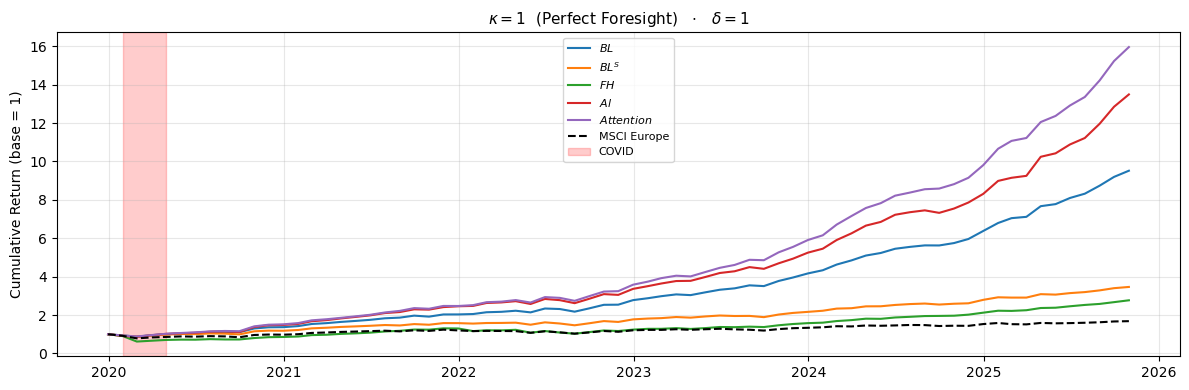

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,38.71,13.22,2.9279,30.06,5.50,5.4660,0.8279,31.55,15.3132,0.0000
$BL^{S}$,20.99,13.60,1.5435,12.34,3.78,3.2644,0.8872,13.32,9.2880,0.0000
$FH$,18.43,19.97,0.9229,9.78,10.30,0.9497,1.1643,8.36,1.9750,0.0523
$Al$,45.26,15.96,2.8363,36.61,6.79,5.3953,0.9733,36.84,12.8570,0.0000
$Attention$,48.06,14.60,3.2918,39.41,6.54,6.0287,0.8867,40.39,15.1156,0.0000
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  2 ... done


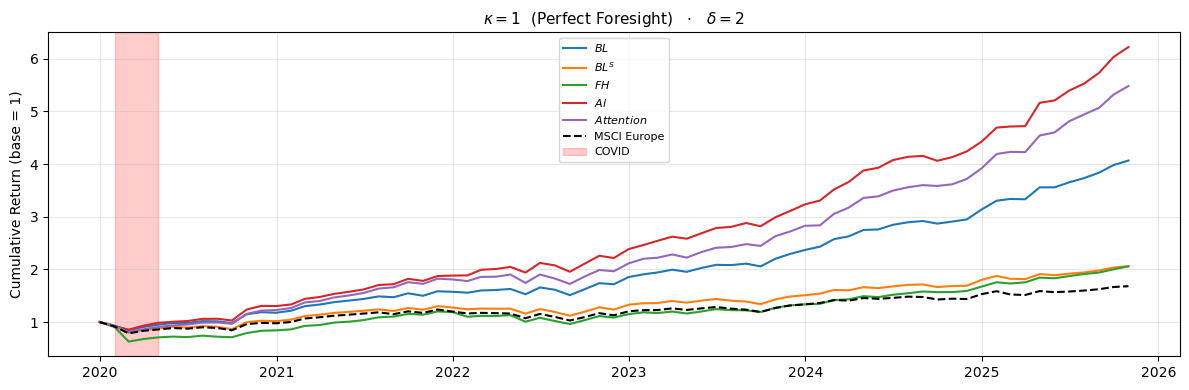

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,23.84,13.89,1.7166,15.19,3.43,4.4258,0.9110,15.96,11.9112,0.0000
$BL^{S}$,12.18,14.90,0.8172,3.53,1.07,3.3093,1.0013,3.52,7.7994,0.0000
$FH$,13.10,19.15,0.6843,4.45,8.70,0.5114,1.1598,3.07,0.8664,0.3893
$Al$,31.38,14.59,2.1508,22.73,5.66,4.0142,0.9102,23.51,10.0977,0.0000
$Attention$,29.32,15.57,1.8833,20.67,5.03,4.1105,0.9926,20.74,9.7495,0.0000
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  4 ... done


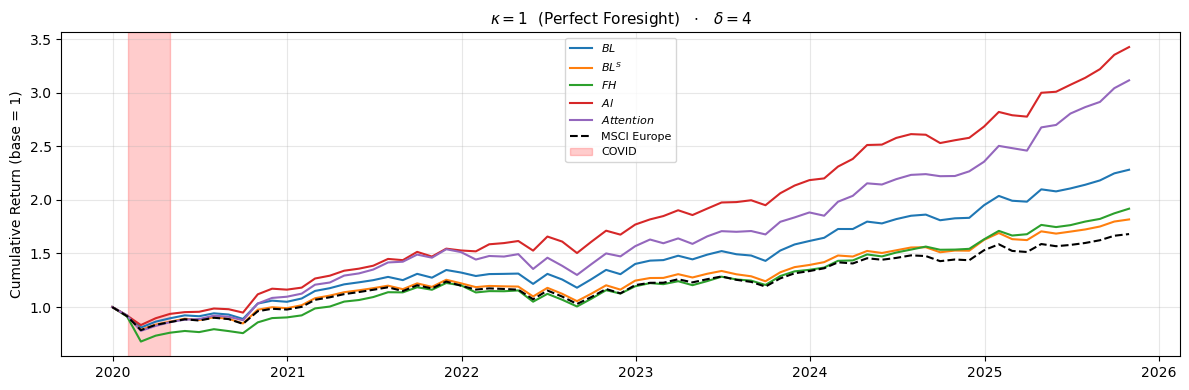

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,13.89,14.63,0.9492,5.24,1.62,3.2372,0.9797,5.41,8.0499,0.0000
$BL^{S}$,10.02,15.01,0.6677,1.37,0.80,1.7221,1.0095,1.29,3.8887,0.0002
$FH$,11.47,17.55,0.6536,2.82,5.95,0.4743,1.1186,1.79,0.7470,0.4577
$Al$,20.88,14.20,1.4707,12.23,4.58,2.6691,0.9098,13.01,7.0186,0.0000
$Attention$,19.56,16.23,1.2049,10.91,5.39,2.0246,1.0320,10.63,4.6830,0.0000
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ =  8 ... done


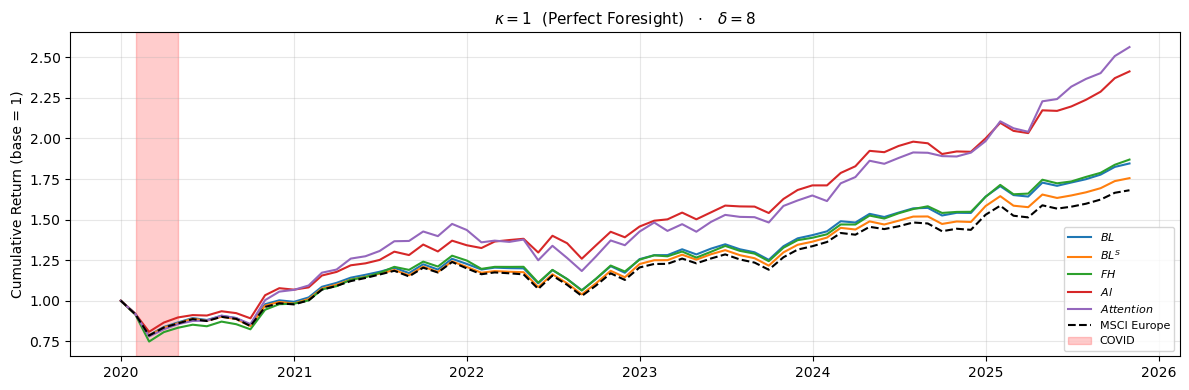

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,10.29,14.98,0.6866,1.64,0.90,1.8184,1.0075,1.57,4.1608,0.0001
$BL^{S}$,9.42,15.01,0.6277,0.77,0.74,1.0464,1.0101,0.69,2.2418,0.0282
$FH$,10.65,15.74,0.6764,2.00,2.67,0.7476,1.0462,1.60,1.4632,0.1480
$Al$,14.81,14.21,1.0424,6.16,3.68,1.6743,0.9271,6.79,4.5652,0.0000
$Attention$,16.20,16.41,0.9874,7.55,5.52,1.3687,1.0417,7.19,3.1006,0.0028
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ = 16 ... done


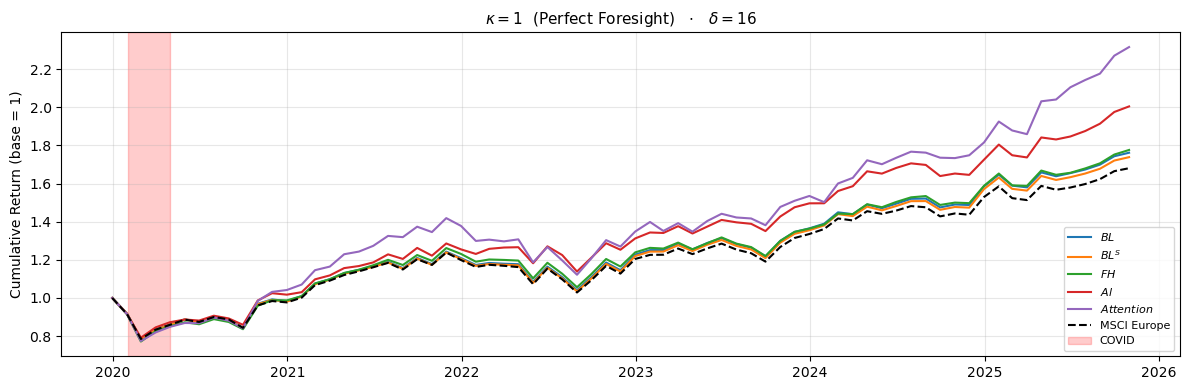

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.49,15.01,0.6321,0.84,0.77,1.0815,1.0097,0.75,2.3405,0.0222
$BL^{S}$,9.26,15.02,0.6166,0.61,0.73,0.8341,1.0103,0.52,1.7207,0.0898
$FH$,9.66,15.16,0.6371,1.01,1.31,0.7683,1.0173,0.86,1.5767,0.1195
$Al$,11.62,14.33,0.8107,2.97,2.93,1.0131,0.9466,3.43,2.8745,0.0054
$Attention$,14.46,16.54,0.8741,5.81,5.26,1.1050,1.0581,5.31,2.4190,0.0182
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


  δ = 32 ... done


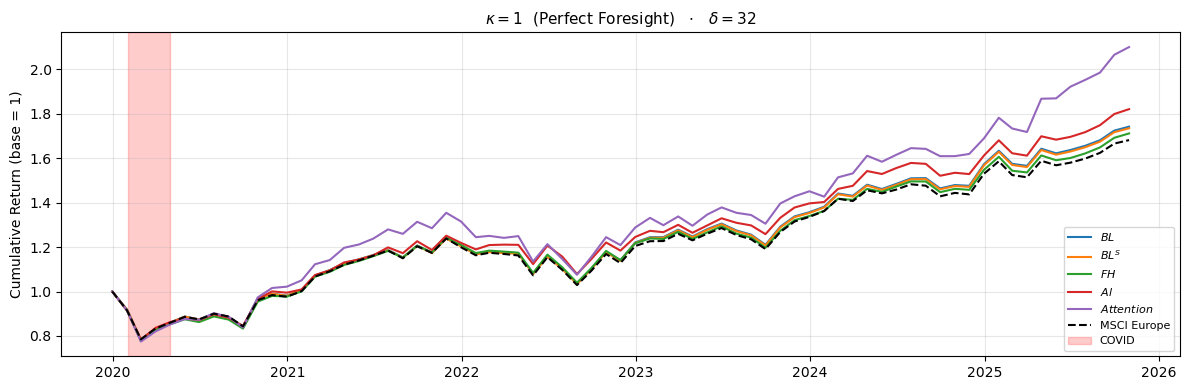

,Return p.a. (%),Volatility p.a. (%),Sharpe Ratio,Rel. Return p.a. (%),Tracking Error p.a. (%),Information Ratio,Beta,Alpha p.a. (%),T-stat Alpha,P-val Alpha
Model,,,,,,,,,,
$BL$,9.28,15.01,0.6184,0.63,0.74,0.8614,1.0101,0.55,1.7933,0.0774
$BL^{S}$,9.21,15.02,0.6135,0.56,0.73,0.7736,1.0104,0.47,1.5718,0.1206
$FH$,8.98,15.00,0.5986,0.33,0.75,0.4409,1.0093,0.25,0.8015,0.4256
$Al$,9.98,14.53,0.6868,1.33,2.12,0.6256,0.9687,1.60,1.8242,0.0725
$Attention$,12.71,16.25,0.7820,4.06,4.28,0.9478,1.0577,3.56,2.0057,0.0489
MSCI Europe,8.65,14.85,0.5827,0.00,0.00,NaN,1.0000,0.00,0.1988,0.8430


In [47]:
# ── Main loop: κ ∈ {-1, 0, 1}  ×  δ ∈ {1, 2, 4, 8, 16, 32} ─────────────────
LABEL = {0.5: "Some Skill", 0: "No Skill", 1: "Perfect Foresight"}

for kappa in KAPPAS:
    print(f"\n{'═' * 65}")
    print(f"  κ = {kappa}  —  {LABEL[kappa]}")
    print(f"{'═' * 65}")

    for delta in DELTAS:
        print(f"  δ = {delta:2d} ...", end=" ", flush=True)

        port_returns     = {name: pd.Series(np.nan, index=idx) for name in METHODS}
        port_returns_raw = {name: pd.Series(np.nan, index=idx) for name in METHODS}

        for wc in window_cache:
            date       = wc["date"]
            r_next     = wc["r_next"]
            r_next_raw = wc["r_next_raw"]
            rf_val     = wc["rf_val"]
            lam        = wc["lam"]

            for name in METHODS:
                md = wc["models"][name]
                if md is None:
                    continue

                pi, Psi, Sig   = md["pi"], md["Psi"], md["Sig"]
                noise_base     = md["noise_base"]
                sig_diag       = md["sig_diag"]

                # Eq. 60: q = π + κ(r_{t+1} − π) + δ·ε̃  (in excess return space)
                Q     = (pi + kappa * (r_next - pi))[None, :] + delta * noise_base
                Omega = np.diag(delta**2 * sig_diag)

                try:
                    M, _ = bl_posterior_batch(pi, Psi, Sig, Q, Omega)
                except Exception:
                    continue

                # MV optimisation: posterior mean m, sample covariance Σ̂
                w_draws = np.zeros((N_DRAWS, N))
                for d in range(N_DRAWS):
                    try:
                        w_draws[d] = mv_optimize(M[d], Sig)
                    except Exception:
                        w_draws[d] = np.ones(N) / N

                w_avg = np.clip(w_draws.mean(axis=0), 0, None)
                if w_avg.sum() > 0:
                    w_avg /= w_avg.sum()
                    raw_port_ret = float(w_avg @ r_next_raw)
                    port_returns[name].loc[date]     = raw_port_ret - rf_val
                    port_returns_raw[name].loc[date] = raw_port_ret

        print("done")

        # ── Cumulative return plot (raw returns, all series base = 1) ─────────
        fig, ax = plt.subplots(figsize=(12, 4))

        cum_dict = {}
        for name in METHODS:
            s = port_returns_raw[name].dropna()
            if len(s) > 0:
                cum_dict[name] = (1 + s).cumprod()

        cum_mkt = (1 + market_ret_raw.dropna()).cumprod()

        all_starts = [c.index[0] for c in cum_dict.values()] + [cum_mkt.index[0]]
        t0        = max(all_starts)
        base_date = t0 - pd.DateOffset(months=1)

        for name, cum in cum_dict.items():
            c = cum[cum.index >= t0]
            c = pd.concat([pd.Series([1.0], index=[base_date]), c])
            ax.plot(c.index, c.values, label=PLOT_METHODS.get(name, name))

        c_mkt = cum_mkt[cum_mkt.index >= t0]
        c_mkt = pd.concat([pd.Series([1.0], index=[base_date]), c_mkt])
        ax.plot(c_mkt.index, c_mkt.values, label="MSCI Europe",
                color="black", linestyle="--", linewidth=1.5)

        ax.axvspan(covid_start, covid_end, color="red", alpha=0.2, label="COVID")
        ax.set_title(f"$\\kappa = {kappa}$  ({LABEL[kappa]})   $\\cdot$   $\\delta = {delta}$",
                     fontsize=11)
        ax.set_ylabel("Cumulative Return (base = 1)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ── Metrics table (excess returns: raw - RF) ──────────────────────────
        all_exc = {**port_returns, "MSCI Europe": market_ret}
        mdf = pd.DataFrame(
            {PLOT_METHODS.get(nm, nm): compute_metrics(r, market_ret)
             for nm, r in all_exc.items()}
        ).T
        mdf.index.name = "Model"
        ipy_display(mdf.round(4))
